# PyTheraTwin Pipeline - Output Analysis

This notebook discovers all output folders matching `OUTPUT_TITLE/CT_*`, reports what is present or missing, and visualizes each major pipeline stage.

Use the setup cell below as the control panel: change the output title, plot behavior, color maps, SPECT frame selection, and comparison filters there before rerunning the notebook.


## 1 - Imports, Plot Helpers, and Unit Helpers

Expected output: a short `Imports OK` message. This cell defines reusable helpers only; it does not load patient data.


In [31]:
import os
import re
import json
import math
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
from scipy.optimize import curve_fit, OptimizeWarning

plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.labelweight': 'bold',
    'figure.titlesize': 16,
    'figure.titleweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 100,
})


def _strip_comments(text):
    # Some repo JSON files allow // comments. Strip them before json.loads.
    lines = []
    for line in text.splitlines():
        idx = line.find('//')
        lines.append(line[:idx] if idx >= 0 else line)
    return '\n'.join(lines)


def load_json(path):
    with open(path, encoding='utf-8') as f:
        return json.loads(_strip_comments(f.read()))


def list_files(directory, suffix):
    if not os.path.isdir(directory):
        return []
    return sorted(os.path.join(directory, f) for f in os.listdir(directory) if f.endswith(suffix))


def stem(path):
    name = os.path.basename(path)
    return name[:-7] if name.endswith('.nii.gz') else os.path.splitext(name)[0]


def fmt_int(value):
    try:
        return f'{int(value):,}'
    except Exception:
        return str(value)


def pct(numer, denom, eps=1e-9):
    return (numer - denom) / (abs(denom) + eps) * 100.0


def safe_name(text):
    name = re.sub(r'[^A-Za-z0-9_.-]+', '_', str(text)).strip('_')
    return name or 'plot'


def finish_plot(fig, name, tight=True):
    # Shared show/save behavior. Configure SHOW_PLOTS and SAVE_PLOTS in the next cell.
    if tight:
        fig.tight_layout()
    saved_paths = []
    if globals().get('SAVE_PLOTS', False):
        out_dir = Path(globals().get('PLOT_OUTPUT_DIR', 'notebook_plots'))
        out_dir.mkdir(parents=True, exist_ok=True)
        for ext in globals().get('PLOT_FORMATS', ('png',)):
            out_path = out_dir / f'{safe_name(name)}.{ext}'
            fig.savefig(out_path, dpi=globals().get('PLOT_DPI', 200), bbox_inches='tight')
            saved_paths.append(out_path)
        if globals().get('PRINT_SAVED_PLOTS', True):
            print('Saved:', ', '.join(str(p) for p in saved_paths))
    if globals().get('SHOW_PLOTS', True):
        plt.show()
    else:
        plt.close(fig)
    return saved_paths


def plot_spec(section, key, default=None):
    return globals().get('PLOT_SPECS', {}).get(section, {}).get(key, default)


def arr_aspect(sp, view):
    if view == 'axial':
        return sp[1] / sp[0]
    if view == 'coronal':
        return sp[2] / sp[0]
    if view == 'sagittal':
        return sp[2] / sp[1]
    return 'auto'


def image_aspect(sp=None, view=None):
    # Square panels are easier to compare in a notebook. Set PRESERVE_PHYSICAL_ASPECT=True
    # in the setup cell if you prefer anatomically scaled panels.
    if not globals().get('PRESERVE_PHYSICAL_ASPECT', False):
        return 'auto'
    return arr_aspect(sp, view) if sp is not None and view else 'auto'


def plot_image(ax, image, *, sp=None, view=None, cmap='gray', title='', vmin=None, vmax=None,
               interpolation='nearest', alpha=None):
    im = ax.imshow(
        image,
        cmap=cmap,
        aspect=image_aspect(sp, view),
        vmin=vmin,
        vmax=vmax,
        interpolation=interpolation,
        alpha=alpha,
    )
    if globals().get('FORCE_SQUARE_PANELS', True):
        ax.set_box_aspect(1)
    ax.set_title(title)
    ax.axis('off')
    return im


def add_colorbar(fig, ax, im, label=''):
    if globals().get('SHOW_COLORBARS', True):
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=label)


def make_grid(n_items, max_cols=4, panel_w=5.0, panel_h=4.5):
    if n_items <= 0:
        return None, None, 0, 0
    ncols = min(max_cols, n_items)
    nrows = int(math.ceil(n_items / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(panel_w * ncols, panel_h * nrows), squeeze=False)
    return fig, axes, nrows, ncols


def select_frame_labels(labels, mode='all', selected=None):
    labels_sorted = sorted([str(x) for x in labels], key=lambda k: float(k))
    selected = [] if selected is None else [str(x) for x in selected]
    if not labels_sorted:
        return []
    if mode == 'first':
        return labels_sorted[:1]
    if mode == 'last':
        return labels_sorted[-1:]
    if mode == 'selected':
        wanted = {str(float(x)).rstrip('0').rstrip('.') for x in selected}
        return [lbl for lbl in labels_sorted if str(float(lbl)).rstrip('0').rstrip('.') in wanted]
    return labels_sorted


def normalize_unit(unit):
    unit = str(unit).lower().strip()
    if unit not in {'mm', 'cm'}:
        raise ValueError(f"Unknown spacing unit '{unit}'. Use 'mm' or 'cm'.")
    return unit


def unit_scale_factor(from_unit, to_unit):
    from_unit, to_unit = normalize_unit(from_unit), normalize_unit(to_unit)
    if from_unit == to_unit:
        return 1.0
    if from_unit == 'mm' and to_unit == 'cm':
        return 0.1
    if from_unit == 'cm' and to_unit == 'mm':
        return 10.0
    raise ValueError(f'Cannot convert {from_unit} to {to_unit}')


def scale_img_units(img, from_unit, to_unit):
    factor = unit_scale_factor(from_unit, to_unit)
    if factor == 1.0:
        return sitk.Image(img)
    out = sitk.Image(img)
    out.SetSpacing((np.array(out.GetSpacing()) * factor).tolist())
    out.SetOrigin((np.array(out.GetOrigin()) * factor).tolist())
    return out


def voxel_volume_ml(spacing, spacing_unit):
    spacing_unit = normalize_unit(spacing_unit)
    vol = float(np.prod(np.asarray(spacing, dtype=float)))
    return vol if spacing_unit == 'cm' else vol / 1000.0


def comparison_xlim(frame_hr):
    if globals().get('COMPARISON_XLIM_HR', 'frame_range') == 'full':
        return None
    manual = globals().get('COMPARISON_XLIM_HR', 'frame_range')
    if isinstance(manual, (tuple, list)) and len(manual) == 2:
        return tuple(float(v) for v in manual)
    frame_hr = np.asarray(frame_hr, dtype=float)
    frame_hr = frame_hr[np.isfinite(frame_hr)]
    if frame_hr.size == 0:
        return None
    return (0.0, max(1.0, float(frame_hr.max()) * 1.10))

print('Imports OK')


Imports OK


## 2 - Setup and Plot Specs

Expected output: no plots. Edit this cell first when you want to change the output folder title, save figures, select only the last SPECT frame, change color maps, or alter comparison behavior.


In [32]:
# -----------------------------------------------------------------------------
# Input/output — edit these directly
# -----------------------------------------------------------------------------
CT_DIR       = str(Path('/home/jhubadmin/Theranostic-Virtual-Patient-Pipeline/inputs/testing_dataset').expanduser())
OUTPUT_ROOT  = str(Path('/home/jhubadmin/Theranostic-Virtual-Patient-Pipeline').expanduser())
OUTPUT_TITLE = 'dataset'

# -----------------------------------------------------------------------------
# Plot behavior
# -----------------------------------------------------------------------------
SHOW_PLOTS = True
SAVE_PLOTS = False
PLOT_OUTPUT_DIR = str(Path(OUTPUT_ROOT) / 'figures' / 'output_analysis' / OUTPUT_TITLE)
PLOT_FORMATS = ('png',)
PLOT_DPI = 200
PRINT_SAVED_PLOTS = True

# Square panels look cleaner in notebooks. If you need physical aspect ratios,
# set PRESERVE_PHYSICAL_ASPECT=True.
FORCE_SQUARE_PANELS = True
PRESERVE_PHYSICAL_ASPECT = False
SHOW_COLORBARS = True

# -----------------------------------------------------------------------------
# Section-specific plot specs
# -----------------------------------------------------------------------------
PLOT_SPECS = {
    'ct':           {'cmap': 'gray'},
    'segmentation': {'cmap': 'tab20'},
    'lesions':      {'cmap': 'hot'},
    'pbpk':         {'line_cmap': 'tab20'},
    'simind':       {'atn_cmap': 'gray', 'activity_cmap': 'inferno', 'projection_cmap': 'turbo'},
    'opengate':     {'cmap': 'plasma'},
    'spect':        {'cmap': 'hot', 'percentile': 99.5},
    'activity':     {'cmap': 'hot'},
    'dose':         {'cmap': 'plasma', 'percentile': 99.0},
    'mask':         {'image_cmap': 'gray', 'contour_color': 'cyan'},
    'comparison':   {'pbpk_color': 'steelblue', 'spect_color': 'orangered'},
    'profile':      {'cmap': 'tab10'},
}

# -----------------------------------------------------------------------------
# PBPK and SPECT controls
# -----------------------------------------------------------------------------
PBPK_XLIM_HR = None          # Example: (0, 72). None shows the full 66.47 day TAC.
PBPK_Y_SCALE = 'linear'      # 'linear' or 'log'.

SPECT_FRAME_MODE = 'all'     # 'all', 'first', 'last', or 'selected'.
SPECT_SELECTED_FRAMES = []   # Example: [48] when SPECT_FRAME_MODE='selected'.
SPECT_SHARED_SCALE = True

# Raw SIMIND summed projection stack display. Window w2 is the photopeak window.
SIMIND_PROJECTION_INDEX = 0
SIMIND_PROJECTION_WINDOWS = ('w2',)
SIMIND_PROJECTION_PERCENTILE = 99.5

# Current pipeline outputs use mm spacing in reconstructed SPECT NIfTIs.
# For legacy runs produced before the spacing fix, temporarily set this to 'cm'.
SPECT_RECON_SPACING_UNIT = 'mm'
SEGMENTATION_SPACING_UNIT = 'mm'

# -----------------------------------------------------------------------------
# Comparison controls
# -----------------------------------------------------------------------------
COMPARE_ONLY_SIMULATED_ROIS = True
INCLUDE_REMAINING_BODY_IN_COMPARISON = False
SKIP_ROIS_COMPARISON = {'remaining_body', 'background'}
SKIP_LAST_FRAME = False      # Set True only if you intentionally want to drop the final SPECT frame.
COMPARISON_XLIM_HR = 'frame_range'  # 'frame_range', 'full', or a tuple like (0, 72).
FIT_MAX_PBPK_POINTS = 2000

# -----------------------------------------------------------------------------
# Profiling controls
# -----------------------------------------------------------------------------
PROFILE_PHASE = ''           # Empty means all stages; e.g. 'simind' filters comparison plots.
PARAM_LABEL = 'Patient'
STAGE_ORDER = ['segmentation', 'synthetic_lesions', 'pbpk_tac', 'simind', 'opengate', 'spect_postprocess', 'dosemap_postprocess']

print('Setup loaded')
print(f'  CT_DIR={CT_DIR}')
print(f'  OUTPUT_ROOT={OUTPUT_ROOT}')
print(f'  OUTPUT_TITLE={OUTPUT_TITLE}')


Setup loaded
  CT_DIR=/home/jhubadmin/Theranostic-Virtual-Patient-Pipeline/inputs/testing_dataset
  OUTPUT_ROOT=/home/jhubadmin/Theranostic-Virtual-Patient-Pipeline
  OUTPUT_TITLE=dataset


## 3 - Discover Output Folders and Stage Inventory

Expected output: a folder list and a compact stage inventory per CT. If no matching folders exist, this section reports that instead of raising an exception.


In [33]:
PROJECT_DIR = os.path.join(OUTPUT_ROOT, OUTPUT_TITLE)


def ct_index_from_name(name):
    try:
        return int(name.replace('CT_', '', 1))
    except Exception:
        return 10**9


def discover_ct_inputs(ct_dir):
    ct_inputs = []
    if os.path.isdir(ct_dir):
        for entry in sorted(os.listdir(ct_dir)):
            p = os.path.join(ct_dir, entry)
            if os.path.isdir(p) or entry.endswith(('.nii', '.nii.gz')):
                ct_inputs.append(p)
    return ct_inputs


def recorded_ct_for_folder(folder):
    # Prefer pipeline provenance metadata so CT labels do not depend on sorted input order.
    meta_path = os.path.join(folder, 'pipeline_metadata', 'ct_input.json')
    if not os.path.exists(meta_path):
        return None
    try:
        meta = load_json(meta_path)
        identity = meta.get('ct_identity', {})
        return identity.get('current_input_path') or identity.get('saved_copy_path')
    except Exception as exc:
        return f'(ct provenance unreadable: {exc})'


folder_names = sorted(
    [d for d in (os.listdir(PROJECT_DIR) if os.path.isdir(PROJECT_DIR) else [])
     if os.path.isdir(os.path.join(PROJECT_DIR, d)) and d.startswith('CT_')],
    key=lambda name: (ct_index_from_name(name), name),
)
OUT_FOLDERS = [os.path.join(PROJECT_DIR, d) for d in folder_names]
N = len(OUT_FOLDERS)
ct_inputs = discover_ct_inputs(CT_DIR)

if N == 0:
    print(f"No CT_* output folders found in {PROJECT_DIR}")
else:
    print(f'Found {N} output folder(s):')
    for i, f in enumerate(OUT_FOLDERS):
        recorded_ct = recorded_ct_for_folder(f)
        fallback_ct = ct_inputs[i] if i < len(ct_inputs) else None
        ct_str = recorded_ct or fallback_ct or '(unknown)'
        source = 'metadata' if recorded_ct else 'input-order fallback'
        print(f'  CT {i+1}: {os.path.basename(f)} <- {os.path.basename(str(ct_str))} [{source}]')


Found 1 output folder(s):
  CT 1: CT_1 <- CT_1.nii.gz [metadata]


In [34]:
# This cell answers: "What exists in each output folder, and what is missing?"
# It is intentionally lightweight and does not load large images.

EXPECTED_OUTPUTS = [
    ('Input CT copy',        ['digital_twin/ct.nii.gz']),
    ('Segmentation',        ['digital_twin/digital_twin.nii.gz', 'pipeline_metadata/segmentation_stage.json']),
    ('Synthetic lesions',   ['digital_twin/synthetic_lesions_stage/synthetic_lesions_all_lesions_labels.nii.gz', 'pipeline_metadata/synthetic_lesions_stage.json']),
    ('PBPK TAC',            ['digital_twin/pbpk_tac_stage/pbpk_tacs.npz', 'digital_twin/pbpk_tac_stage/pbpk_tacs.json', 'pipeline_metadata/pbpk_tac_stage.json']),
    ('SIMIND',              ['pipeline_metadata/simind_simulation_stage.json', 'simulations/simind_tot_w1.a00']),
    ('OpenGATE',            ['pipeline_metadata/opengate_simulation_stage.json']),
    ('SPECT postprocess',   ['pipeline_metadata/spect_postprocess_stage.json', 'post_processing/reconstructed_SPECT_*.nii.gz']),
    ('Dose postprocess',    ['pipeline_metadata/dosemap_postprocess_stage.json', 'post_processing/dosemap_postprocess_total_dose.nii.gz']),
    ('Profiling',           ['profiling_CT_*.json']),
]


def pattern_exists(folder, pattern):
    return bool(list(Path(folder).glob(pattern)))


def inventory_for_folder(folder):
    rows = []
    for stage, patterns in EXPECTED_OUTPUTS:
        hits = [pat for pat in patterns if pattern_exists(folder, pat)]
        missing = [pat for pat in patterns if pat not in hits]
        rows.append({'stage': stage, 'present': bool(hits), 'hits': hits, 'missing': missing})
    return rows

inventory_store = {}
for i, folder in enumerate(OUT_FOLDERS):
    rows = inventory_for_folder(folder)
    inventory_store[i] = rows
    print(f"\nCT {i+1}: {os.path.basename(folder)}")
    for row in rows:
        status = 'OK' if row['present'] else 'missing'
        detail = ', '.join(row['hits']) if row['hits'] else ', '.join(row['missing'])
        print(f"  {status:7s} {row['stage']:20s} {detail}")

if not OUT_FOLDERS:
    print('No inventory to report.')



CT 1: CT_1
  OK      Input CT copy        digital_twin/ct.nii.gz
  OK      Segmentation         digital_twin/digital_twin.nii.gz, pipeline_metadata/segmentation_stage.json
  OK      Synthetic lesions    digital_twin/synthetic_lesions_stage/synthetic_lesions_all_lesions_labels.nii.gz, pipeline_metadata/synthetic_lesions_stage.json
  OK      PBPK TAC             digital_twin/pbpk_tac_stage/pbpk_tacs.npz, digital_twin/pbpk_tac_stage/pbpk_tacs.json, pipeline_metadata/pbpk_tac_stage.json
  OK      SIMIND               pipeline_metadata/simind_simulation_stage.json, simulations/simind_tot_w1.a00
  OK      OpenGATE             pipeline_metadata/opengate_simulation_stage.json
  OK      SPECT postprocess    pipeline_metadata/spect_postprocess_stage.json, post_processing/reconstructed_SPECT_*.nii.gz
  OK      Dose postprocess     pipeline_metadata/dosemap_postprocess_stage.json, post_processing/dosemap_postprocess_total_dose.nii.gz
  OK      Profiling            profiling_CT_*.json


## 4 - Configuration Summary

Expected output: one text block per CT describing the configured stages, requested ROIs, frame times, and major simulation parameters.


In [35]:
configs = {}

for i, folder in enumerate(OUT_FOLDERS):
    cfg_path = os.path.join(folder, 'config.json')
    if os.path.exists(cfg_path):
        configs[i] = load_json(cfg_path)

    print(f"{'='*72}")
    print(f'  CT {i+1}: {os.path.basename(folder)}')
    print(f"{'='*72}")

    if i not in configs:
        print('  config.json not found')
        continue

    cfg   = configs[i]
    p1    = cfg.get('phase_1', {})
    p2    = cfg.get('phase_2', {})
    p3    = cfg.get('phase_3', {})
    seg   = p1.get('segmentation_stage', {})
    les   = p1.get('synthetic_lesions_stage', {})
    pbpk  = p1.get('pbpk_tac_stage', {})
    sim   = p2.get('simind_stage', {})
    og    = p2.get('opengate_stage', {})
    spect = p3.get('spect_postprocess_stage', {})
    dose  = p3.get('dosemap_postprocess_stage', {})

    print('\n  Phase 1: Digital twin')
    print(f"    ROIs segmented     : {seg.get('roi_subset', [])}")
    specs = les.get('specs', {})
    if specs:
        for organ, s in specs.items():
            print(f"    Synthetic lesions  : {organ} - {s.get('n_lesions', 0)} lesion(s), "
                  f"radii={s.get('radii_mm')} mm, prob={s.get('prob', '-')}")
    else:
        print('    Synthetic lesions  : none')
    print(f"    PBPK model         : {pbpk.get('model_type', '-')}  isotope={pbpk.get('isotope', '-')}")

    print('\n  Phase 2: Simulations')
    print('    SIMIND')
    print(f"      isotope          : {sim.get('isotope', '-')}")
    print(f"      collimator       : {sim.get('Collimator', '-')}")
    print(f"      ROI subset       : {sim.get('roi_subset', 'all ROIs')}")
    print(f"      photons          : {fmt_int(sim.get('NumPhotons', '-'))}")
    print(f"      projections      : {sim.get('NumProjections', '-')}  output px = {sim.get('OutputPixelWidth', '-')} cm")
    print('    OpenGATE')
    print(f"      ROI subset       : {og.get('roi_subset', 'all ROIs')}")
    print(f"      total histories  : {fmt_int(og.get('gate', {}).get('total_histories', '-'))}")
    print(f"      variance reduc.  : {og.get('variance_reduction', False)}")

    print('\n  Phase 3: Post-processing')
    ft = sorted(spect.get('FrameStartTimes', []))
    fd = spect.get('FrameDurations', [])
    ft_hr = [f'{t/60:.2f}h' for t in ft]
    print(f"    SPECT frames       : {len(ft)} - start times = {ft_hr}  durations = {fd} min")
    print(f"    Reconstruction     : {spect.get('ReconstructionAlgorithm', '-')}  "
          f"iter={spect.get('Iterations', '-')}  subsets={spect.get('Subsets', '-')}")
    print(f"    Poisson noise      : {spect.get('apply_poisson_noise', False)}")
    print(f"    TAC weighting      : SPECT={spect.get('apply_tac', False)}  Dose={dose.get('apply_tac', False)}")
print()


  CT 1: CT_1

  Phase 1: Digital twin
    ROIs segmented     : ['liver', 'prostate', 'spleen', 'heart', 'lungs', 'brain', 'adrenal_glands', 'thyroid_gland', 'gallbladder', 'gi_tract', 'pancreas', 'esophagus', 'trachea', 'urinary_bladder', 'kidney_cyst', 'bone', 'spinal_cord', 'aorta', 'pulmonary_vein', 'brachiocephalic_vessels', 'carotid_arteries', 'portal_vein', 'iliac_arteries', 'iliac_veins', 'atrial_appendage', 'superior_vena_cava', 'inferior_vena_cava', 'muscle', 'salivary_glands', 'eyes', 'eye_lenses', 'optic_nerves', 'nasopharynx', 'oropharynx', 'hypopharynx', 'nasal_cavity', 'auditory_canal', 'soft_palate', 'hard_palate', 'kidney']
    Synthetic lesions  : liver - 3 lesion(s), radii=[2, 3, 1] mm, prob=uniform
    PBPK model         : PSMA  isotope=lu177

  Phase 2: Simulations
    SIMIND
      isotope          : lu177
      collimator       : si-me
      ROI subset       : ['liver', 'salivary_glands', 'lungs', 'kidney']
      photons          : 1,000,000,000
      projections  

## 5 - Phase 1: Digital Twin Outputs

The next cells load image outputs from the digital twin stage. Expected plots: CT views, segmentation projections, lesion projections if lesions exist, and PBPK TACs.


### 5a - Input CT

Expected output: shape/spacing text and three square CT panels per patient.


CT 1  shape=(z=326, y=400, x=400)  spacing=(2.04, 2.04, 3.00) mm


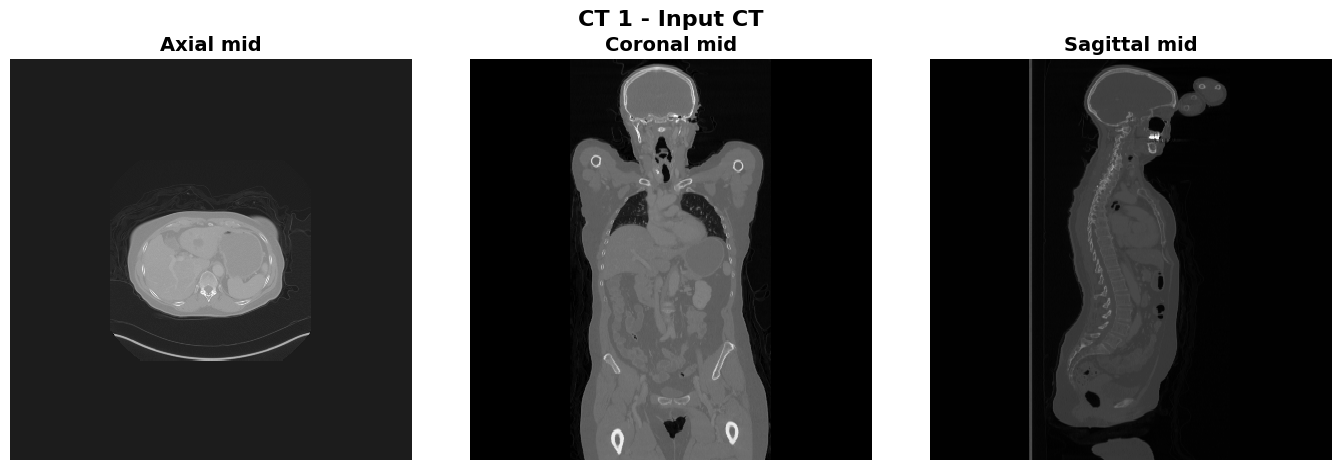

In [36]:
for i, folder in enumerate(OUT_FOLDERS):
    ct_path = os.path.join(folder, 'digital_twin', 'ct.nii.gz')
    if not os.path.exists(ct_path):
        print(f'CT {i+1}: ct.nii.gz not found')
        continue

    img = sitk.ReadImage(ct_path)
    arr = sitk.GetArrayFromImage(img)[::-1]   # z,y,x display order, head-up
    sp  = img.GetSpacing()                    # x,y,z in mm
    z, y, x = arr.shape
    print(f'CT {i+1}  shape=(z={z}, y={y}, x={x})  spacing=({sp[0]:.2f}, {sp[1]:.2f}, {sp[2]:.2f}) mm')

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
    fig.suptitle(f'CT {i+1} - Input CT')
    cmap = plot_spec('ct', 'cmap', 'gray')

    views = [
        ('Axial mid',    arr[z//2, :, :][::-1], 'axial'),
        ('Coronal mid',  arr[:, y//2, :], 'coronal'),
        ('Sagittal mid', arr[:, :, x//2], 'sagittal'),
    ]
    for ax, (title, sl, view) in zip(axes, views):
        plot_image(ax, sl, sp=sp, view=view, cmap=cmap, title=title, interpolation='nearest')
    finish_plot(fig, f'ct_{i+1}_input_ct')


### 5b - PyTheraTwin Segmentation

Expected output: label dictionary and three max-projection segmentation views. This is a quick spatial sanity check, not a quantitative metric.


CT 1  seg shape=(326, 400, 400)  labels={1: 'remaining_body', 2: 'kidney', 3: 'liver', 5: 'spleen', 6: 'heart', 7: 'salivary_glands', 8: 'synthetic_lesion', 9: 'lungs', 10: 'adrenal_glands', 11: 'thyroid_gland', 12: 'gallbladder', 14: 'pancreas', 15: 'esophagus', 16: 'trachea', 20: 'urinary_bladder', 21: 'brain', 24: 'spinal_cord', 27: 'aorta', 28: 'pulmonary_vein', 29: 'brachiocephalic_vessels', 30: 'carotid_arteries', 31: 'portal_vein', 32: 'iliac_arteries', 33: 'iliac_veins', 34: 'atrial_appendage', 35: 'superior_vena_cava', 36: 'inferior_vena_cava', 47: 'eyes', 48: 'eye_lenses', 49: 'optic_nerves', 50: 'nasopharynx', 51: 'oropharynx', 52: 'hypopharynx', 53: 'nasal_cavity', 54: 'auditory_canal', 55: 'soft_palate', 56: 'hard_palate', 57: 'gi_tract', 58: 'bone', 59: 'muscle'}


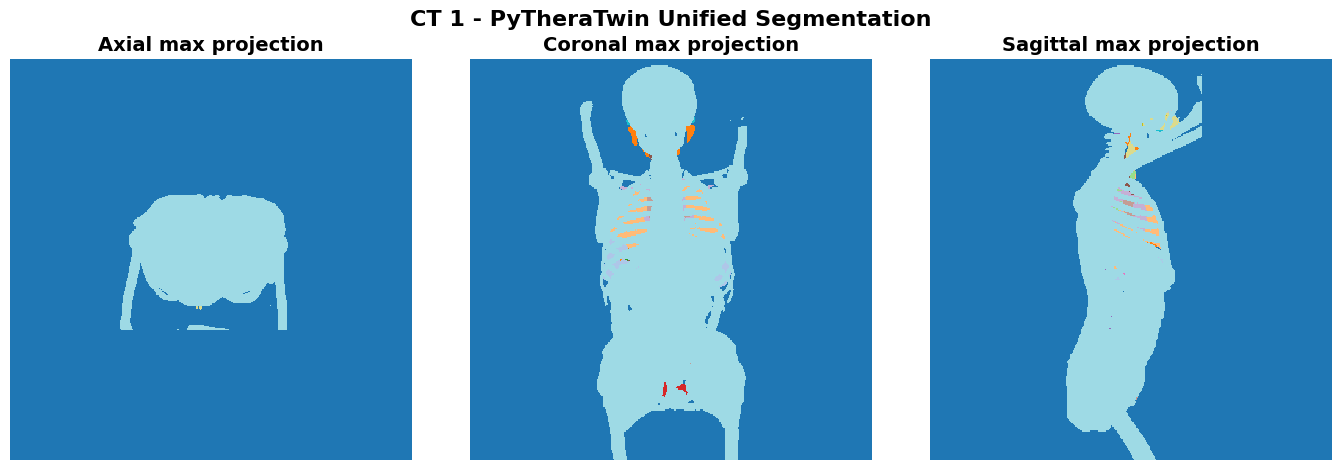

In [37]:
roi_map_path = str(Path(OUTPUT_ROOT) / 'src' / 'data' / 'pipeline_roi_naming_map.json')
label_to_roi = {}
if os.path.exists(roi_map_path):
    roi_map = load_json(roi_map_path)
    pytheratwin_pipe = roi_map.get('PyTheraTwin_Pipeline', {})
    label_to_roi = {int(k): v.lower() for k, v in pytheratwin_pipe.items()}
else:
    print(f'Pipeline ROI naming map not found: {roi_map_path}')

for i, folder in enumerate(OUT_FOLDERS):
    seg_path = os.path.join(folder, 'digital_twin', 'digital_twin.nii.gz')
    if not os.path.exists(seg_path):
        print(f'CT {i+1}: digital_twin.nii.gz not found')
        continue

    seg_img = sitk.ReadImage(seg_path)
    seg     = sitk.GetArrayFromImage(seg_img)[::-1]
    sp      = seg_img.GetSpacing()
    labels  = [int(v) for v in np.unique(seg) if v != 0]
    roi_names = [label_to_roi.get(l, str(l)) for l in labels]
    print(f'CT {i+1}  seg shape={seg.shape}  labels={dict(zip(labels, roi_names))}')

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
    fig.suptitle(f'CT {i+1} - PyTheraTwin Unified Segmentation')
    cmap = plot_spec('segmentation', 'cmap', 'tab20')

    views = [
        ('Axial max projection',    np.max(seg, axis=0), 'axial'),
        ('Coronal max projection',  np.max(seg, axis=1), 'coronal'),
        ('Sagittal max projection', np.max(seg, axis=2), 'sagittal'),
    ]
    for ax, (title, proj, view) in zip(axes, views):
        plot_image(ax, proj, sp=sp, view=view, cmap=cmap, title=title, vmin=0, vmax=max(20, int(seg.max())), interpolation='nearest')
    finish_plot(fig, f'ct_{i+1}_segmentation')


### 5c - Synthetic Lesions

Expected output: lesion count and lesion-label projections for patients where synthetic lesions were generated; otherwise a clear "no synthetic lesions" message.


CT 1  3 lesion(s)  shape=(326, 400, 400)


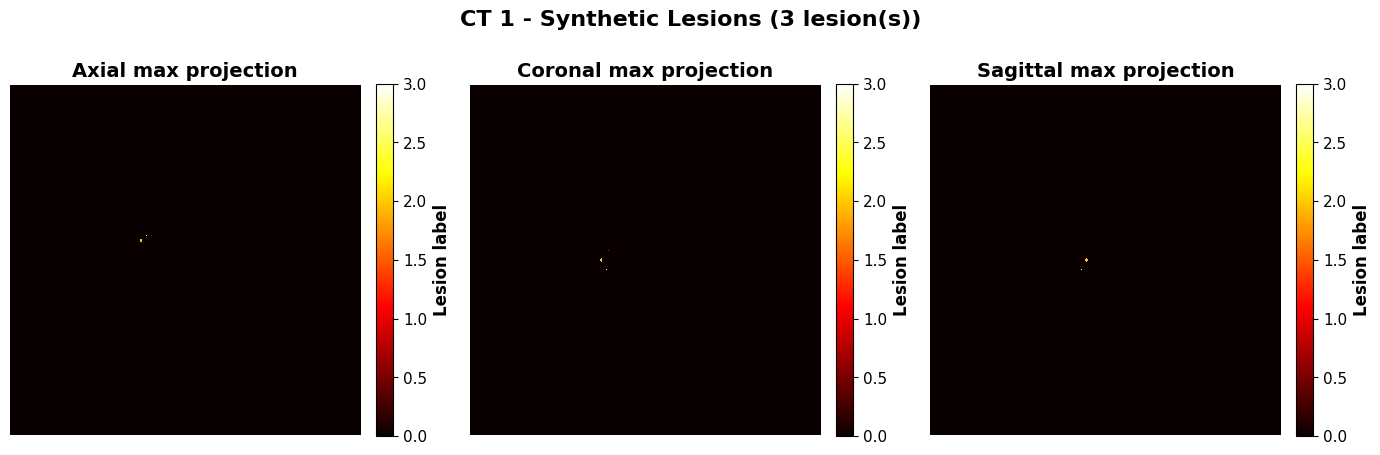

In [38]:
for i, folder in enumerate(OUT_FOLDERS):
    lesion_path = os.path.join(folder, 'digital_twin', 'synthetic_lesions_stage', 'synthetic_lesions_all_lesions_labels.nii.gz')
    if not os.path.exists(lesion_path):
        print(f'CT {i+1}: no synthetic lesions')
        continue

    img = sitk.ReadImage(lesion_path)
    arr = sitk.GetArrayFromImage(img)[::-1]
    sp = img.GetSpacing()
    n_lesions = int(np.max(arr))
    print(f'CT {i+1}  {n_lesions} lesion(s)  shape={arr.shape}')

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
    fig.suptitle(f'CT {i+1} - Synthetic Lesions ({n_lesions} lesion(s))')
    cmap = plot_spec('lesions', 'cmap', 'hot')

    views = [
        ('Axial max projection',    np.max(arr, axis=0), 'axial'),
        ('Coronal max projection',  np.max(arr, axis=1), 'coronal'),
        ('Sagittal max projection', np.max(arr, axis=2), 'sagittal'),
    ]
    for ax, (title, proj, view) in zip(axes, views):
        im = plot_image(ax, proj, sp=sp, view=view, cmap=cmap, title=title, interpolation='nearest')
        add_colorbar(fig, ax, im, label='Lesion label')
    finish_plot(fig, f'ct_{i+1}_synthetic_lesions')


### 5d - PBPK TACs

Expected output: PBPK metadata summary and one TAC subplot per saved ROI. The NPZ time array is in minutes and is converted to hours with `/ 60.0`.


CT 1: 42 TACs | points=95,717 | dt=1 min | range=0.00-1595.28 hr (66.47 days)
  model=PSMA isotope=lu177 half_life=159.53 hr
  SPECT frame times: ['1.00h', '2.00h', '3.00h', '8.00h', '12.00h', '24.00h', '48.00h', '72.00h', '96.00h', '120.00h', '144.00h', '168.00h']


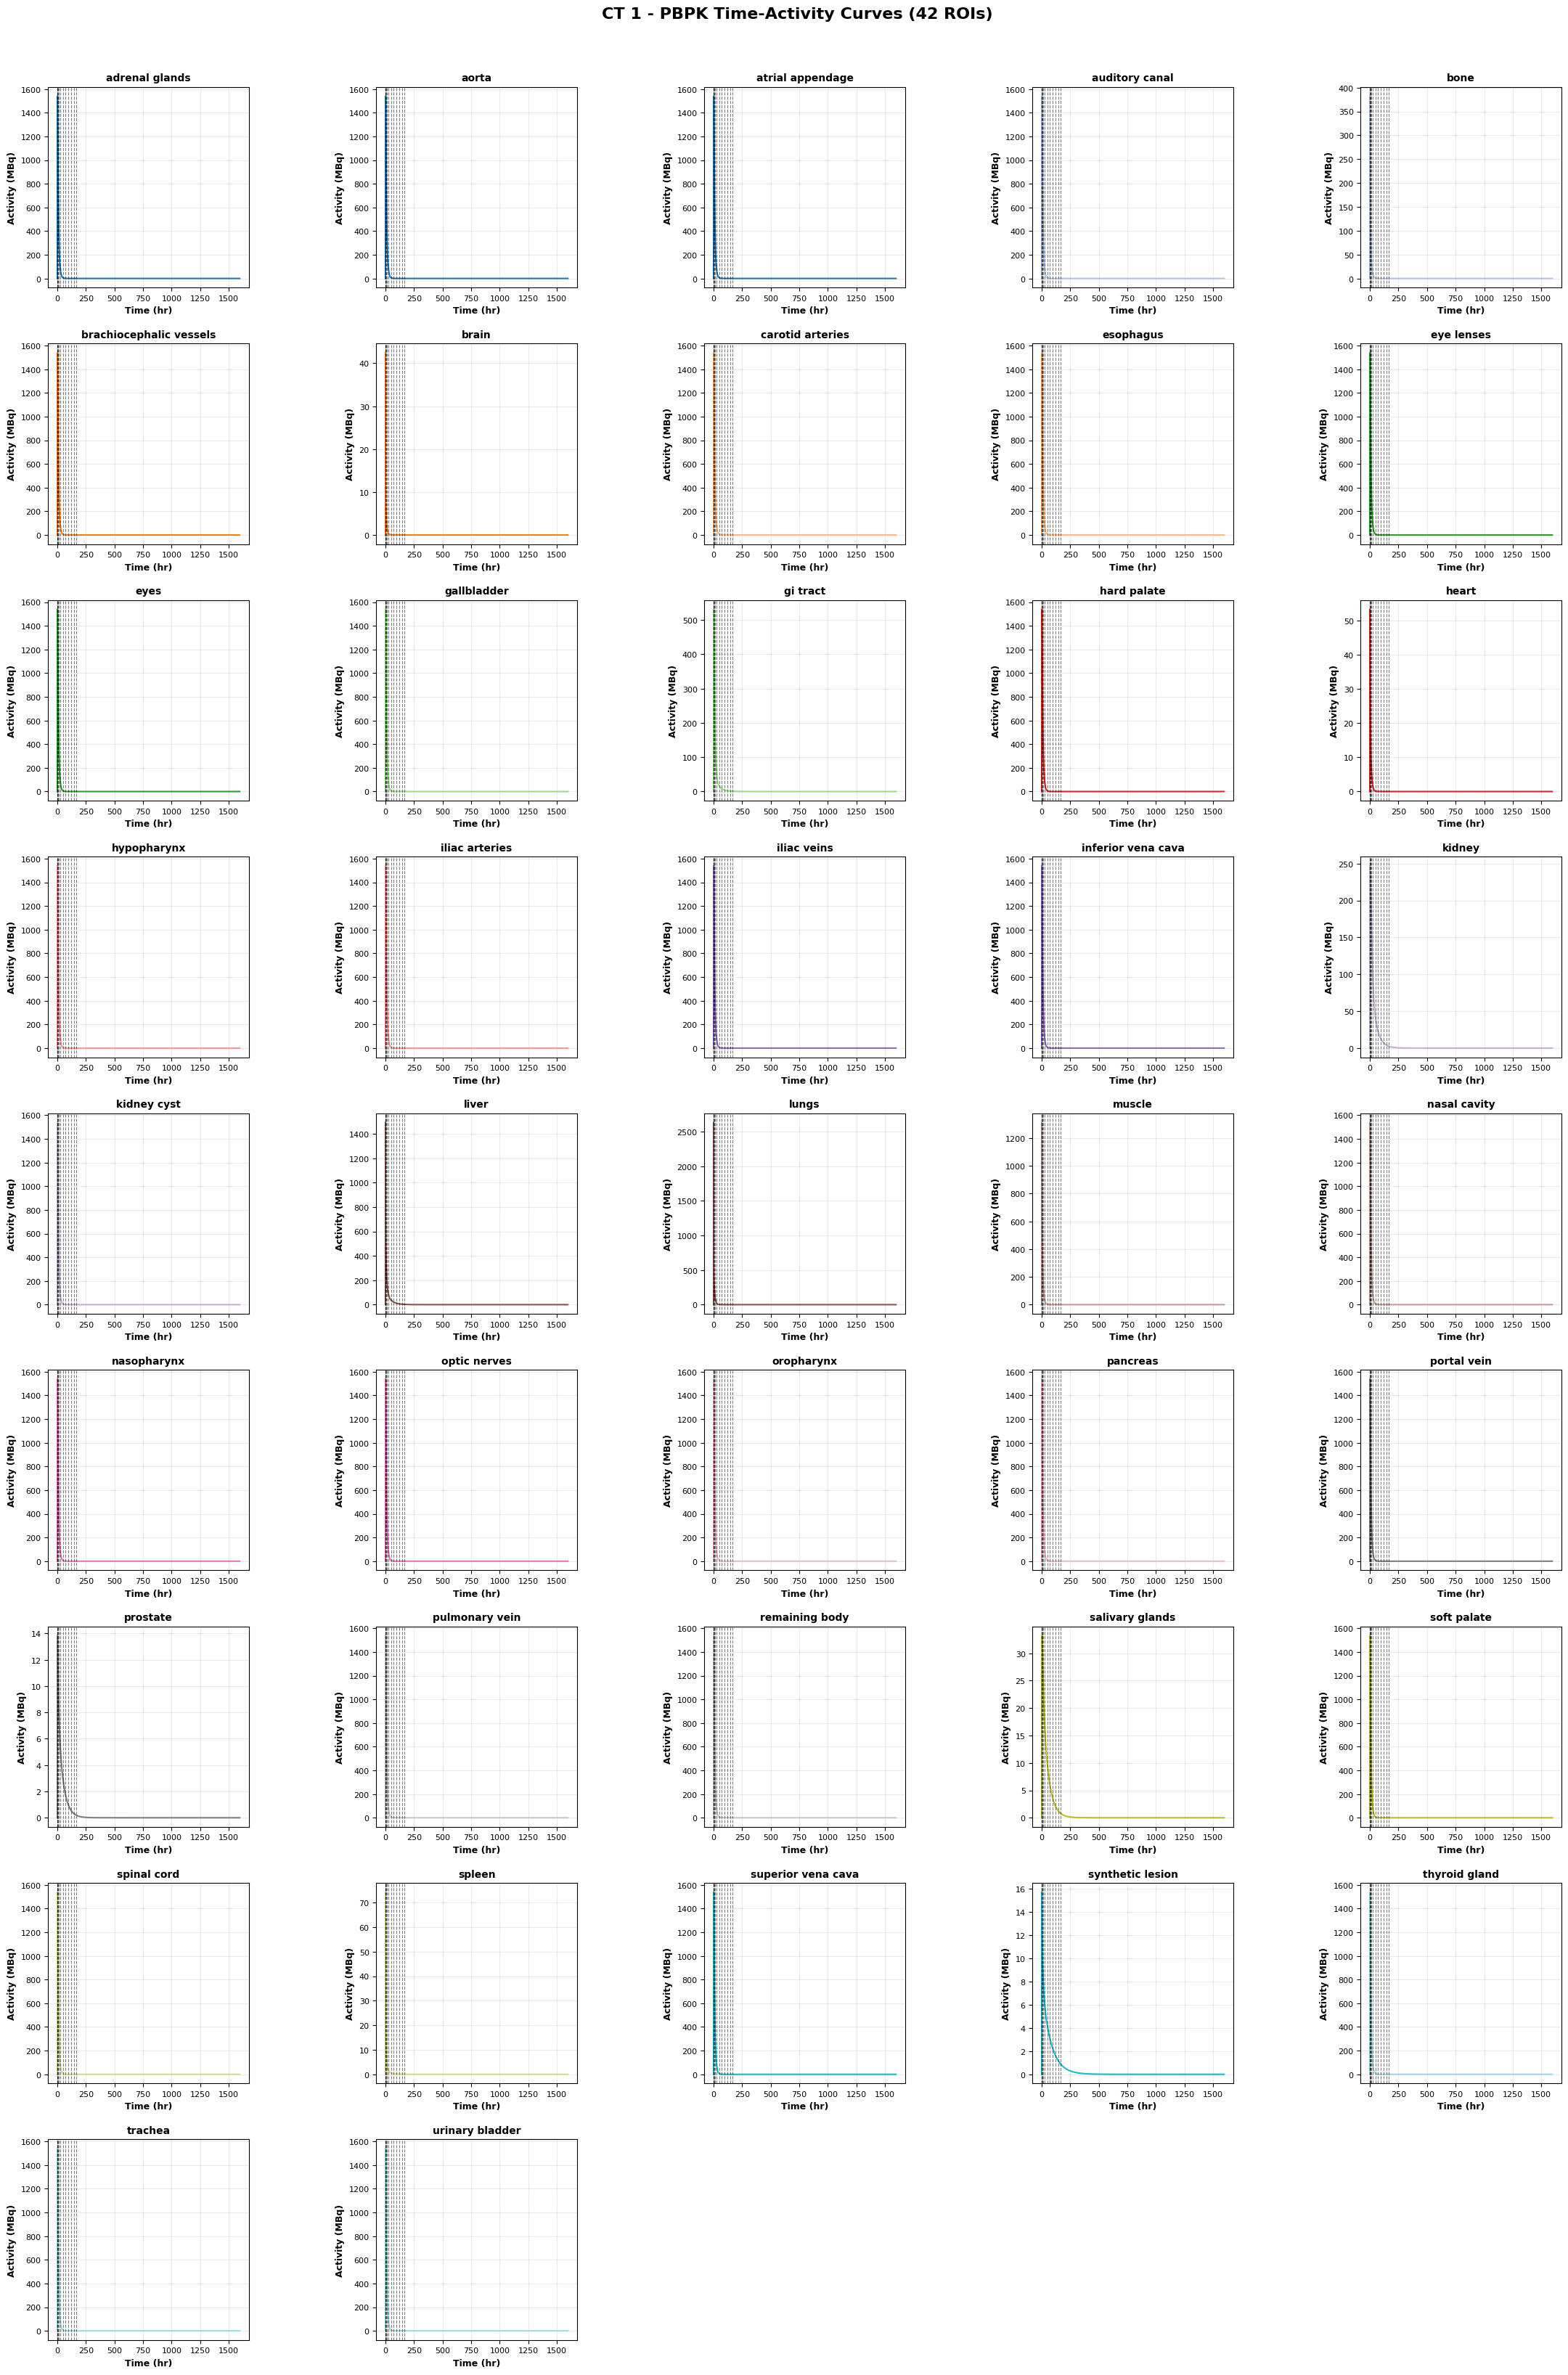

In [39]:
pbpk_store = {}   # {i: {'time_hr': arr, roi: arr_MBq, ...}}
pbpk_meta_store = {}

for i, folder in enumerate(OUT_FOLDERS):
    stage_dir = os.path.join(folder, 'digital_twin', 'pbpk_tac_stage')
    npz_path = os.path.join(stage_dir, 'pbpk_tacs.npz')
    json_path = os.path.join(stage_dir, 'pbpk_tacs.json')
    if not os.path.exists(npz_path):
        print(f'CT {i+1}: pbpk_tacs.npz not found')
        continue

    data = np.load(npz_path, allow_pickle=True)
    time_min = data['time'].astype(float)
    time_hr = time_min / 60.0
    tac_rois = {k.replace('tac_', ''): data[k].astype(float) for k in data.files if k.startswith('tac_')}
    pbpk_store[i] = {'time_hr': time_hr, **tac_rois}

    meta = load_json(json_path) if os.path.exists(json_path) else {}
    pbpk_meta_store[i] = meta
    dt_min = float(np.median(np.diff(time_min))) if time_min.size > 1 else np.nan
    print(f"CT {i+1}: {len(tac_rois)} TACs | points={len(time_min):,} | dt={dt_min:.3g} min | "
          f"range={time_hr[0]:.2f}-{time_hr[-1]:.2f} hr ({time_hr[-1]/24:.2f} days)")
    if meta:
        print(f"  model={meta.get('model_type', '-')} isotope={meta.get('isotope', '-')} "
              f"half_life={meta.get('half_life_min', np.nan)/60:.2f} hr")

    frame_hr = []
    if i in configs:
        ft = sorted(configs[i].get('phase_3', {}).get('spect_postprocess_stage', {}).get('FrameStartTimes', []))
        frame_hr = [t / 60.0 for t in ft]

    plot_rois = sorted(tac_rois.keys())
    fig, axes, nrows, ncols = make_grid(plot_rois and len(plot_rois) or 0, max_cols=5, panel_w=4.6, panel_h=3.6)
    if fig is None:
        continue
    fig.suptitle(f'CT {i+1} - PBPK Time-Activity Curves ({len(plot_rois)} ROIs)', y=1.01)
    colors = plt.get_cmap(plot_spec('pbpk', 'line_cmap', 'tab20'))(np.linspace(0, 1, len(plot_rois)))

    for j, (roi, col) in enumerate(zip(plot_rois, colors)):
        ax = axes[j // ncols][j % ncols]
        ax.plot(time_hr, tac_rois[roi], lw=1.5, color=col)
        for ft in frame_hr:
            ax.axvline(ft, color='k', lw=0.8, ls='--', alpha=0.5)
        if PBPK_XLIM_HR is not None:
            ax.set_xlim(*PBPK_XLIM_HR)
        ax.set_yscale(PBPK_Y_SCALE)
        ax.set_title(roi.replace('_', ' '), fontsize=10)
        ax.set_xlabel('Time (hr)', fontsize=9)
        ax.set_ylabel('Activity (MBq)', fontsize=9)
        ax.grid(True, alpha=0.25)
        ax.tick_params(labelsize=8)
        if FORCE_SQUARE_PANELS:
            ax.set_box_aspect(1)

    for j in range(len(plot_rois), nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)

    if frame_hr:
        print(f"  SPECT frame times: {[f'{t:.2f}h' for t in frame_hr]}")
    finish_plot(fig, f'ct_{i+1}_pbpk_tacs')


## 6 - Phase 2: Simulation Outputs

Expected plots: SIMIND attenuation/activity maps and OpenGATE dose maps if those stages were run.


### 6a - SIMIND Attenuation and Activity Maps

Expected output: SIMIND geometry text plus square coronal max-projection panels for the attenuation map and each ROI activity map.


CT 1  prefix=simind  ROIs=['remaining_body', 'kidney', 'liver', 'salivary_glands', 'synthetic_lesion', 'lungs']
  scale_factor=18.5063  spacing_cm=[0.479, 0.479, 0.479]  shape=[204, 170, 170]
  pixel_width=0.479 cm  slice_width=0.479 cm


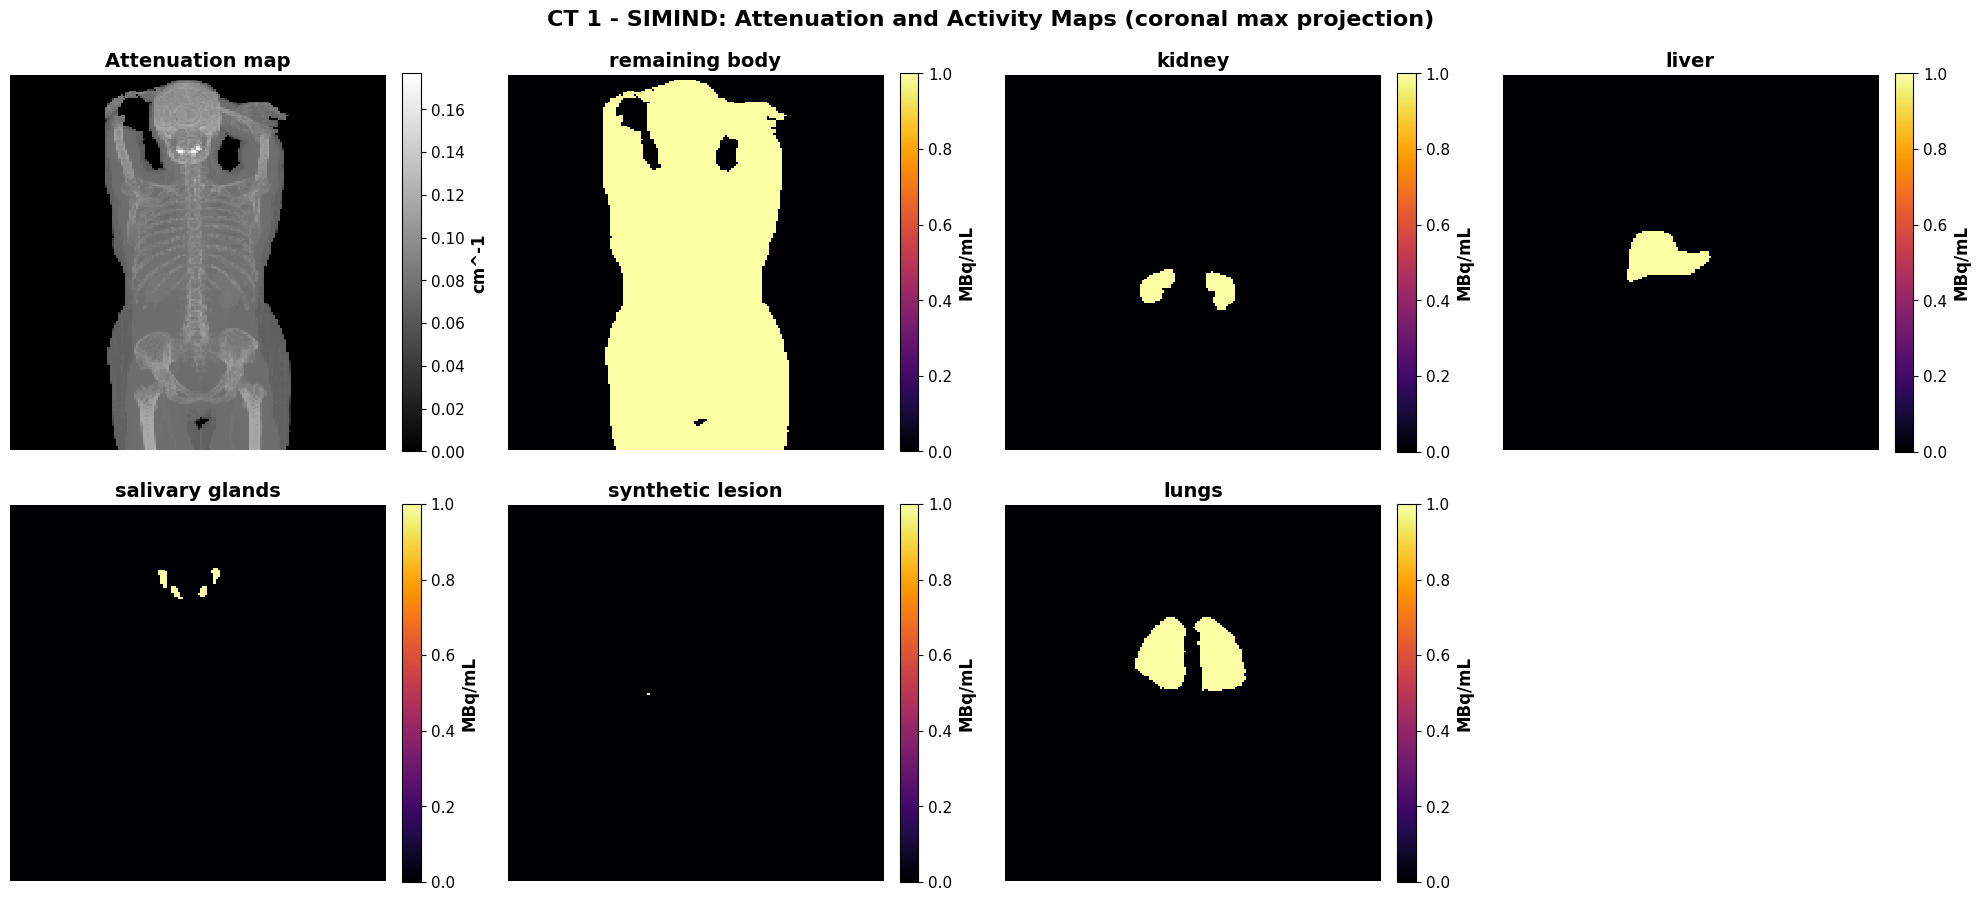

In [40]:
simind_meta_store = {}

for i, folder in enumerate(OUT_FOLDERS):
    meta_path = os.path.join(folder, 'pipeline_metadata', 'simind_simulation_stage.json')
    if not os.path.exists(meta_path):
        print(f'CT {i+1}: SIMIND metadata not found')
        continue

    m = load_json(meta_path)
    simind_meta_store[i] = m

    prefix = m.get('file_prefix', 'simind')
    roi_list = m.get('roi_list', [])
    scale = m.get('scale_factor', 1.0)
    geom = m.get('geometry', {})
    prep_dir = m.get('preprocess_dir', '')
    work_dir = m.get('work_dir', '')
    spacing = m.get('arr_px_spacing_cm', [0, 0, 0])
    shape_new = [int(v) for v in m.get('arr_shape_new', [0, 0, 0])]
    z_dim, y_dim, x_dim = shape_new if len(shape_new) == 3 else (0, 0, 0)

    print(f'CT {i+1}  prefix={prefix}  ROIs={roi_list}')
    print(f"  scale_factor={scale:.4f}  spacing_cm={[round(s, 3) for s in spacing]}  shape={shape_new}")
    print(f"  pixel_width={geom.get('input_pixel_width', 0):.3f} cm  "
          f"slice_width={geom.get('input_slice_width', 0):.3f} cm")

    atn_flat = None
    for search_dir in [prep_dir, work_dir]:
        atn_p = os.path.join(search_dir, f'{prefix}_atn_av.bin')
        if os.path.exists(atn_p):
            atn_flat = np.fromfile(atn_p, dtype=np.float32)
            break

    act_maps = {}
    act_paths = m.get('binary_roi_act_map_paths', {})
    for roi in roi_list:
        p = act_paths.get(roi, os.path.join(prep_dir, f'{prefix}_{roi}_act_av.bin'))
        if os.path.exists(p) and z_dim and y_dim and x_dim:
            flat = np.fromfile(p, dtype=np.float32)
            if flat.size == z_dim * y_dim * x_dim:
                act_maps[roi] = flat.reshape(z_dim, y_dim, x_dim)[::-1]
            else:
                print(f'  {roi}: binary size mismatch, expected {z_dim*y_dim*x_dim:,}, got {flat.size:,}')

    n_plots = (1 if atn_flat is not None else 0) + len(act_maps)
    if n_plots == 0:
        print('  No SIMIND binary maps found')
        continue

    fig, axes, nrows, ncols = make_grid(n_plots, max_cols=4, panel_w=5.0, panel_h=4.6)
    fig.suptitle(f'CT {i+1} - SIMIND: Attenuation and Activity Maps (coronal max projection)')
    idx = 0

    if atn_flat is not None and z_dim and y_dim and x_dim and atn_flat.size == z_dim * y_dim * x_dim:
        atn = atn_flat.reshape(z_dim, y_dim, x_dim)[::-1]
        ax = axes[idx // ncols][idx % ncols]
        im = plot_image(ax, np.max(atn, axis=1), cmap=plot_spec('simind', 'atn_cmap', 'gray'), title='Attenuation map')
        add_colorbar(fig, ax, im, label='cm^-1')
        idx += 1

    for roi, arr in act_maps.items():
        ax = axes[idx // ncols][idx % ncols]
        im = plot_image(ax, np.max(arr, axis=1), cmap=plot_spec('simind', 'activity_cmap', 'inferno'), title=roi.replace('_', ' '))
        add_colorbar(fig, ax, im, label='MBq/mL')
        idx += 1

    for j in range(idx, nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    finish_plot(fig, f'ct_{i+1}_simind_maps')


### 6b - SIMIND Projection Data

Expected output: for each patient, the summed SIMIND projection stack before SPECT reconstruction. The plot shows one selected projection angle plus the sum across all projection angles for the selected energy window(s).



CT 1 - Raw SIMIND summed projection table
  window              shape shown_idx      file_sum     shown_sum  angle_sum_max  file
      w2      (96, 20, 128)         0     2.485e+03     2.680e+01      1.221e+02  simind_tot_w2.a00


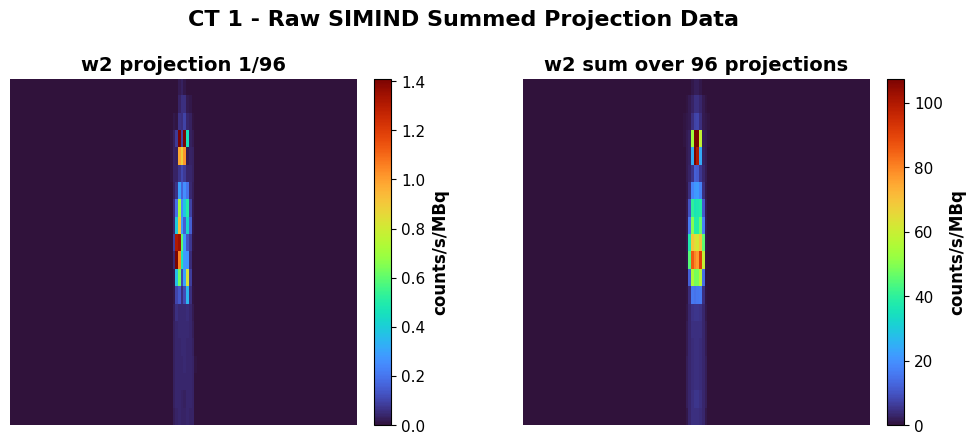

In [41]:
simind_projection_store = {}


def _header_value_from_lines(lines, key, caster=int):
    key_l = key.lower()
    for line in lines:
        if key_l in line.lower():
            value = line.split(':=')[-1].strip()
            return caster(value.split()[0])
    return None


def simind_header_dims(header_path):
    with open(header_path, encoding='utf-8', errors='replace') as f:
        lines = f.readlines()
    return (
        _header_value_from_lines(lines, 'matrix size [1]', int),
        _header_value_from_lines(lines, 'matrix size [2]', int),
        _header_value_from_lines(lines, 'total number of images', int),
    )


def find_simind_header(meta, window):
    header_dir = meta.get('header_dir') or meta.get('outputs', {}).get('header_dir') or ''
    prefix = meta.get('file_prefix', 'simind')
    rois = list((meta.get('simind_projection_paths') or {}).keys())
    rois += [r for r in meta.get('roi_list', []) if r not in rois]
    for roi in rois:
        for name in [f'{prefix}_{roi}_0_tot_{window}.h00', f'{prefix}_{roi}_tot_{window}.h00']:
            candidate = os.path.join(header_dir, name)
            if os.path.exists(candidate):
                return candidate
    return None


def get_summed_simind_projection_paths(meta, folder):
    paths = {}
    paths.update(meta.get('outputs', {}).get('summed_projection_paths', {}) or {})
    paths.update(meta.get('summed_projection_paths', {}) or {})
    prefix = meta.get('file_prefix', 'simind')
    sim_dir = meta.get('output_dir') or meta.get('phase_output_dir') or os.path.join(folder, 'simulations')
    for window in ('w1', 'w2', 'w3'):
        paths.setdefault(window, os.path.join(sim_dir, f'{prefix}_tot_{window}.a00'))
    return paths


def infer_simind_projection_shape(path, meta, window):
    header_path = find_simind_header(meta, window)
    dim1 = dim2 = n_proj = None
    if header_path:
        dim1, dim2, n_proj = simind_header_dims(header_path)
    if n_proj is None:
        n_proj = int(meta.get('num_projections') or meta.get('NumProjections') or 0)
    if dim1 is None:
        dim1 = int(meta.get('output_img_size') or meta.get('OutputImgSize') or 0)

    n_float = os.path.getsize(path) // np.dtype(np.float32).itemsize
    if dim1 and n_proj and not dim2 and n_float % (dim1 * n_proj) == 0:
        dim2 = int(n_float // (dim1 * n_proj))
    if dim1 and dim2 and not n_proj and n_float % (dim1 * dim2) == 0:
        n_proj = int(n_float // (dim1 * dim2))
    if not (dim1 and dim2 and n_proj):
        raise ValueError(f'Could not infer SIMIND projection shape for {path}')
    expected = int(dim1 * dim2 * n_proj)
    if n_float != expected:
        raise ValueError(f'Unexpected SIMIND projection size for {path}: got {n_float}, expected {expected}')
    return int(n_proj), int(dim2), int(dim1), header_path


def read_raw_simind_projection_stack(path, meta, window):
    n_proj, dim2, dim1, header_path = infer_simind_projection_shape(path, meta, window)
    arr = np.fromfile(path, dtype=np.float32).reshape((n_proj, dim2, dim1))
    return arr, header_path


def positive_percentile(arr, pct_value):
    vals = np.asarray(arr, dtype=float)
    vals = vals[np.isfinite(vals) & (vals > 0)]
    if vals.size:
        return float(np.percentile(vals, pct_value))
    return None


windows_cfg = globals().get('SIMIND_PROJECTION_WINDOWS', ('w2',))
if isinstance(windows_cfg, str):
    windows_cfg = (windows_cfg,)
projection_windows = tuple(str(w).lower() for w in windows_cfg)
projection_index_cfg = int(globals().get('SIMIND_PROJECTION_INDEX', 0))
projection_percentile = float(globals().get('SIMIND_PROJECTION_PERCENTILE', 99.5))
projection_cmap = plot_spec('simind', 'projection_cmap', 'turbo')

for i, folder in enumerate(OUT_FOLDERS):
    meta = simind_meta_store.get(i)
    if meta is None:
        meta_path = os.path.join(folder, 'pipeline_metadata', 'simind_simulation_stage.json')
        if os.path.exists(meta_path):
            meta = load_json(meta_path)
        else:
            print(f'CT {i+1}: SIMIND metadata not found')
            continue

    summed_paths = get_summed_simind_projection_paths(meta, folder)
    available = [(w, summed_paths.get(w)) for w in projection_windows]
    available = [(w, p) for w, p in available if p and os.path.exists(p)]
    if not available:
        print(f'CT {i+1}: no summed SIMIND projection files for windows {projection_windows}')
        continue

    simind_projection_store[i] = {}
    fig, axes = plt.subplots(len(available), 2, figsize=(10.5, 4.5 * len(available)), squeeze=False)
    fig.suptitle(f'CT {i+1} - Raw SIMIND Summed Projection Data')

    print(f"\nCT {i+1} - Raw SIMIND summed projection table")
    print(f"  {'window':>6s} {'shape':>18s} {'shown_idx':>9s} {'file_sum':>13s} {'shown_sum':>13s} {'angle_sum_max':>14s}  file")

    for row_idx, (window, proj_path) in enumerate(available):
        try:
            stack, header_path = read_raw_simind_projection_stack(proj_path, meta, window)
        except Exception as exc:
            print(f'  {window:>6s} failed to load {os.path.basename(proj_path)}: {exc}')
            axes[row_idx, 0].set_visible(False)
            axes[row_idx, 1].set_visible(False)
            continue

        shown_idx = min(max(projection_index_cfg, 0), stack.shape[0] - 1)
        shown_projection = stack[shown_idx]
        angle_sum = np.sum(stack, axis=0)
        simind_projection_store[i][window] = {
            'path': proj_path,
            'shape': stack.shape,
            'shown_index': shown_idx,
            'shown_projection': shown_projection,
            'angle_sum': angle_sum,
            'header_path': header_path,
        }

        vmax_one = positive_percentile(shown_projection, projection_percentile)
        vmax_sum = positive_percentile(angle_sum, projection_percentile)
        im0 = plot_image(
            axes[row_idx, 0],
            shown_projection,
            cmap=projection_cmap,
            title=f'{window} projection {shown_idx + 1}/{stack.shape[0]}',
            vmin=0,
            vmax=vmax_one,
        )
        add_colorbar(fig, axes[row_idx, 0], im0, label='counts/s/MBq')
        im1 = plot_image(
            axes[row_idx, 1],
            angle_sum,
            cmap=projection_cmap,
            title=f'{window} sum over {stack.shape[0]} projections',
            vmin=0,
            vmax=vmax_sum,
        )
        add_colorbar(fig, axes[row_idx, 1], im1, label='counts/s/MBq')

        print(f"  {window:>6s} {str(tuple(stack.shape)):>18s} {shown_idx:9d} "
              f"{np.sum(stack):13.3e} {np.sum(shown_projection):13.3e} {np.max(angle_sum):14.3e}  {os.path.basename(proj_path)}")

    finish_plot(fig, f'ct_{i+1}_simind_summed_projections')


### 6c - OpenGATE Dose Maps

Expected output: one square panel per ROI dose map plus the summed dose map if available. Units are Gy/decay at this stage.


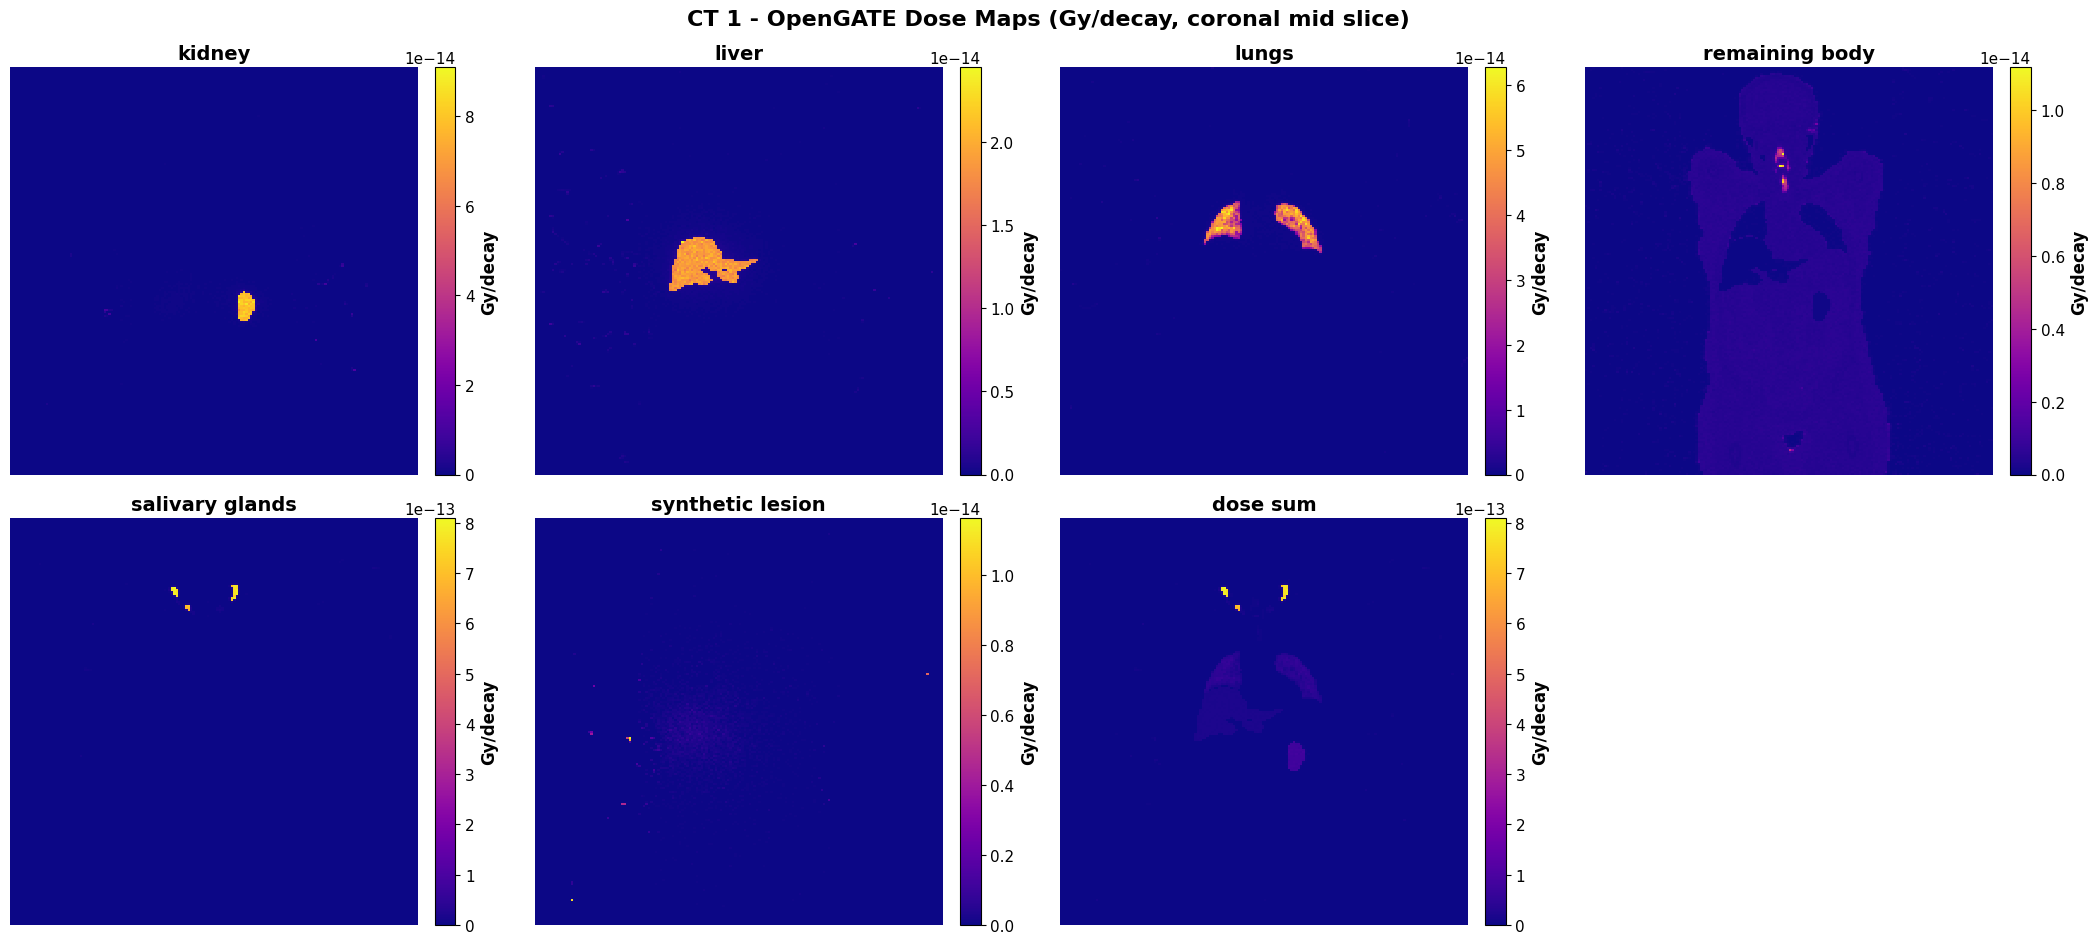

In [42]:
for i, folder in enumerate(OUT_FOLDERS):
    og_cfg = configs.get(i, {}).get('phase_2', {}).get('opengate_stage', {})
    prefix = og_cfg.get('file_prefix', 'opengate_simulation')
    og_dir = os.path.join(folder, 'simulations', og_cfg.get('sub_dir_name', 'opengate_simulation'))
    og_work = os.path.join(og_dir, 'work_dir')

    tag = prefix + '_dose_'
    dose_roi_files = [f for f in list_files(og_dir, '.nii.gz') if os.path.basename(f).startswith(tag)]
    if not dose_roi_files:
        dose_roi_files = [f for f in list_files(og_work, '.nii.gz') if os.path.basename(f).startswith(tag)]

    dose_sum_path = None
    for candidate in [
        os.path.join(folder, 'simulations', prefix + '_dose_sum.nii.gz'),
        os.path.join(og_dir, prefix + '_dose_sum.nii.gz'),
        os.path.join(og_work, prefix + '_dose_sum.nii.gz'),
    ]:
        if os.path.exists(candidate):
            dose_sum_path = candidate
            break

    all_dose = []
    for p in dose_roi_files:
        s = stem(p)
        if s.endswith('_dose_sum'):
            continue
        roi_label = s[len(tag):] if s.startswith(tag) else s
        all_dose.append((roi_label, p))
    if dose_sum_path:
        all_dose.append(('dose sum', dose_sum_path))

    if not all_dose:
        print(f'CT {i+1}: no OpenGATE dose maps found (--dosimetry may not have run)')
        continue

    fig, axes, nrows, ncols = make_grid(len(all_dose), max_cols=4, panel_w=5.3, panel_h=4.8)
    fig.suptitle(f'CT {i+1} - OpenGATE Dose Maps (Gy/decay, coronal mid slice)')
    cmap = plot_spec('opengate', 'cmap', 'plasma')

    for j, (label, path) in enumerate(all_dose):
        ax = axes[j // ncols][j % ncols]
        img = sitk.ReadImage(path)
        arr = sitk.GetArrayFromImage(img)[::-1]
        sp = img.GetSpacing()
        z, y, x = arr.shape
        im = plot_image(ax, arr[:, y // 2, :], sp=sp, view='coronal', cmap=cmap, title=label.replace('_', ' '))
        add_colorbar(fig, ax, im, label='Gy/decay')

    for j in range(len(all_dose), nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    finish_plot(fig, f'ct_{i+1}_opengate_dose_maps')


## 7 - Phase 3: Post-processing Outputs

Expected plots: reconstructed SPECT frames, per-ROI activity maps, total dose maps, and dose integration summaries.


### 7a - Reconstructed SPECT

Expected output: three views per selected frame. Use `SPECT_FRAME_MODE='last'` in setup if you only want the final frame.


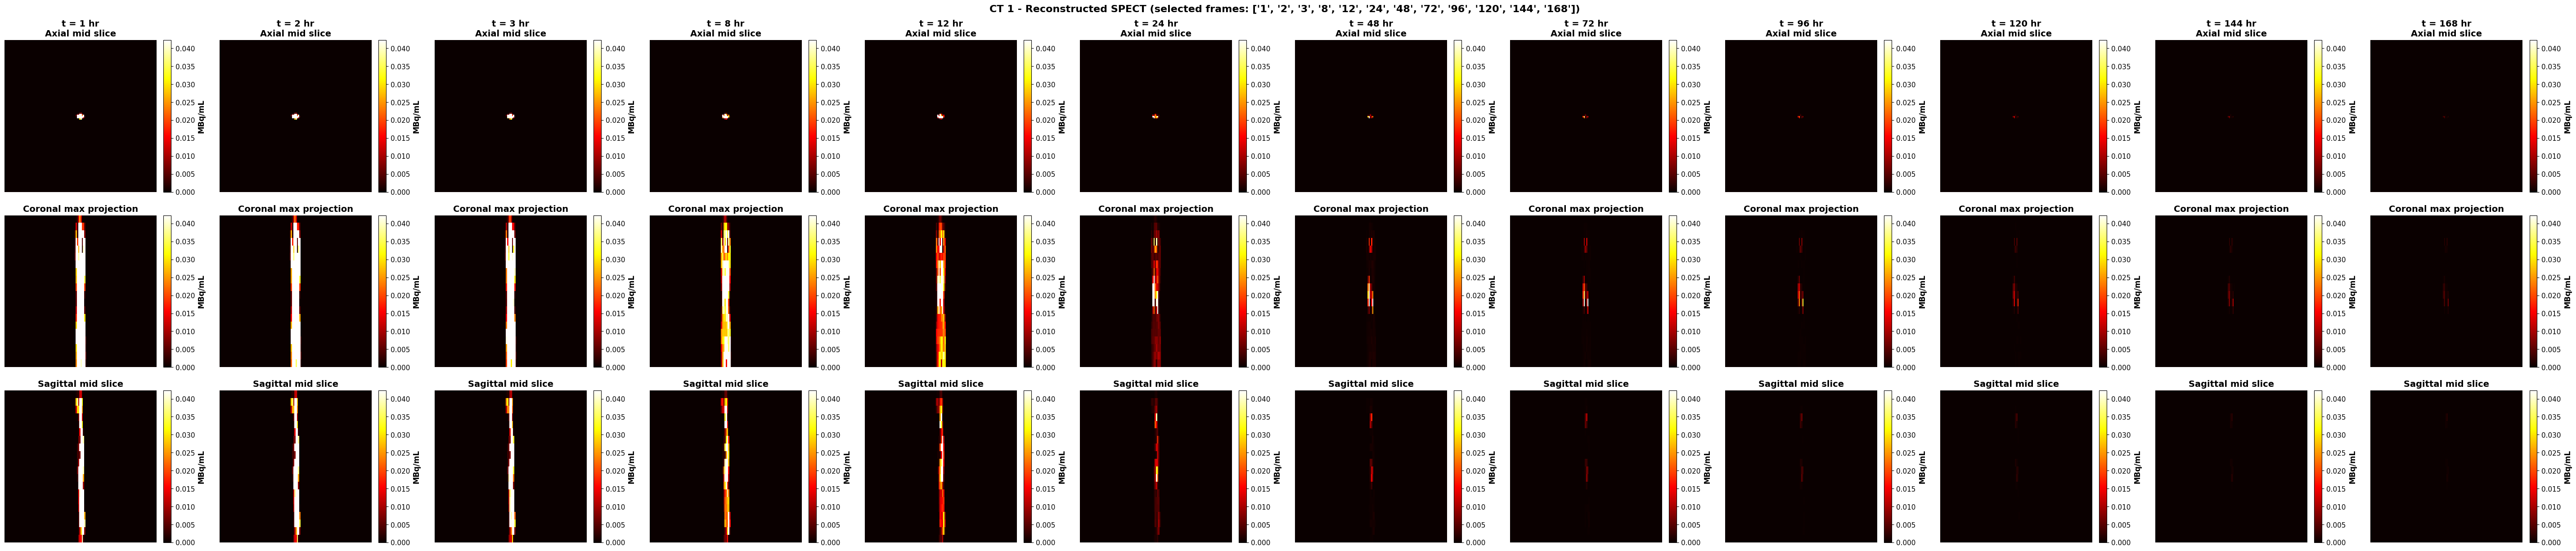

In [43]:
recon_paths_store = {}

for i, folder in enumerate(OUT_FOLDERS):
    pp_dir = os.path.join(folder, 'post_processing')
    recons = [
        os.path.join(pp_dir, f) for f in sorted(os.listdir(pp_dir))
        if f.startswith('reconstructed_SPECT_') and f.endswith('.nii.gz')
    ] if os.path.isdir(pp_dir) else []

    if not recons:
        print(f'CT {i+1}: no reconstructed SPECT (--spect --postprocess may not have run)')
        continue

    frame_map = {}
    for p in recons:
        label = os.path.basename(p).replace('reconstructed_SPECT_', '').replace('.nii.gz', '')
        frame_map[label] = p
    recon_paths_store[i] = frame_map

    frame_labels = select_frame_labels(frame_map.keys(), SPECT_FRAME_MODE, SPECT_SELECTED_FRAMES)
    if not frame_labels:
        print(f'CT {i+1}: no SPECT frames selected')
        continue

    arrs = {}
    vmax = 0.0
    for label in frame_labels:
        img = sitk.ReadImage(frame_map[label])
        arr = sitk.GetArrayFromImage(img)[::-1]
        sp = img.GetSpacing()
        arrs[label] = (arr, sp)
        pos = arr[arr > 0]
        if pos.size:
            vmax = max(vmax, float(np.percentile(pos, plot_spec('spect', 'percentile', 99.5))))
    vmax = vmax if SPECT_SHARED_SCALE and vmax > 0 else None

    ncols = len(frame_labels)
    fig, axes = plt.subplots(3, ncols, figsize=(4.8 * ncols, 12.5), squeeze=False)
    fig.suptitle(f'CT {i+1} - Reconstructed SPECT (selected frames: {frame_labels})')
    cmap = plot_spec('spect', 'cmap', 'hot')

    row_labels = ['Axial mid slice', 'Coronal max projection', 'Sagittal mid slice']
    for j, label in enumerate(frame_labels):
        arr, sp = arrs[label]
        z, y, x = arr.shape
        views = [
            (arr[z//2, :, :],     'axial'),
            (np.max(arr, axis=1), 'coronal'),
            (arr[:, :, x//2],     'sagittal'),
        ]
        for row, (sl, view) in enumerate(views):
            title = f't = {label} hr\n{row_labels[row]}' if row == 0 else row_labels[row]
            im = plot_image(axes[row][j], sl, sp=sp, view=view, cmap=cmap, title=title, vmin=0, vmax=vmax)
            add_colorbar(fig, axes[row][j], im, label='MBq/mL')

    finish_plot(fig, f'ct_{i+1}_reconstructed_spect')


### 7b - Per-ROI Activity Maps

Expected output: one square coronal-mid panel per postprocessed ROI activity map.


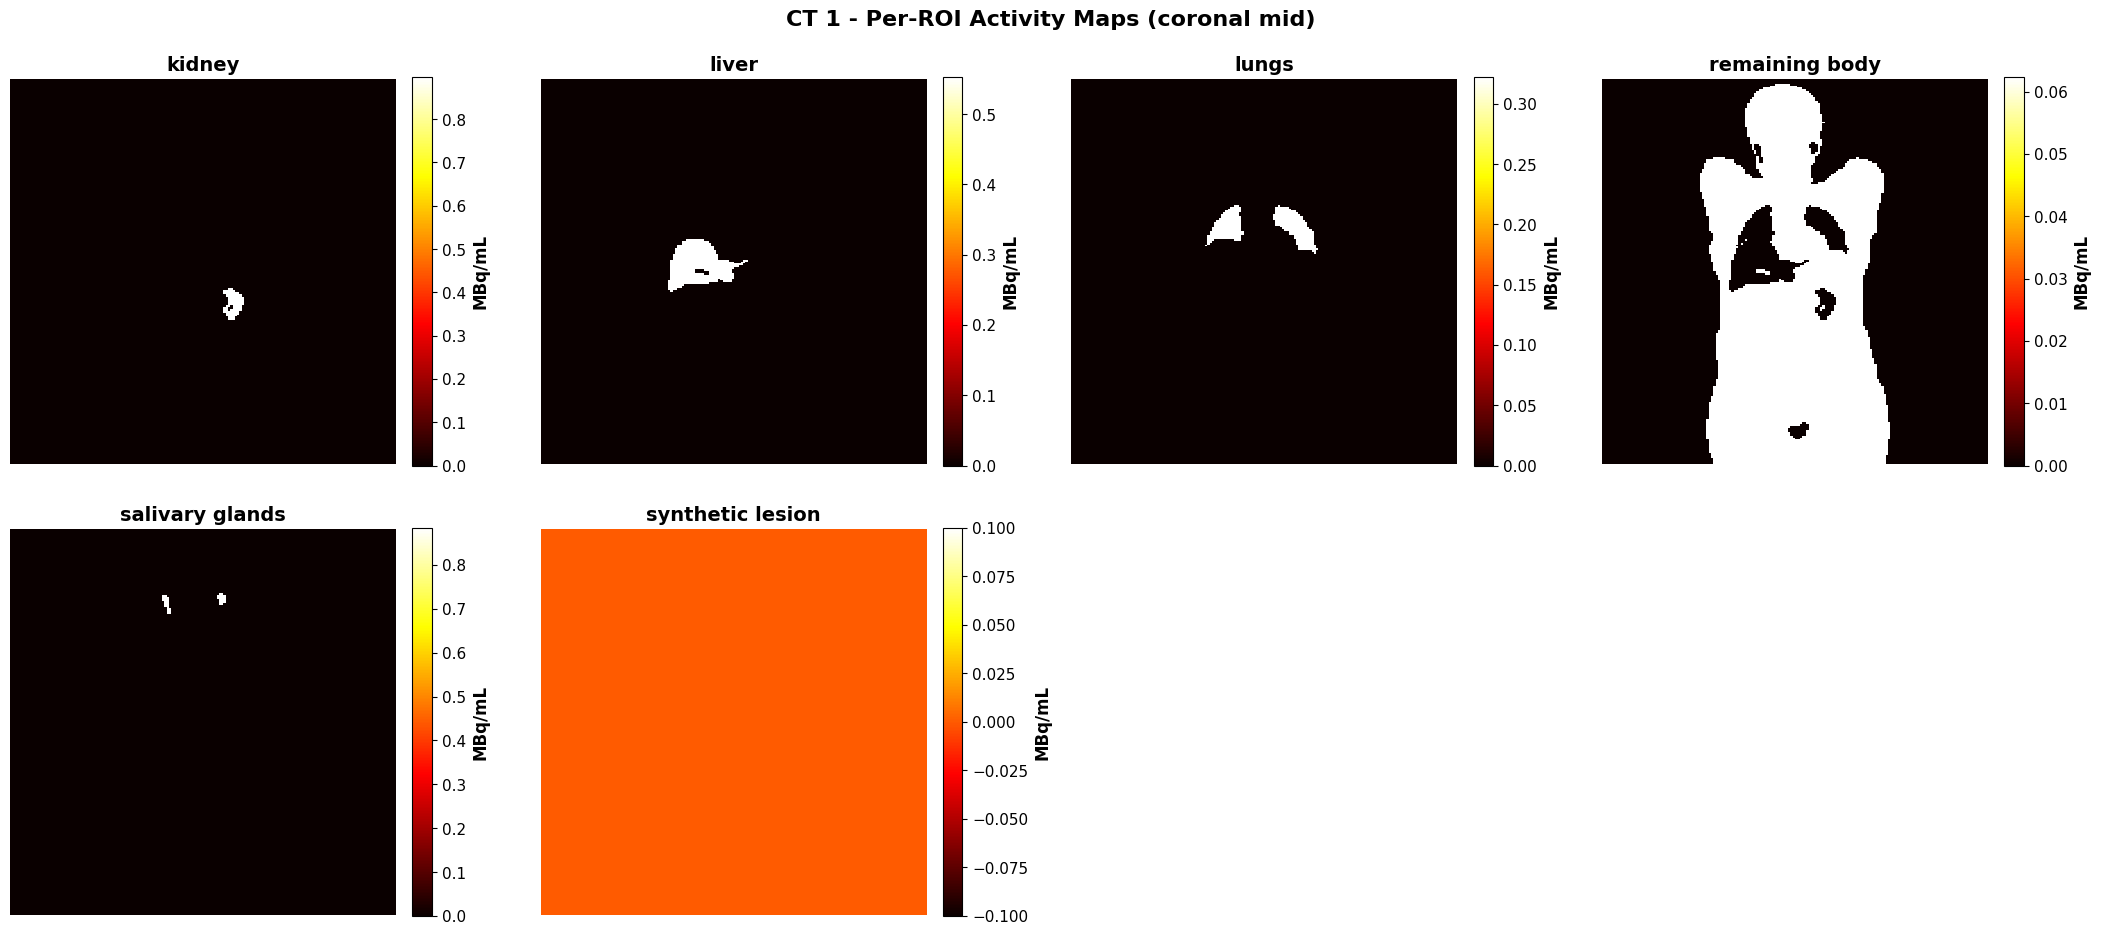

In [44]:
for i, folder in enumerate(OUT_FOLDERS):
    work_dir = os.path.join(folder, 'post_processing', 'spect_postprocess', 'work_dir')
    act_files = list_files(work_dir, '_act_av.nii.gz')
    if not act_files:
        print(f'CT {i+1}: no per-ROI activity maps')
        continue

    sp_prefix = configs.get(i, {}).get('phase_3', {}).get('spect_postprocess_stage', {}).get('file_prefix', 'spect_postprocess')
    labels = []
    for p in act_files:
        s = stem(p).replace('_act_av', '')
        labels.append(s[len(sp_prefix)+1:] if s.startswith(sp_prefix + '_') else s)

    fig, axes, nrows, ncols = make_grid(len(act_files), max_cols=4, panel_w=5.3, panel_h=4.8)
    fig.suptitle(f'CT {i+1} - Per-ROI Activity Maps (coronal mid)')
    cmap = plot_spec('activity', 'cmap', 'hot')

    for j, (path, label) in enumerate(zip(act_files, labels)):
        ax = axes[j // ncols][j % ncols]
        img = sitk.ReadImage(path)
        arr = sitk.GetArrayFromImage(img)[::-1]
        sp = img.GetSpacing()
        z, y, x = arr.shape
        im = plot_image(ax, arr[:, y//2, :], sp=sp, view='coronal', cmap=cmap, title=label.replace('_', ' '))
        add_colorbar(fig, ax, im, label='MBq/mL')

    for j in range(len(act_files), nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    finish_plot(fig, f'ct_{i+1}_roi_activity_maps')


### 7c - Total Dose Map

Expected output: total absorbed dose summary and three square anatomical views per patient.


CT 1  dose shape=(204, 170, 170)  spacing=(4.79, 4.79, 4.79) mm  max=428.1 Gy


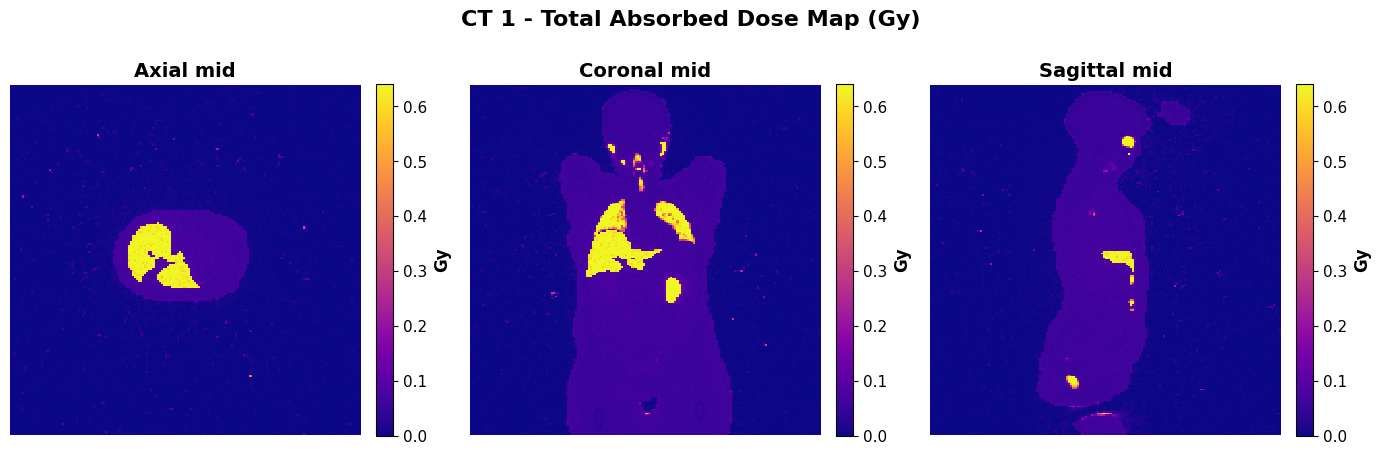

In [45]:
for i, folder in enumerate(OUT_FOLDERS):
    dose_path = os.path.join(folder, 'post_processing', 'dosemap_postprocess_total_dose.nii.gz')
    if not os.path.exists(dose_path):
        print(f'CT {i+1}: total dose map not found (--dosimetry --postprocess may not have run)')
        continue

    img = sitk.ReadImage(dose_path)
    arr = sitk.GetArrayFromImage(img)[::-1]
    sp = img.GetSpacing()
    z, y, x = arr.shape
    pos = arr[arr > 0]
    vm = float(np.percentile(pos, plot_spec('dose', 'percentile', 99.0))) if pos.size else float(np.max(arr))
    print(f'CT {i+1}  dose shape={arr.shape}  spacing={tuple(round(s,2) for s in sp)} mm  max={np.max(arr):.4g} Gy')

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
    fig.suptitle(f'CT {i+1} - Total Absorbed Dose Map (Gy)')
    cmap = plot_spec('dose', 'cmap', 'plasma')

    views = [
        ('Axial mid',    arr[z//2, :, :],  'axial'),
        ('Coronal mid',  arr[:, y//2, :],  'coronal'),
        ('Sagittal mid', arr[:, :, x//2], 'sagittal'),
    ]
    for ax, (title, sl, view) in zip(axes, views):
        im = plot_image(ax, sl, sp=sp, view=view, cmap=cmap, title=title, vmin=0, vmax=vm)
        add_colorbar(fig, ax, im, label='Gy')
    finish_plot(fig, f'ct_{i+1}_total_dose')


### 7d - Dose Integration Summary

Expected output: integration range and cumulated activity per ROI from dose postprocess metadata. This is useful for checking whether dose used the full PBPK horizon.



CT 1: dose integration range = [0.0, 1595.28] hr ([0.0, 66.47] days)
  ROI                   dose-stage CA direct PBPK CA  folded/additional
  kidney                     27.796e12       27.796e12            0.000e12
  liver                      33.969e12       33.969e12            0.000e12
  lungs                      17.137e12       17.137e12           -0.000e12
  remaining_body            112.584e12       54.063e12           58.521e12
  salivary_glands             5.004e12        5.004e12           -0.000e12
  synthetic_lesion            2.358e12        2.358e12            0.000e12
  remaining_body folded-from metadata:
    bone                        6.761e12 decays
    brain                       0.286e12 decays
    gi_tract                   24.891e12 decays
    heart                       1.126e12 decays
    muscle                     23.160e12 decays
    prostate                    1.602e12 decays
    spleen                      0.697e12 decays


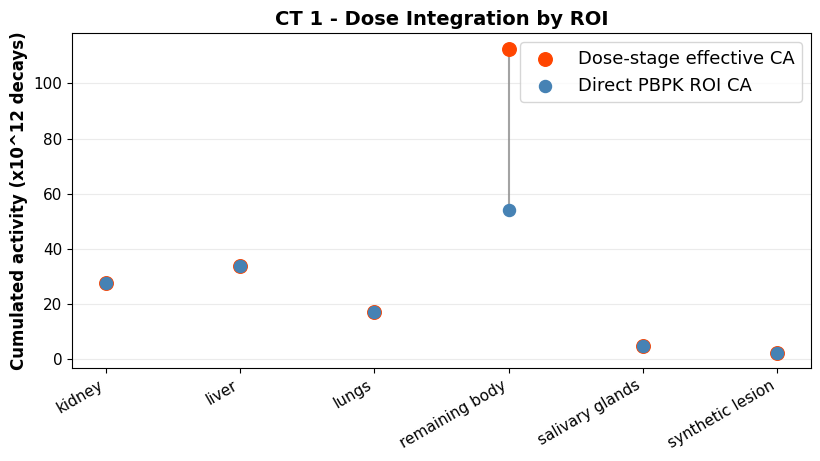

In [46]:
dose_summary_store = {}


def pbpk_decays_for_roi(patient_idx, roi):
    if patient_idx not in pbpk_store or roi not in pbpk_store[patient_idx]:
        return np.nan
    t_min = np.asarray(pbpk_store[patient_idx]['time_hr'], dtype=float) * 60.0
    y_mbq = np.asarray(pbpk_store[patient_idx][roi], dtype=float)
    return float(np.trapezoid(y_mbq, t_min) * 60.0 * 1e6)


for i, folder in enumerate(OUT_FOLDERS):
    meta_path = os.path.join(folder, 'pipeline_metadata', 'dosemap_postprocess_stage.json')
    if not os.path.exists(meta_path):
        print(f'CT {i+1}: dose postprocess metadata not found')
        continue

    m = load_json(meta_path)
    dose_summary_store[i] = m
    decays = m.get('cumulated_activities_per_roi_decays', {})
    range_hr = m.get('integration_range_hr', [])
    range_days = m.get('integration_range_days', [])
    dose_inputs = m.get('dose_input_paths', {})
    simulated_rois = set(dose_inputs.keys()) - {'remaining_body'}

    print(f"\nCT {i+1}: dose integration range = {range_hr} hr ({range_days} days)")
    if not decays:
        print('  No cumulated activity entries found')
        continue

    # The dose stage may fold PBPK ROIs that were not simulated as separate sources
    # into remaining_body. This table separates the raw PBPK TAC integral from the
    # effective dose-weighting value written in metadata.
    print(f"  {'ROI':20s} {'dose-stage CA':>14s} {'direct PBPK CA':>14s} {'folded/additional':>18s}")
    for roi, val in sorted(decays.items()):
        direct = pbpk_decays_for_roi(i, roi)
        folded = val - direct if np.isfinite(direct) else np.nan
        print(f"  {roi:20s} {val/1e12:12.3f}e12 {direct/1e12:12.3f}e12 {folded/1e12:16.3f}e12")

    folded_meta = m.get('remaining_body_folded_from_decays', {})
    if folded_meta:
        print('  remaining_body folded-from metadata:')
        for roi, val in sorted(folded_meta.items()):
            print(f'    {roi:20s} {val/1e12:12.3f}e12 decays')
    elif 'remaining_body' in decays and i in pbpk_store:
        folded_rois = [
            roi for roi in pbpk_store[i]
            if roi != 'time_hr' and roi != 'remaining_body' and roi not in simulated_rois
        ]
        folded_parts = {roi: pbpk_decays_for_roi(i, roi) for roi in folded_rois}
        folded_parts = {roi: val for roi, val in folded_parts.items() if np.isfinite(val) and abs(val) > 0}
        if folded_parts:
            print('  inferred remaining_body folded-from PBPK ROIs:')
            for roi, val in sorted(folded_parts.items()):
                print(f'    {roi:20s} {val/1e12:12.3f}e12 decays')

    rois = list(sorted(decays))
    vals = [decays[r] / 1e12 for r in rois]
    direct_vals = [pbpk_decays_for_roi(i, r) / 1e12 for r in rois]
    x = np.arange(len(rois))
    fig, ax = plt.subplots(figsize=(max(7, 1.4 * len(rois)), 4.8))
    ax.scatter(x, vals, s=95, color='orangered', label='Dose-stage effective CA', zorder=4)
    ax.scatter(x, direct_vals, s=75, color='steelblue', label='Direct PBPK ROI CA', zorder=4)
    for xi, v0, v1 in zip(x, direct_vals, vals):
        if np.isfinite(v0) and np.isfinite(v1):
            ax.plot([xi, xi], [v0, v1], color='0.55', lw=1.5, alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([r.replace('_', ' ') for r in rois], rotation=30, ha='right')
    ax.set_ylabel('Cumulated activity (x10^12 decays)')
    ax.set_title(f'CT {i+1} - Dose Integration by ROI')
    ax.grid(True, axis='y', alpha=0.25)
    ax.legend()
    finish_plot(fig, f'ct_{i+1}_dose_integration_summary')

## 8 - SPECT Comparison Setup

These cells register the segmentation to SPECT reconstruction space, extract ROI TACs from reconstructed images, and compare those TACs against PBPK. Spacing units are controlled by `SEGMENTATION_SPACING_UNIT` and `SPECT_RECON_SPACING_UNIT` in setup, and SPECT voxel volume is computed directly in mL.


### 8a - Build ROI Masks in Reconstructed SPECT Space

Expected output: recon spacing units, voxel volume, unit conversion applied to segmentation, and mask volumes per ROI.


In [47]:
def physical_center(img):
    size = np.array(img.GetSize(), dtype=float)
    sp = np.array(img.GetSpacing(), dtype=float)
    orig = np.array(img.GetOrigin(), dtype=float)
    direction = np.array(img.GetDirection(), dtype=float).reshape(3, 3)
    return orig + direction @ ((size - 1.0) / 2.0 * sp)


def set_center(img, target):
    out = sitk.Image(img)
    size = np.array(out.GetSize(), dtype=float)
    sp = np.array(out.GetSpacing(), dtype=float)
    direction = np.array(out.GetDirection(), dtype=float).reshape(3, 3)
    out.SetOrigin((target - direction @ ((size - 1.0) / 2.0 * sp)).tolist())
    return out


def resample_nn(moving, reference):
    rs = sitk.ResampleImageFilter()
    rs.SetReferenceImage(reference)
    rs.SetInterpolator(sitk.sitkNearestNeighbor)
    rs.SetDefaultPixelValue(0)
    return rs.Execute(moving)


masks_recon = {}       # {i: {roi_lower: bool mask in recon z,y,x order}}
recon_imgs_sitk = {}   # {i: {frame_label: sitk.Image}}
recon_vox_ml = {}      # {i: float}
recon_arr_ref = {}     # {i: (display_arr_zyx, spacing)}
mask_volume_store = {} # {i: {roi: {'voxels': int, 'volume_ml': float}}}

for i, folder in enumerate(OUT_FOLDERS):
    if i not in recon_paths_store:
        print(f'CT {i+1}: no recon paths - skipping comparison setup')
        continue

    seg_path = os.path.join(folder, 'digital_twin', 'digital_twin.nii.gz')
    if not os.path.exists(seg_path):
        print(f'CT {i+1}: digital_twin.nii.gz not found')
        continue

    frame_map = recon_paths_store[i]
    ref_label = sorted(frame_map.keys(), key=lambda k: float(k))[-1]
    ref_img = sitk.ReadImage(frame_map[ref_label])
    sp_recon = np.array(ref_img.GetSpacing(), dtype=float)
    recon_unit = normalize_unit(SPECT_RECON_SPACING_UNIT)
    seg_unit = normalize_unit(SEGMENTATION_SPACING_UNIT)

    recon_imgs_sitk[i] = {lbl: sitk.ReadImage(p) for lbl, p in frame_map.items()}
    recon_vox_ml[i] = voxel_volume_ml(sp_recon, recon_unit)
    recon_arr_ref[i] = (sitk.GetArrayFromImage(ref_img)[::-1], sp_recon)

    seg_img = sitk.ReadImage(seg_path)
    seg_img_recon_units = scale_img_units(seg_img, seg_unit, recon_unit)
    scale_used = unit_scale_factor(seg_unit, recon_unit)

    # Align centers before nearest-neighbor resampling. This mirrors the pipeline's center-align convention.
    seg_centered = set_center(seg_img_recon_units, physical_center(ref_img))
    seg_in_recon = resample_nn(seg_centered, ref_img)
    seg_arr = sitk.GetArrayFromImage(seg_in_recon).astype(np.int16)

    masks_recon[i] = {}
    mask_volume_store[i] = {}
    for lbl in np.unique(seg_arr):
        if lbl == 0:
            continue
        roi_name = label_to_roi.get(int(lbl), f'label_{lbl}')
        mask = (seg_arr == lbl)
        masks_recon[i][roi_name] = mask
        mask_volume_store[i][roi_name] = {
            'voxels': int(mask.sum()),
            'volume_ml': float(mask.sum() * recon_vox_ml[i]),
        }

    print(f'CT {i+1}: masks built from ref frame {ref_label} hr')
    print(f'  Recon spacing={sp_recon.round(4)} {recon_unit}; voxel volume={recon_vox_ml[i]:.6f} mL')
    print(f'  Segmentation spacing converted {seg_unit}->{recon_unit} with factor {scale_used:g}')
    for roi, stats in sorted(mask_volume_store[i].items()):
        print(f"  {roi:20s} voxels={stats['voxels']:8d} volume={stats['volume_ml']:10.3f} mL")


CT 1: masks built from ref frame 168 hr
  Recon spacing=[48. 48. 48.] mm; voxel volume=110.592000 mL
  Segmentation spacing converted mm->mm with factor 1
  aorta                voxels=       1 volume=   110.592 mL
  bone                 voxels=      36 volume=  3981.312 mL
  brain                voxels=      14 volume=  1548.288 mL
  gi_tract             voxels=      16 volume=  1769.472 mL
  heart                voxels=       5 volume=   552.960 mL
  inferior_vena_cava   voxels=       1 volume=   110.592 mL
  liver                voxels=      11 volume=  1216.512 mL
  lungs                voxels=      16 volume=  1769.472 mL
  muscle               voxels=      26 volume=  2875.392 mL
  portal_vein          voxels=       1 volume=   110.592 mL
  remaining_body       voxels=     356 volume= 39370.752 mL
  soft_palate          voxels=       1 volume=   110.592 mL
  spinal_cord          voxels=       1 volume=   110.592 mL
  spleen               voxels=       1 volume=   110.592 mL
  tra

### 8b - Mask Overlay Sanity Check

Expected output: SPECT image with ROI contours. If these overlays look shifted, the SPECT/PBPK comparison should not be trusted until registration is fixed.


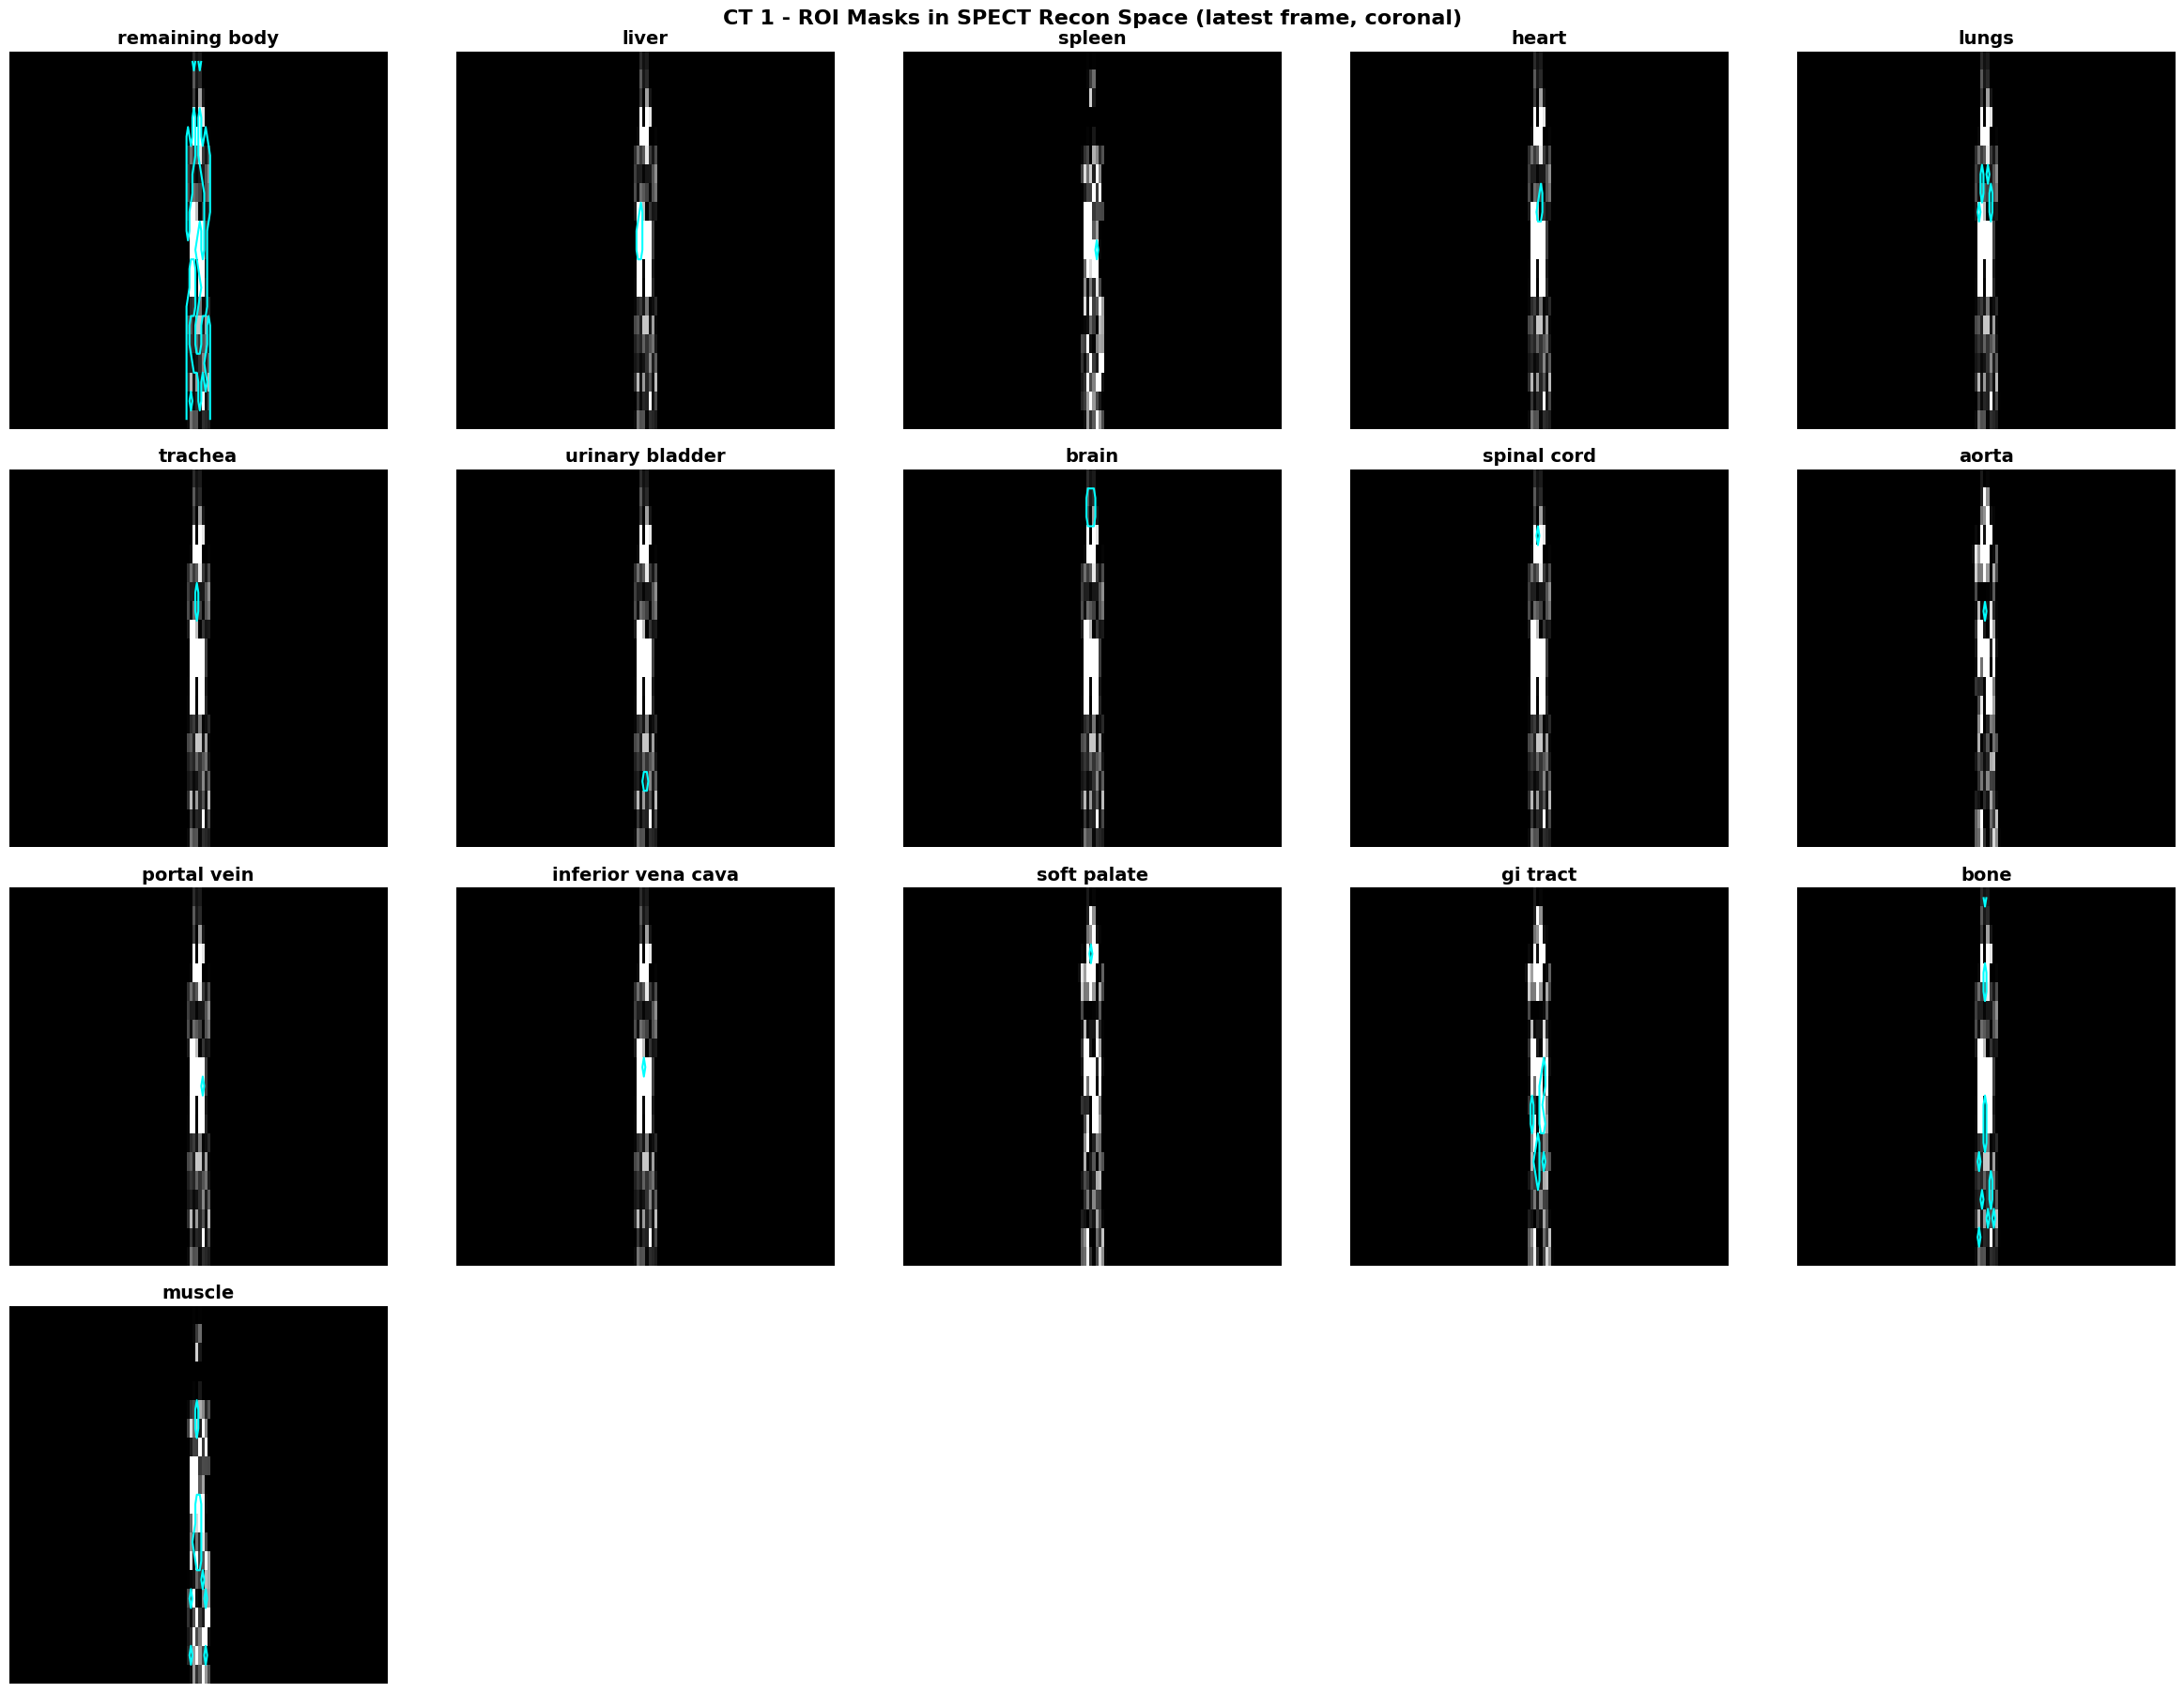

In [48]:
for i in masks_recon:
    arr_ref, sp = recon_arr_ref[i]
    rois = [r for r in masks_recon[i] if r not in ('background',)]
    if not rois:
        print(f'CT {i+1}: no masks available for overlay')
        continue

    fig, axes, nrows, ncols = make_grid(len(rois), max_cols=5, panel_w=4.8, panel_h=4.6)
    fig.suptitle(f'CT {i+1} - ROI Masks in SPECT Recon Space (latest frame, coronal)')
    image_cmap = plot_spec('mask', 'image_cmap', 'gray')
    contour_color = plot_spec('mask', 'contour_color', 'cyan')

    for j, roi in enumerate(rois):
        ax = axes[j // ncols][j % ncols]
        mask = masks_recon[i][roi][::-1]  # display orientation to match arr_ref
        pts = np.argwhere(mask)
        if pts.size == 0:
            ax.set_visible(False)
            continue
        y_sl = int(np.round(pts[:, 1].mean()))
        sl_recon = arr_ref[:, y_sl, :]
        sl_mask = mask[:, y_sl, :]
        pos = sl_recon[np.isfinite(sl_recon)]
        vmax_r = float(np.percentile(pos, 99)) if pos.size else None

        plot_image(ax, sl_recon, sp=sp, view='coronal', cmap=image_cmap, title=roi.replace('_', ' '), vmin=0, vmax=vmax_r)
        ax.contour(sl_mask.astype(np.uint8), levels=[0.5], colors=contour_color, linewidths=1.5)

    for j in range(len(rois), nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    finish_plot(fig, f'ct_{i+1}_mask_overlay')


### 8c - Extract SPECT TACs

Expected output: one text line per patient listing extracted frames and ROIs. Totals are computed as `sum(MBq/mL) * voxel_mL`, so the spacing unit matters.


In [49]:
def roi_stats(arr_zyx, mask_zyx, vox_vol_ml):
    n = int(mask_zyx.sum())
    if n == 0:
        return 0.0, 0.0, 0
    mean_mbq_ml = float(np.mean(arr_zyx[mask_zyx]))
    total_mbq = float(np.sum(arr_zyx[mask_zyx]) * vox_vol_ml)
    return mean_mbq_ml, total_mbq, n


spect_tacs = {}   # {i: {roi: {'frame_hr':[], 'sum_mbq':[], 'mean_mbq_ml':[]}}}

for i in masks_recon:
    frame_map = recon_imgs_sitk[i]
    frame_labels = sorted(frame_map.keys(), key=lambda k: float(k))
    rois = [r for r in masks_recon[i] if r not in ('background',)]
    vox_ml = recon_vox_ml[i]

    spect_tacs[i] = {roi: {'frame_hr': [], 'sum_mbq': [], 'mean_mbq_ml': [], 'n_voxels': []} for roi in rois}

    for lbl in frame_labels:
        arr = sitk.GetArrayFromImage(frame_map[lbl]).astype(np.float32)  # z,y,x, not display-flipped
        for roi in rois:
            mask = masks_recon[i][roi]
            if arr.shape != mask.shape:
                print(f'CT {i+1} {roi}: shape mismatch arr={arr.shape} mask={mask.shape}')
                continue
            mean_c, total, n_vox = roi_stats(arr, mask, vox_ml)
            spect_tacs[i][roi]['frame_hr'].append(float(lbl))
            spect_tacs[i][roi]['sum_mbq'].append(total)
            spect_tacs[i][roi]['mean_mbq_ml'].append(mean_c)
            spect_tacs[i][roi]['n_voxels'].append(n_vox)

    print(f"CT {i+1}: SPECT TAC extracted for frames {frame_labels} hr, ROIs={rois}")


CT 1: SPECT TAC extracted for frames ['1', '2', '3', '8', '12', '24', '48', '72', '96', '120', '144', '168'] hr, ROIs=['remaining_body', 'liver', 'spleen', 'heart', 'lungs', 'trachea', 'urinary_bladder', 'brain', 'spinal_cord', 'aorta', 'portal_vein', 'inferior_vena_cava', 'soft_palate', 'gi_tract', 'bone', 'muscle']


## 9 - Comparison 1: PBPK vs Reconstructed SPECT TACs

Expected output: TAC overlays, difference/error bars, and a numeric table. By default, comparison is restricted to simulated source ROIs and excludes remaining_body to avoid misleading organ comparisons from spill-in/background activity.


CT 1: comparison skipped ROIs=['aorta', 'bone', 'brain', 'gi_tract', 'heart', 'inferior_vena_cava', 'muscle', 'portal_vein', 'remaining_body', 'soft_palate', 'spinal_cord', 'spleen', 'trachea', 'urinary_bladder']


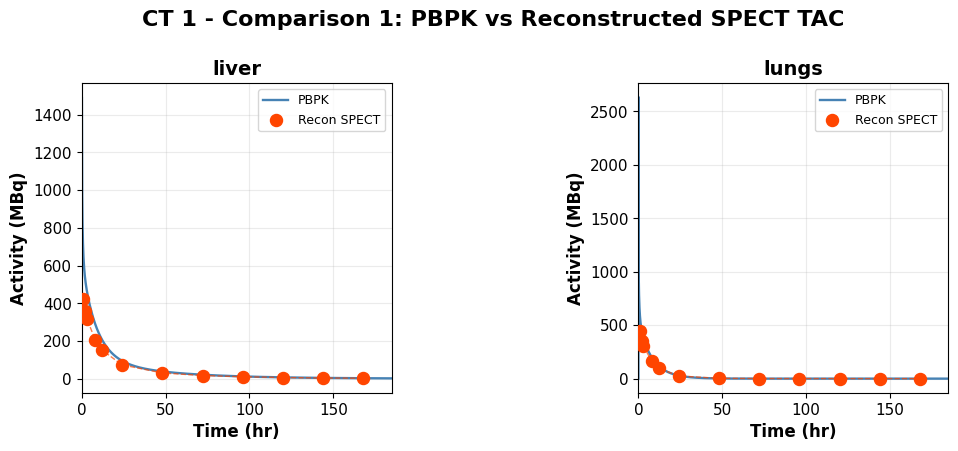

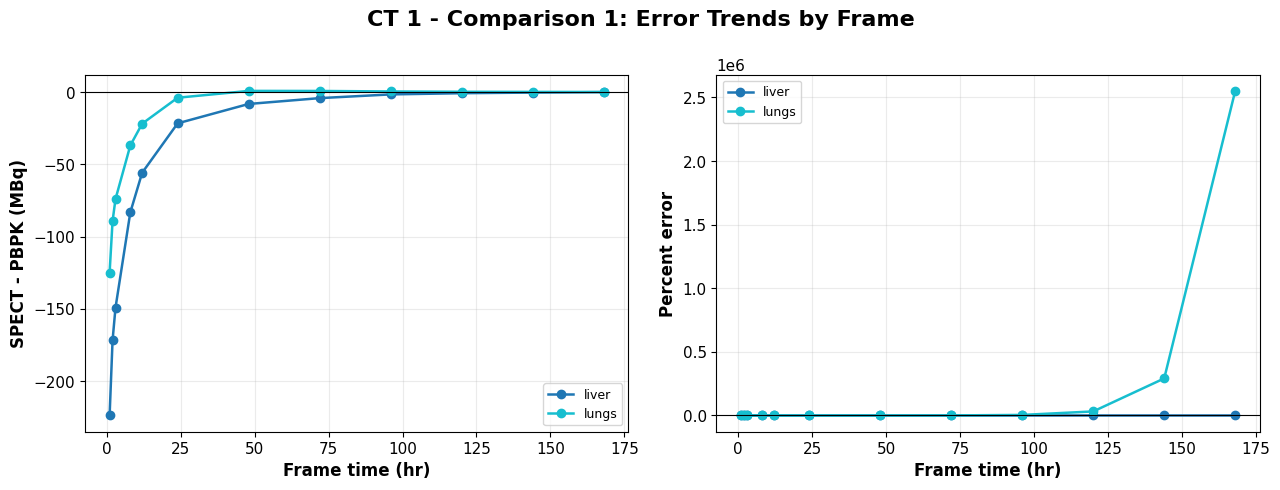


CT 1 - Comparison 1 table
  ROI                     frame         PBPK        SPECT        delta    pct_err
  liver                   1.00h      648.410      424.531     -223.878      -34.5%
  liver                   2.00h      530.048      358.314     -171.734      -32.4%
  liver                   3.00h      467.561      318.420     -149.141      -31.9%
  liver                   8.00h      289.731      206.526      -83.206      -28.7%
  liver                  12.00h      207.790      151.990      -55.799      -26.9%
  liver                  24.00h       94.819       73.225      -21.594      -22.8%
  liver                  48.00h       38.249       30.072       -8.178      -21.4%
  liver                  72.00h       20.730       16.591       -4.139      -20.0%
  liver                  96.00h       11.744       10.180       -1.564      -13.3%
  liver                 120.00h        6.692        5.963       -0.729      -10.9%
  liver                 144.00h        3.816        3.518    

In [50]:
def simulated_rois_for_patient(i):
    rois = set()
    meta = simind_meta_store.get(i, {})
    rois.update(str(r).lower() for r in meta.get('roi_list', []) if r)
    if not rois:
        cfg_rois = configs.get(i, {}).get('phase_2', {}).get('simind_stage', {}).get('roi_subset', [])
        rois.update(str(r).lower() for r in cfg_rois if r)
    if not INCLUDE_REMAINING_BODY_IN_COMPARISON:
        rois.discard('remaining_body')
    return rois


def comparison_rois_for_patient(i, available_rois):
    candidates = []
    simulated = simulated_rois_for_patient(i) if COMPARE_ONLY_SIMULATED_ROIS else None
    for roi in available_rois:
        key = roi.lower()
        if key in SKIP_ROIS_COMPARISON:
            continue
        if not INCLUDE_REMAINING_BODY_IN_COMPARISON and key == 'remaining_body':
            continue
        if simulated is not None and simulated and key not in simulated:
            continue
        candidates.append(roi)
    return sorted(candidates)


def array_after_frame_filter(t, *ys):
    t = np.asarray(t, dtype=float)
    ys = [np.asarray(y, dtype=float) for y in ys]
    order = np.argsort(t)
    t = t[order]
    ys = [y[order] for y in ys]
    if SKIP_LAST_FRAME and len(t) > 1:
        t = t[:-1]
        ys = [y[:-1] for y in ys]
    return (t, *ys)


diff_store = {}

for i in spect_tacs:
    if i not in pbpk_store:
        print(f'CT {i+1}: no PBPK data for comparison')
        continue
    diff_store[i] = {}
    pbpk_t = pbpk_store[i]['time_hr']
    available = [r for r in spect_tacs[i] if spect_tacs[i][r]['sum_mbq']]
    plot_rois = comparison_rois_for_patient(i, available)

    skipped = sorted(set(available) - set(plot_rois))
    if skipped:
        print(f'CT {i+1}: comparison skipped ROIs={skipped}')
    if not plot_rois:
        print(f'CT {i+1}: no ROIs available after comparison filters')
        continue

    for roi in plot_rois:
        pbpk_key = roi.lower()
        if pbpk_key not in pbpk_store[i]:
            print(f'CT {i+1}: PBPK missing ROI {roi}')
            continue
        t_hr = np.array(spect_tacs[i][roi]['frame_hr'])
        y_s = np.array(spect_tacs[i][roi]['sum_mbq'])
        y_p = np.interp(t_hr, pbpk_t, pbpk_store[i][pbpk_key])
        t_hr, y_s, y_p = array_after_frame_filter(t_hr, y_s, y_p)
        diff_store[i][roi] = {
            'frame_hr': t_hr,
            'diff_mbq': y_s - y_p,
            'pct_err': pct(y_s, y_p),
            'y_spect': y_s,
            'y_pbpk': y_p,
        }

for i, diffs in diff_store.items():
    plot_rois = list(diffs)
    if not plot_rois:
        continue
    pbpk_t = pbpk_store[i]['time_hr']
    all_frames = np.concatenate([diffs[r]['frame_hr'] for r in plot_rois if len(diffs[r]['frame_hr'])])
    xlim = comparison_xlim(all_frames)

    fig, axes, nrows, ncols = make_grid(len(plot_rois), max_cols=4, panel_w=5.8, panel_h=4.6)
    fig.suptitle(f'CT {i+1} - Comparison 1: PBPK vs Reconstructed SPECT TAC')
    pbpk_color = plot_spec('comparison', 'pbpk_color', 'steelblue')
    spect_color = plot_spec('comparison', 'spect_color', 'orangered')

    for j, roi in enumerate(plot_rois):
        ax = axes[j // ncols][j % ncols]
        d = diffs[roi]
        ax.plot(pbpk_t, pbpk_store[i][roi.lower()], lw=1.7, color=pbpk_color, label='PBPK')
        ax.scatter(d['frame_hr'], d['y_spect'], s=75, color=spect_color, zorder=5, label='Recon SPECT')
        ax.plot(d['frame_hr'], d['y_spect'], '--', color=spect_color, lw=1, alpha=0.7)
        if xlim:
            ax.set_xlim(*xlim)
        ax.set_title(roi.replace('_', ' '))
        ax.set_xlabel('Time (hr)')
        ax.set_ylabel('Activity (MBq)')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.25)
        if FORCE_SQUARE_PANELS:
            ax.set_box_aspect(1)

    for j in range(len(plot_rois), nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    finish_plot(fig, f'ct_{i+1}_comparison1_tac_overlay')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'CT {i+1} - Comparison 1: Error Trends by Frame')
    colors = plt.cm.tab10(np.linspace(0, 1, len(plot_rois)))
    for roi, col in zip(plot_rois, colors):
        d = diffs[roi]
        label = roi.replace('_', ' ')
        axes[0].plot(d['frame_hr'], d['diff_mbq'], marker='o', lw=1.8, color=col, label=label)
        axes[1].plot(d['frame_hr'], d['pct_err'], marker='o', lw=1.8, color=col, label=label)

    for ax, ylabel in zip(axes, ['SPECT - PBPK (MBq)', 'Percent error']):
        ax.axhline(0, color='k', lw=0.8)
        ax.set_xlabel('Frame time (hr)')
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=9)
    finish_plot(fig, f'ct_{i+1}_comparison1_error_trends')

    print(f"\nCT {i+1} - Comparison 1 table")
    print(f"  {'ROI':20s} {'frame':>8s} {'PBPK':>12s} {'SPECT':>12s} {'delta':>12s} {'pct_err':>10s}")
    for roi in plot_rois:
        d = diffs[roi]
        for f_idx in range(len(d['frame_hr'])):
            print(f"  {roi:20s} {d['frame_hr'][f_idx]:7.2f}h "
                  f"{d['y_pbpk'][f_idx]:12.3f} {d['y_spect'][f_idx]:12.3f} "
                  f"{d['diff_mbq'][f_idx]:+12.3f} {d['pct_err'][f_idx]:+10.1f}%")

### 9b - Comparison 1 Average Across Patients

Expected output: mean +/- std difference and percent-error plots across all available patients. The overview overlays ROIs, and each ROI also gets its own two-panel mean/std plot. Missing ROI/frame combinations are retained as NaN instead of forcing only common data.


In [51]:
def nanmean_std_count(values, axis=0):
    arr = np.asarray(values, dtype=float)
    finite = np.isfinite(arr)
    count = np.sum(finite, axis=axis)
    summed = np.sum(np.where(finite, arr, 0.0), axis=axis)
    mean = np.divide(
        summed,
        count,
        out=np.full(np.shape(summed), np.nan, dtype=float),
        where=count > 0,
    )

    if axis == 0:
        centered = arr - mean
    elif axis == 1:
        centered = arr - mean[:, None]
    else:
        centered = arr - np.expand_dims(mean, axis=axis)

    ss = np.sum(np.where(finite, centered ** 2, 0.0), axis=axis)
    std = np.sqrt(np.divide(
        ss,
        count,
        out=np.full(np.shape(ss), np.nan, dtype=float),
        where=count > 0,
    ))
    return mean, std, count


def plot_mean_std_series(ax, x, mean, std, *, label=None, color=None, marker='o', lw=2.0):
    x = np.asarray(x, dtype=float)
    mean = np.asarray(mean, dtype=float)
    std = np.asarray(std, dtype=float)
    mask = np.isfinite(x) & np.isfinite(mean)
    if not np.any(mask):
        return None

    x_plot = x[mask]
    y_plot = mean[mask]
    s_plot = np.where(np.isfinite(std[mask]), std[mask], 0.0)

    if x_plot.size == 1:
        return ax.errorbar(
            x_plot,
            y_plot,
            yerr=s_plot,
            fmt=marker,
            ms=7,
            capsize=4,
            color=color,
            label=label,
        )

    (line,) = ax.plot(x_plot, y_plot, marker=marker, lw=lw, color=color, label=label)
    band_color = color if color is not None else line.get_color()
    ax.fill_between(x_plot, y_plot - s_plot, y_plot + s_plot, color=band_color, alpha=0.18, linewidth=0)
    return line


def fmt_num(value, width=12, precision=3):
    return f'{value:{width}.{precision}f}' if np.isfinite(value) else f"{'n/a':>{width}s}"


def fmt_pct(value, width=10, precision=1):
    return f'{value:+{width}.{precision}f}%' if np.isfinite(value) else f"{'n/a':>{width}s}"


def fmt_mean_std(mean, std, width=20, precision=3):
    if not np.isfinite(mean):
        return f"{'n/a':>{width}s}"
    std_txt = f'{std:.{precision}f}' if np.isfinite(std) else 'n/a'
    txt = f'{mean:.{precision}f}+/-{std_txt}'
    return f'{txt:>{width}s}'


comparison1_summary_store = {}

if len(diff_store) > 1:
    all_rois = sorted(set().union(*[set(d.keys()) for d in diff_store.values() if d]))
    all_frames = sorted(set(float(f) for d in diff_store.values() for r in d.values() for f in r['frame_hr']))
    patient_idxs = sorted(diff_store.keys())

    if not all_rois or not all_frames:
        print('No comparable ROI/frame data available for cross-patient averaging')
    else:
        frame_arr = np.asarray(all_frames, dtype=float)
        for roi in all_rois:
            diff_stack = np.full((len(patient_idxs), len(all_frames)), np.nan, dtype=float)
            err_stack = np.full((len(patient_idxs), len(all_frames)), np.nan, dtype=float)

            for row_idx, patient_idx in enumerate(patient_idxs):
                patient_diffs = diff_store.get(patient_idx, {})
                if roi not in patient_diffs:
                    continue
                d = patient_diffs[roi]
                patient_frames = np.asarray(d['frame_hr'], dtype=float)
                for col_idx, frame in enumerate(all_frames):
                    matches = np.where(np.isclose(patient_frames, frame, atol=1e-6))[0]
                    if matches.size:
                        src_idx = matches[0]
                        diff_stack[row_idx, col_idx] = d['diff_mbq'][src_idx]
                        err_stack[row_idx, col_idx] = d['pct_err'][src_idx]

            mean_diff, std_diff, n_diff = nanmean_std_count(diff_stack, axis=0)
            mean_err, std_err, n_err = nanmean_std_count(err_stack, axis=0)
            comparison1_summary_store[roi] = {
                'frame_hr': frame_arr,
                'mean_diff_mbq': mean_diff,
                'std_diff_mbq': std_diff,
                'n_diff': n_diff,
                'mean_pct_err': mean_err,
                'std_pct_err': std_err,
                'n_pct_err': n_err,
            }

        colors = plt.get_cmap(plot_spec('comparison', 'summary_cmap', 'tab10'))(np.linspace(0, 1, len(all_rois)))
        fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True)
        fig.suptitle(f'Comparison 1 - Mean +/- Std Across {len(patient_idxs)} Patients')
        for roi, col in zip(all_rois, colors):
            s = comparison1_summary_store[roi]
            plot_mean_std_series(axes[0], s['frame_hr'], s['mean_diff_mbq'], s['std_diff_mbq'], color=col, label=roi.replace('_', ' '))
            plot_mean_std_series(axes[1], s['frame_hr'], s['mean_pct_err'], s['std_pct_err'], color=col, label=roi.replace('_', ' '))

        for ax, ylabel, title in zip(
            axes,
            ['SPECT - PBPK (MBq)', 'Percent error (%)'],
            ['Absolute Difference', 'Percent Error'],
        ):
            ax.axhline(0, color='k', lw=0.8)
            ax.set_xlabel('Frame time (hr)')
            ax.set_ylabel(ylabel)
            ax.set_title(title)
            ax.grid(True, alpha=0.25)
            ax.legend(fontsize=9)
        finish_plot(fig, 'comparison1_average_error_trends')

        for roi, col in zip(all_rois, colors):
            s = comparison1_summary_store[roi]
            fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharex=True)
            fig.suptitle(f"Average Across Patients - {roi.replace('_', ' ')}")
            plot_mean_std_series(axes[0], s['frame_hr'], s['mean_diff_mbq'], s['std_diff_mbq'], color=col)
            plot_mean_std_series(axes[1], s['frame_hr'], s['mean_pct_err'], s['std_pct_err'], color=col)

            axes[0].set_title('Difference (MBq)')
            axes[0].set_ylabel('MBq')
            axes[1].set_title('Percent Error (%)')
            axes[1].set_ylabel('%')
            for ax in axes:
                ax.axhline(0, color='k', lw=0.8)
                ax.set_xlabel('Time (hr)')
                ax.grid(True, alpha=0.25)
            finish_plot(fig, f'comparison1_average_{safe_name(roi)}')

        print('\nComparison 1 mean +/- std across patients')
        print(f"  {'ROI':20s} {'frame':>8s} {'diff_mean':>12s} {'diff_std':>12s} {'err_mean':>12s} {'err_std':>12s} {'n':>4s}")
        for roi in all_rois:
            s = comparison1_summary_store[roi]
            for k, frame in enumerate(s['frame_hr']):
                n_here = int(s['n_diff'][k])
                print(f"  {roi:20s} {frame:7.2f}h {s['mean_diff_mbq'][k]:12.3f} {s['std_diff_mbq'][k]:12.3f} "
                      f"{s['mean_pct_err'][k]:12.2f} {s['std_pct_err'][k]:12.2f} {n_here:4d}")
else:
    print('Only 1 patient - cross-patient average skipped')


Only 1 patient - cross-patient average skipped


## 10 - Comparison 2: Bi-exponential Kinetics

Expected output: PBPK and SPECT bi-exponential fits for comparable ROIs when enough SPECT frames exist. A SPECT bi-exponential fit has three free parameters and requires at least 3 finite SPECT time points; with fewer frames this section still plots the PBPK curve/SPECT samples and prints why kinetic parameters are skipped.


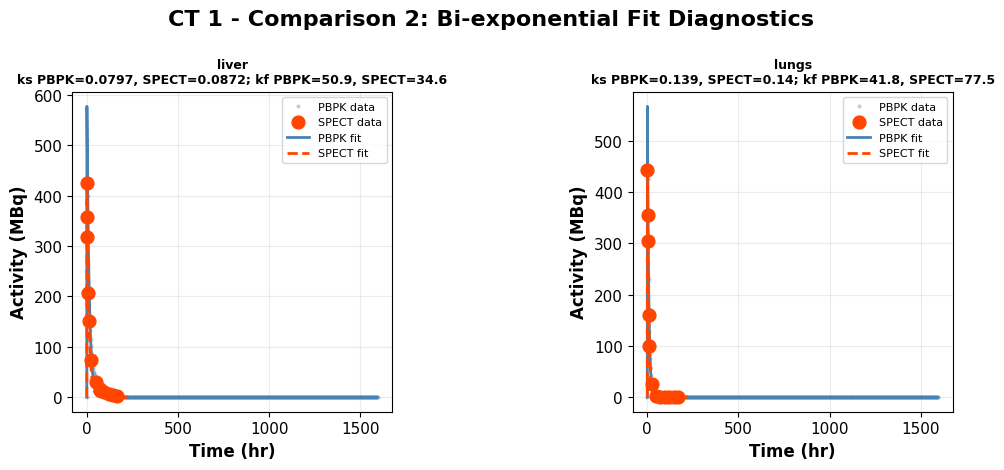


CT 1 - Comparison 2 fit diagnostics table
  ROI                   PBPK_fit  SPECT_n  SPECT_fit       PBPK_A    PBPK_ks    PBPK_kf      SPECT_A   SPECT_ks   SPECT_kf                   reason
  liver                     True       12       True      603.340     0.0797    50.8655      436.062     0.0872    34.5872                        -
  lungs                     True       12       True      612.505     0.1387    41.7750      487.526     0.1402    77.5253                        -

CT 1 - Kinetic Parameter Comparison
  ROI                   k_slow_PBPK  k_slow_SPECT       pct  k_fast_PBPK  k_fast_SPECT       pct
  liver                      0.0797        0.0872      +9.4%      50.8655       34.5872     -32.0%
  lungs                      0.1387        0.1402      +1.1%      41.7750       77.5253     +85.6%


In [52]:
def biexp(t, A, k_slow, delta):
    return A * (np.exp(-k_slow * t) - np.exp(-(k_slow + delta) * t))


def downsample_xy(t, y, max_points):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    if t.size <= max_points:
        return t, y
    idx = np.unique(np.linspace(0, t.size - 1, max_points).astype(int))
    return t[idx], y[idx]


def fit_biexp(t, y):
    t, y = np.asarray(t, float), np.asarray(y, float)
    mask = np.isfinite(t) & np.isfinite(y) & (y >= 0)
    t, y = t[mask], y[mask]
    if t.size < 3:
        raise ValueError(f'Need at least 3 points, got {t.size}')
    p0 = [max(float(np.max(y)) * 2.0, 1e-6), 0.05, 1.0]
    bounds = ([0, 0, 0], [np.inf, np.inf, np.inf])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', OptimizeWarning)
        popt, _ = curve_fit(biexp, t, y, p0=p0, bounds=bounds, maxfev=50000)
    return popt


fit_store = {}
fit_skip_store = {}

for i in spect_tacs:
    if i not in pbpk_store:
        continue
    fit_store[i] = {}
    fit_skip_store[i] = {}
    pbpk_t = pbpk_store[i]['time_hr']
    available = [r for r in spect_tacs[i] if r.lower() in pbpk_store[i] and len(spect_tacs[i][r]['sum_mbq']) > 0]
    plot_rois = comparison_rois_for_patient(i, available)

    if not plot_rois:
        print(f'CT {i+1}: no comparable ROIs for bi-exp fit')
        continue

    fig, axes, nrows, ncols = make_grid(len(plot_rois), max_cols=4, panel_w=5.8, panel_h=4.8)
    fig.suptitle(f'CT {i+1} - Comparison 2: Bi-exponential Fit Diagnostics')
    pbpk_color = plot_spec('comparison', 'pbpk_color', 'steelblue')
    spect_color = plot_spec('comparison', 'spect_color', 'orangered')

    fit_diag_rows = []

    for j, roi in enumerate(plot_rois):
        ax = axes[j // ncols][j % ncols]
        y_pbpk = pbpk_store[i][roi.lower()]
        t_fit_p, y_fit_p = downsample_xy(pbpk_t, y_pbpk, FIT_MAX_PBPK_POINTS)

        popt_p = popt_s = None
        try:
            popt_p = fit_biexp(t_fit_p, y_fit_p)
            t_plot_p, y_plot_p = downsample_xy(pbpk_t, y_pbpk, 700)
            ax.plot(t_plot_p, y_plot_p, 'o', ms=2, color=pbpk_color, alpha=0.28, label='PBPK data')
        except Exception as e:
            fit_skip_store[i].setdefault(roi, {})['pbpk'] = str(e)
            print(f'  CT {i+1} {roi} PBPK fit failed: {e}')

        t_s = np.array(spect_tacs[i][roi]['frame_hr'])
        y_s = np.array(spect_tacs[i][roi]['sum_mbq'])
        t_s, y_s = array_after_frame_filter(t_s, y_s)
        ax.scatter(t_s, y_s, s=85, color=spect_color, zorder=5, label='SPECT data')

        try:
            popt_s = fit_biexp(t_s, y_s)
        except Exception as e:
            fit_skip_store[i].setdefault(roi, {})['spect'] = str(e)
            print(f'  CT {i+1} {roi} SPECT fit skipped: {e}. Difference plots and trapezoid AUC still work.')

        plot_end_candidates = [1.0]
        if len(t_s):
            plot_end_candidates.append(float(np.max(t_s)) * 1.10)
        if popt_p is not None:
            finite_pbpk_t = np.asarray(pbpk_t, dtype=float)
            finite_pbpk_t = finite_pbpk_t[np.isfinite(finite_pbpk_t)]
            if finite_pbpk_t.size:
                plot_end_candidates.append(min(float(finite_pbpk_t.max()), max(plot_end_candidates) * 1.20))
        plot_end = max(plot_end_candidates)
        t_grid = np.linspace(0, plot_end, 400)

        if popt_p is not None:
            ax.plot(t_grid, biexp(t_grid, *popt_p), lw=2, color=pbpk_color, label='PBPK fit')
        if popt_s is not None:
            ax.plot(t_grid, biexp(t_grid, *popt_s), '--', lw=2, color=spect_color, label='SPECT fit')

        if popt_p is not None and popt_s is not None:
            fit_store[i][roi] = {'pbpk': popt_p, 'spect': popt_s}
            kf_p = popt_p[1] + popt_p[2]
            kf_s = popt_s[1] + popt_s[2]
            ax.set_title(f"{roi.replace('_', ' ')}\nks PBPK={popt_p[1]:.3g}, SPECT={popt_s[1]:.3g}; "
                         f"kf PBPK={kf_p:.3g}, SPECT={kf_s:.3g}", fontsize=9)
        else:
            reason = fit_skip_store[i].get(roi, {}).get('spect', 'fit unavailable')
            ax.set_title(f"{roi.replace('_', ' ')}\nSPECT fit unavailable ({reason})", fontsize=9)

        spect_reason = fit_skip_store[i].get(roi, {}).get('spect', '')
        pbpk_reason = fit_skip_store[i].get(roi, {}).get('pbpk', '')
        fit_diag_rows.append({
            'roi': roi,
            'pbpk_ok': popt_p is not None,
            'spect_ok': popt_s is not None,
            'spect_points': int(len(t_s)),
            'pbpk_A': float(popt_p[0]) if popt_p is not None else np.nan,
            'pbpk_k_slow': float(popt_p[1]) if popt_p is not None else np.nan,
            'pbpk_k_fast': float(popt_p[1] + popt_p[2]) if popt_p is not None else np.nan,
            'spect_A': float(popt_s[0]) if popt_s is not None else np.nan,
            'spect_k_slow': float(popt_s[1]) if popt_s is not None else np.nan,
            'spect_k_fast': float(popt_s[1] + popt_s[2]) if popt_s is not None else np.nan,
            'reason': spect_reason or pbpk_reason or '-',
        })

        ax.set_xlabel('Time (hr)')
        ax.set_ylabel('Activity (MBq)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.25)
        if FORCE_SQUARE_PANELS:
            ax.set_box_aspect(1)

    for j in range(len(plot_rois), nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    finish_plot(fig, f'ct_{i+1}_comparison2_biexp_fit')

    print(f"\nCT {i+1} - Comparison 2 fit diagnostics table")
    print(f"  {'ROI':20s} {'PBPK_fit':>9s} {'SPECT_n':>8s} {'SPECT_fit':>10s} "
          f"{'PBPK_A':>12s} {'PBPK_ks':>10s} {'PBPK_kf':>10s} "
          f"{'SPECT_A':>12s} {'SPECT_ks':>10s} {'SPECT_kf':>10s} {'reason':>24s}")
    for row in fit_diag_rows:
        reason = str(row['reason'])[:24]
        print(f"  {row['roi']:20s} {str(row['pbpk_ok']):>9s} {row['spect_points']:8d} {str(row['spect_ok']):>10s} "
              f"{fmt_num(row['pbpk_A'])} {fmt_num(row['pbpk_k_slow'], width=10, precision=4)} {fmt_num(row['pbpk_k_fast'], width=10, precision=4)} "
              f"{fmt_num(row['spect_A'])} {fmt_num(row['spect_k_slow'], width=10, precision=4)} {fmt_num(row['spect_k_fast'], width=10, precision=4)} {reason:>24s}")

    if fit_store.get(i):
        print(f"\nCT {i+1} - Kinetic Parameter Comparison")
        print(f"  {'ROI':20s} {'k_slow_PBPK':>12s} {'k_slow_SPECT':>13s} {'pct':>9s} "
              f"{'k_fast_PBPK':>12s} {'k_fast_SPECT':>13s} {'pct':>9s}")
        for roi, fits in fit_store.get(i, {}).items():
            pp, ps = fits['pbpk'], fits['spect']
            ks_p, ks_s = pp[1], ps[1]
            kf_p, kf_s = pp[1] + pp[2], ps[1] + ps[2]
            print(f"  {roi:20s} {ks_p:12.4f} {ks_s:13.4f} {pct(ks_s, ks_p):+9.1f}% "
                  f"{kf_p:12.4f} {kf_s:13.4f} {pct(kf_s, kf_p):+9.1f}%")
    else:
        print(f'CT {i+1}: no SPECT kinetic parameters fitted. Need at least 3 SPECT frames per ROI; found fewer after filters.')


### 10b - Average Kinetic Parameters Across Patients

Expected output: cross-patient kinetic summary. Missing ROIs are handled as NaN instead of forcing an intersection-only view.


In [53]:
if len(fit_store) > 1:
    all_rois = sorted(set().union(*[set(v.keys()) for v in fit_store.values() if v]))
    if not all_rois:
        print('No fitted ROIs available for cross-patient kinetic summary. SPECT kinetic fits require at least 3 frames per ROI.')
    else:
        param_defs = [('k_slow', lambda p: p[1]), ('k_fast', lambda p: p[1] + p[2])]
        fig, axes = plt.subplots(len(param_defs), 2, figsize=(14, 4.4 * len(param_defs)), squeeze=False)
        fig.suptitle(f'Comparison 2 - Kinetic Parameters Across {len(fit_store)} Patients')
        x = np.arange(len(all_rois))

        for row, (pname, getter) in enumerate(param_defs):
            means_p, means_s, stds_p, stds_s, pcts, pct_sd = [], [], [], [], [], []
            for roi in all_rois:
                vals_p, vals_s, vals_pct = [], [], []
                for i, fits in fit_store.items():
                    if roi not in fits:
                        vals_p.append(np.nan); vals_s.append(np.nan); vals_pct.append(np.nan); continue
                    vp = getter(fits[roi]['pbpk'])
                    vs = getter(fits[roi]['spect'])
                    vals_p.append(vp); vals_s.append(vs); vals_pct.append(pct(vs, vp))
                mp, sp, _ = nanmean_std_count(np.asarray(vals_p)[:, None], axis=0)
                ms, ss, _ = nanmean_std_count(np.asarray(vals_s)[:, None], axis=0)
                me, se, _ = nanmean_std_count(np.asarray(vals_pct)[:, None], axis=0)
                means_p.append(mp[0]); stds_p.append(sp[0])
                means_s.append(ms[0]); stds_s.append(ss[0])
                pcts.append(me[0]); pct_sd.append(se[0])

            ax = axes[row][0]
            for xi, vp, vs in zip(x, means_p, means_s):
                if np.isfinite(vp) and np.isfinite(vs):
                    ax.plot([xi - 0.12, xi + 0.12], [vp, vs], color='0.55', lw=1.5, alpha=0.8)
            ax.errorbar(x - 0.12, means_p, yerr=stds_p, fmt='o', color='steelblue', capsize=4, label='PBPK')
            ax.errorbar(x + 0.12, means_s, yerr=stds_s, fmt='o', color='orangered', capsize=4, label='SPECT')
            ax.set_xticks(x); ax.set_xticklabels([r.replace('_',' ') for r in all_rois], rotation=30, ha='right')
            ax.set_ylabel(f'{pname} (1/hr)'); ax.set_title(f'{pname} mean +/- std'); ax.legend(); ax.grid(True, axis='y', alpha=0.25)

            ax2 = axes[row][1]
            ax2.errorbar(x, pcts, yerr=pct_sd, fmt='o', color='purple', capsize=4)
            ax2.axhline(0, color='k', lw=0.8)
            ax2.set_xticks(x); ax2.set_xticklabels([r.replace('_',' ') for r in all_rois], rotation=30, ha='right')
            ax2.set_ylabel('Percent error (SPECT vs PBPK)'); ax2.set_title(f'{pname} mean percent error'); ax2.grid(True, axis='y', alpha=0.25)
        finish_plot(fig, 'comparison2_average_kinetics')

        print('\nComparison 2 kinetic mean +/- std across patients')
        print(f"  {'param':10s} {'ROI':20s} {'PBPK':>20s} {'SPECT':>20s} {'pct_err':>18s} {'n':>4s}")
        for pname, getter in param_defs:
            for roi in all_rois:
                vals_p, vals_s, vals_pct = [], [], []
                for i, fits in fit_store.items():
                    if roi not in fits:
                        vals_p.append(np.nan); vals_s.append(np.nan); vals_pct.append(np.nan); continue
                    vp = getter(fits[roi]['pbpk'])
                    vs = getter(fits[roi]['spect'])
                    vals_p.append(vp); vals_s.append(vs); vals_pct.append(pct(vs, vp))
                mp, sp, cp = nanmean_std_count(np.asarray(vals_p, dtype=float)[:, None], axis=0)
                ms, ss, cs = nanmean_std_count(np.asarray(vals_s, dtype=float)[:, None], axis=0)
                me, se, ce = nanmean_std_count(np.asarray(vals_pct, dtype=float)[:, None], axis=0)
                n_here = int(min(cp[0], cs[0], ce[0]))
                print(f"  {pname:10s} {roi:20s} {fmt_mean_std(mp[0], sp[0])} {fmt_mean_std(ms[0], ss[0])} "
                      f"{fmt_mean_std(me[0], se[0], width=18, precision=2)} {n_here:4d}")
else:
    print('Only 1 patient - cross-patient kinetic comparison skipped')


Only 1 patient - cross-patient kinetic comparison skipped


## 11 - Comparison 3: AUC

Expected output: PBPK AUC compared with SPECT AUC. If a valid SPECT bi-exponential fit exists, its analytic fit AUC is shown; otherwise the notebook still reports direct trapezoid SPECT AUC from the available reconstructed SPECT samples. With one SPECT frame, the trapezoid estimate is the only valid SPECT AUC summary.


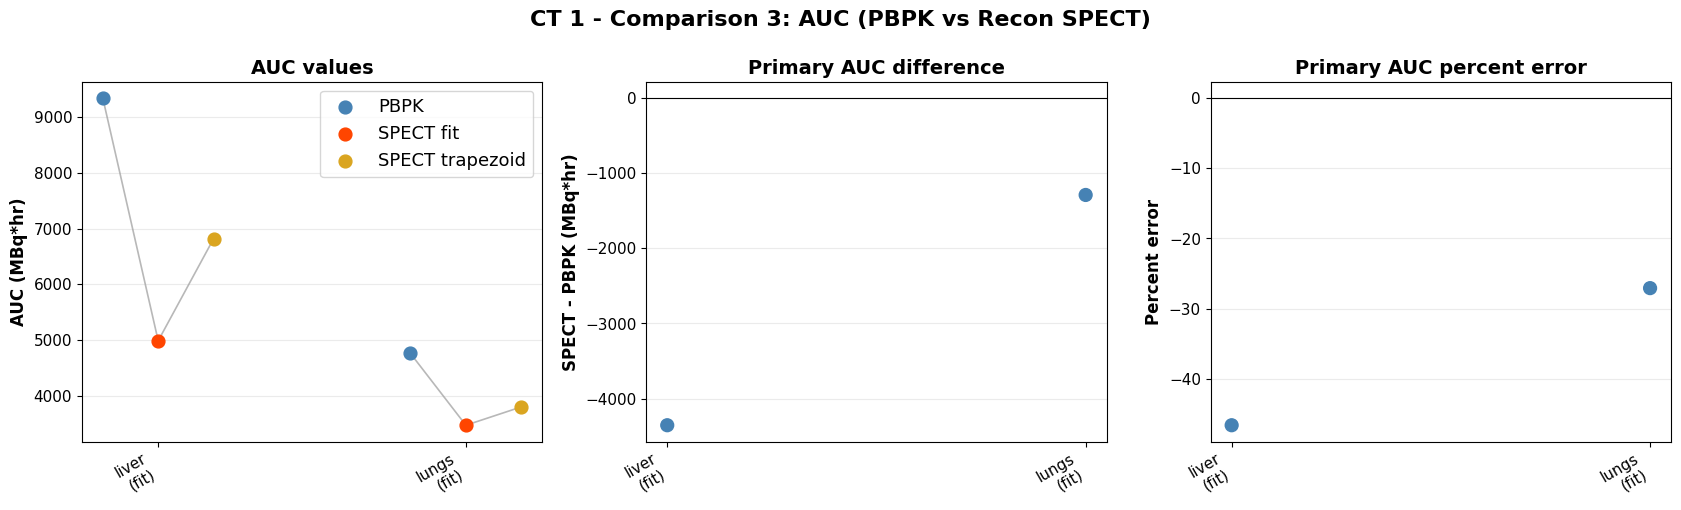


CT 1 - AUC table
  ROI                    n    t_end         PBPK    SPECT_fit   SPECT_trap    fit_pct   trap_pct
  liver                 12  168.00h     9342.972     4987.456     6819.691      -46.6%      -27.0%
  lungs                 12  168.00h     4760.262     3471.453     3800.212      -27.1%      -20.2%


In [54]:
def pbpk_auc(t_hr, y_mbq, t_end_hr):
    t, y = np.asarray(t_hr, float), np.asarray(y_mbq, float)
    mask = np.isfinite(t) & np.isfinite(y)
    t, y = t[mask], y[mask]
    order = np.argsort(t); t, y = t[order], y[order]
    if t.size == 0:
        return np.nan
    t_end_use = min(float(t_end_hr), float(t[-1]))
    keep = t <= t_end_use
    tu, yu = t[keep], y[keep]
    if tu.size == 0:
        return np.nan
    if tu[-1] < t_end_use:
        tu = np.append(tu, t_end_use)
        yu = np.append(yu, float(np.interp(t_end_use, t, y)))
    return float(np.trapezoid(yu, tu))


def spect_auc_analytic(popt, t_end_hr):
    A, ks, delta = [float(v) for v in popt]
    kf = ks + delta
    if not all(np.isfinite([A, ks, kf])) or ks <= 0 or kf <= 0:
        return np.nan
    T = float(t_end_hr)
    return A * ((1 - np.exp(-ks * T)) / ks - (1 - np.exp(-kf * T)) / kf)


def spect_auc_trapezoid(t_hr, y_mbq, t_end_hr):
    t, y = np.asarray(t_hr, float), np.asarray(y_mbq, float)
    t, y = array_after_frame_filter(t, y)
    mask = np.isfinite(t) & np.isfinite(y)
    t, y = t[mask], y[mask]
    order = np.argsort(t); t, y = t[order], y[order]
    if t.size == 0:
        return np.nan
    T = float(t_end_hr)
    keep = t <= T
    t, y = t[keep], y[keep]
    if t.size == 0:
        return np.nan
    if t[0] > 0:
        t = np.insert(t, 0, 0.0)
        y = np.insert(y, 0, 0.0)
    if t[-1] < T:
        y_end = float(np.interp(T, t, y)) if t.size >= 2 else float(y[-1])
        t = np.append(t, T)
        y = np.append(y, y_end)
    return float(np.trapezoid(y, t))


auc_store = {}

for i in spect_tacs:
    if i not in pbpk_store:
        continue
    auc_store[i] = {}
    pbpk_t = pbpk_store[i]['time_hr']
    available = [r for r in spect_tacs[i] if r.lower() in pbpk_store[i] and len(spect_tacs[i][r]['sum_mbq']) > 0]
    plot_rois = comparison_rois_for_patient(i, available)

    if not plot_rois:
        print(f'CT {i+1}: no comparable ROIs for AUC')
        continue

    for roi in plot_rois:
        t_s = np.array(spect_tacs[i][roi]['frame_hr'])
        y_s = np.array(spect_tacs[i][roi]['sum_mbq'])
        t_use, y_use = array_after_frame_filter(t_s, y_s)
        if len(t_use) == 0:
            continue
        t_end = float(t_use[-1])

        auc_p = pbpk_auc(pbpk_t, pbpk_store[i][roi.lower()], t_end)
        auc_s_trap = spect_auc_trapezoid(t_s, y_s, t_end)
        fits = fit_store.get(i, {}).get(roi)
        auc_s_fit = spect_auc_analytic(fits['spect'], t_end) if fits else np.nan
        primary = auc_s_fit if np.isfinite(auc_s_fit) else auc_s_trap
        primary_label = 'fit' if np.isfinite(auc_s_fit) else 'trapezoid'

        auc_store[i][roi] = {
            'pbpk_auc': auc_p,
            'spect_auc_fit': auc_s_fit,
            'spect_auc_trap': auc_s_trap,
            'spect_auc_primary': primary,
            'spect_auc_primary_label': primary_label,
            't_end_hr': t_end,
            'n_spect_points': int(len(t_use)),
        }

for i, aucs in auc_store.items():
    if not aucs:
        continue
    rois = list(aucs.keys())
    x = np.arange(len(rois))
    pbpk_vals = np.asarray([aucs[r]['pbpk_auc'] for r in rois], dtype=float)
    fit_vals = np.asarray([aucs[r]['spect_auc_fit'] for r in rois], dtype=float)
    trap_vals = np.asarray([aucs[r]['spect_auc_trap'] for r in rois], dtype=float)
    primary_vals = np.asarray([aucs[r]['spect_auc_primary'] for r in rois], dtype=float)
    primary_labels = [aucs[r]['spect_auc_primary_label'] for r in rois]

    fit_pct_vals = pct(fit_vals, pbpk_vals)
    trap_pct_vals = pct(trap_vals, pbpk_vals)
    primary_pct_vals = pct(primary_vals, pbpk_vals)

    fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
    fig.suptitle(f'CT {i+1} - Comparison 3: AUC (PBPK vs Recon SPECT)')

    axes[0].scatter(x - 0.18, pbpk_vals, s=85, color='steelblue', label='PBPK', zorder=4)
    if np.any(np.isfinite(fit_vals)):
        axes[0].scatter(x, fit_vals, s=85, color='orangered', label='SPECT fit', zorder=4)
    axes[0].scatter(x + 0.18, trap_vals, s=85, color='goldenrod', label='SPECT trapezoid', zorder=4)
    for xi, vp, vf, vt in zip(x, pbpk_vals, fit_vals, trap_vals):
        y_line = [vp]
        x_line = [xi - 0.18]
        if np.isfinite(vf):
            y_line.append(vf); x_line.append(xi)
        if np.isfinite(vt):
            y_line.append(vt); x_line.append(xi + 0.18)
        axes[0].plot(x_line, y_line, color='0.65', lw=1.2, alpha=0.8)
    axes[0].set_ylabel('AUC (MBq*hr)'); axes[0].set_title('AUC values'); axes[0].legend(); axes[0].grid(True, axis='y', alpha=0.25)

    diff_vals = primary_vals - pbpk_vals
    axes[1].scatter(x, diff_vals, s=85, color=['tomato' if v > 0 else 'steelblue' for v in diff_vals], zorder=4)
    axes[1].axhline(0, color='k', lw=0.8)
    axes[1].set_ylabel('SPECT - PBPK (MBq*hr)'); axes[1].set_title('Primary AUC difference'); axes[1].grid(True, axis='y', alpha=0.25)

    axes[2].scatter(x, primary_pct_vals, s=85, color=['tomato' if v > 0 else 'steelblue' for v in primary_pct_vals], zorder=4)
    axes[2].axhline(0, color='k', lw=0.8)
    axes[2].set_ylabel('Percent error'); axes[2].set_title('Primary AUC percent error'); axes[2].grid(True, axis='y', alpha=0.25)

    tick_labels = [f"{r.replace('_', ' ')}\n({lab})" for r, lab in zip(rois, primary_labels)]
    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(tick_labels, rotation=30, ha='right')
    finish_plot(fig, f'ct_{i+1}_comparison3_auc')

    print(f"\nCT {i+1} - AUC table")
    print(f"  {'ROI':20s} {'n':>3s} {'t_end':>8s} {'PBPK':>12s} {'SPECT_fit':>12s} {'SPECT_trap':>12s} {'fit_pct':>10s} {'trap_pct':>10s}")
    for roi in rois:
        a = aucs[roi]
        fit_pct = pct(a['spect_auc_fit'], a['pbpk_auc']) if np.isfinite(a['spect_auc_fit']) else np.nan
        trap_pct = pct(a['spect_auc_trap'], a['pbpk_auc']) if np.isfinite(a['spect_auc_trap']) else np.nan
        print(f"  {roi:20s} {a['n_spect_points']:3d} {a['t_end_hr']:7.2f}h {fmt_num(a['pbpk_auc'])} "
              f"{fmt_num(a['spect_auc_fit'])} {fmt_num(a['spect_auc_trap'])} "
              f"{fmt_pct(fit_pct)} {fmt_pct(trap_pct)}")
        if a['spect_auc_primary_label'] == 'trapezoid':
            print(f"    note: SPECT fit AUC unavailable for {roi}; using trapezoid AUC because only {a['n_spect_points']} SPECT frame(s) are available.")


### 11b - Average AUC Across Patients

Expected output: average AUC values and percent errors across all available patients/ROIs, retaining missing entries as NaN. SPECT fit AUC and direct trapezoid AUC are summarized separately so one-frame studies still produce an AUC comparison.


In [55]:
if len(auc_store) > 1:
    all_rois = sorted(set().union(*[set(v.keys()) for v in auc_store.values() if v]))
    if not all_rois:
        print('No AUC data available for cross-patient summary')
    else:
        roi_acc = {r: {'pbpk': [], 'fit': [], 'trap': [], 'primary': [], 'pct_fit': [], 'pct_trap': [], 'pct_primary': []} for r in all_rois}
        for i, patient_aucs in auc_store.items():
            for roi in all_rois:
                if roi not in patient_aucs:
                    for key in roi_acc[roi]:
                        roi_acc[roi][key].append(np.nan)
                    continue
                a = patient_aucs[roi]
                roi_acc[roi]['pbpk'].append(a['pbpk_auc'])
                roi_acc[roi]['fit'].append(a['spect_auc_fit'])
                roi_acc[roi]['trap'].append(a['spect_auc_trap'])
                roi_acc[roi]['primary'].append(a['spect_auc_primary'])
                roi_acc[roi]['pct_fit'].append(pct(a['spect_auc_fit'], a['pbpk_auc']) if np.isfinite(a['spect_auc_fit']) else np.nan)
                roi_acc[roi]['pct_trap'].append(pct(a['spect_auc_trap'], a['pbpk_auc']) if np.isfinite(a['spect_auc_trap']) else np.nan)
                roi_acc[roi]['pct_primary'].append(pct(a['spect_auc_primary'], a['pbpk_auc']) if np.isfinite(a['spect_auc_primary']) else np.nan)

        summary = {}
        for roi in all_rois:
            summary[roi] = {}
            for key, vals in roi_acc[roi].items():
                mean, std, count = nanmean_std_count(np.asarray(vals, dtype=float)[:, None], axis=0)
                summary[roi][key] = {'mean': mean[0], 'std': std[0], 'n': int(count[0])}

        x = np.arange(len(all_rois))
        width = 0.24
        fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
        fig.suptitle(f'Comparison 3 - Mean AUC Across {len(auc_store)} Patients')

        auc_defs = [
            ('pbpk', 'PBPK', 'steelblue', -width),
            ('fit', 'SPECT fit', 'orangered', 0.0),
            ('trap', 'SPECT trap', 'goldenrod', width),
        ]
        for key, label, color, off in auc_defs:
            means = [summary[r][key]['mean'] for r in all_rois]
            stds = [summary[r][key]['std'] for r in all_rois]
            if not np.any(np.isfinite(means)):
                continue
            axes[0].bar(x + off, means, width, yerr=stds, capsize=4, color=color, alpha=0.85, label=label)
        axes[0].set_ylabel('AUC (MBq*hr)')
        axes[0].set_title('AUC mean +/- std')
        axes[0].legend()
        axes[0].grid(True, axis='y', alpha=0.25)

        pct_defs = [
            ('pct_fit', 'Fit AUC % error', 'purple', -width / 2),
            ('pct_trap', 'Trap AUC % error', 'darkgoldenrod', width / 2),
        ]
        for key, label, color, off in pct_defs:
            means = [summary[r][key]['mean'] for r in all_rois]
            stds = [summary[r][key]['std'] for r in all_rois]
            if not np.any(np.isfinite(means)):
                continue
            axes[1].bar(x + off, means, width, yerr=stds, capsize=4, color=color, alpha=0.85, label=label)
        axes[1].axhline(0, color='k', lw=0.8)
        axes[1].set_ylabel('Percent error (%)')
        axes[1].set_title('AUC percent error mean +/- std')
        axes[1].legend()
        axes[1].grid(True, axis='y', alpha=0.25)

        for ax in axes:
            ax.set_xticks(x)
            ax.set_xticklabels([r.replace('_', ' ') for r in all_rois], rotation=30, ha='right')
        finish_plot(fig, 'comparison3_average_auc')

        print('\nComparison 3 AUC mean +/- std across patients')
        print(f"  {'ROI':20s} {'PBPK':>20s} {'SPECT_fit':>20s} {'SPECT_trap':>20s} {'trap_pct':>18s} {'n':>4s}")
        for roi in all_rois:
            s = summary[roi]
            print(f"  {roi:20s} "
                  f"{fmt_mean_std(s['pbpk']['mean'], s['pbpk']['std'])} "
                  f"{fmt_mean_std(s['fit']['mean'], s['fit']['std'])} "
                  f"{fmt_mean_std(s['trap']['mean'], s['trap']['std'])} "
                  f"{fmt_mean_std(s['pct_trap']['mean'], s['pct_trap']['std'], width=18, precision=2)} "
                  f"{s['trap']['n']:4d}")
else:
    print('Only 1 patient - cross-patient AUC comparison skipped')


Only 1 patient - cross-patient AUC comparison skipped


## 12 - CPU and RAM Profiling

Expected output: profiling summaries and plots if the pipeline was run with `--profile`. CPU is reported as percent of total machine capacity, so 100 means all logical cores are fully used.


In [56]:
profiles = {}
profile_summary_store = {}


def summarize_profile(prof):
    rows = []
    cpu_count = prof.get('logical_cpu_count', 1)
    for s in prof.get('stages', []):
        cpu = np.asarray(s.get('cpu_pct_samples', []), dtype=float)
        ram = np.asarray(s.get('ram_mb_samples', []), dtype=float)
        rows.append({
            'name': s.get('name', 'unknown'),
            'elapsed_s': float(s.get('elapsed_s', 0.0)),
            'samples': int(cpu.size),
            'mean_cpu_capacity_pct': float(np.nanmean(cpu / cpu_count)) if cpu.size else np.nan,
            'max_cpu_capacity_pct': float(np.nanmax(cpu / cpu_count)) if cpu.size else np.nan,
            'mean_cpu_cores': float(np.nanmean(cpu / 100.0)) if cpu.size else np.nan,
            'max_cpu_cores': float(np.nanmax(cpu / 100.0)) if cpu.size else np.nan,
            'peak_ram_gb': float(np.nanmax(ram) / 1024.0) if ram.size else np.nan,
            'mean_ram_gb': float(np.nanmean(ram) / 1024.0) if ram.size else np.nan,
        })
    return rows


for i, folder in enumerate(OUT_FOLDERS):
    hits = sorted([os.path.join(folder, f) for f in os.listdir(folder)
                   if f.startswith('profiling_CT_') and f.endswith('.json')]) if os.path.isdir(folder) else []
    if not hits:
        print(f'CT {i+1}: no profiling file (run with --profile)')
        continue
    with open(hits[0], encoding='utf-8') as f:
        profiles[i] = json.load(f)
    profile_summary_store[i] = summarize_profile(profiles[i])
    stages = [s['name'] for s in profiles[i].get('stages', [])]
    print(f"\nCT {i+1}: {len(stages)} stages, total={profiles[i].get('pipeline_total_elapsed_s', 0):.1f}s, logical CPUs={profiles[i].get('logical_cpu_count', '-')}")
    print(f'  stages: {stages}')
    print(f"  {'stage':22s} {'samples':>7s} {'elapsed_s':>10s} {'mean_CPU%':>10s} {'max_CPU%':>9s} "
          f"{'mean_RAM_GB':>12s} {'peak_RAM_GB':>12s}")
    for row in profile_summary_store[i]:
        print(f"  {row['name']:22s} {row['samples']:7d} {row['elapsed_s']:10.1f} {row['mean_cpu_capacity_pct']:10.1f} "
              f"{row['max_cpu_capacity_pct']:9.1f} {row['mean_ram_gb']:12.2f} {row['peak_ram_gb']:12.2f}")

if not profiles:
    print('\nNo profiling data available - re-run with --profile to enable profiling plots.')



CT 1: 7 stages, total=49934.5s, logical CPUs=112
  stages: ['segmentation', 'synthetic_lesions', 'pbpk_tac', 'simind', 'opengate', 'spect_postprocess', 'dosemap_postprocess']
  stage                  samples  elapsed_s  mean_CPU%  max_CPU%  mean_RAM_GB  peak_RAM_GB
  segmentation              1829     1874.4        7.4     148.8        11.52        14.28
  synthetic_lesions            7        6.6        0.9       0.9         2.64         3.74
  pbpk_tac                     3        2.4        0.9       0.9         1.96         1.96
  simind                    5099     6045.3       96.7     100.1         4.19         4.27
  opengate                 40629    41812.0       75.8     229.9        19.98        24.38
  spect_postprocess          187      191.9       49.3      49.6         8.79         8.79
  dosemap_postprocess          2        1.5        0.9       0.9         8.50         8.54


### 12a - Full Pipeline CPU/RAM Timeline

Expected output: one timeline per patient with stage boundaries preserved. This is better for spotting long-running or memory-heavy stages than per-stage plots alone.


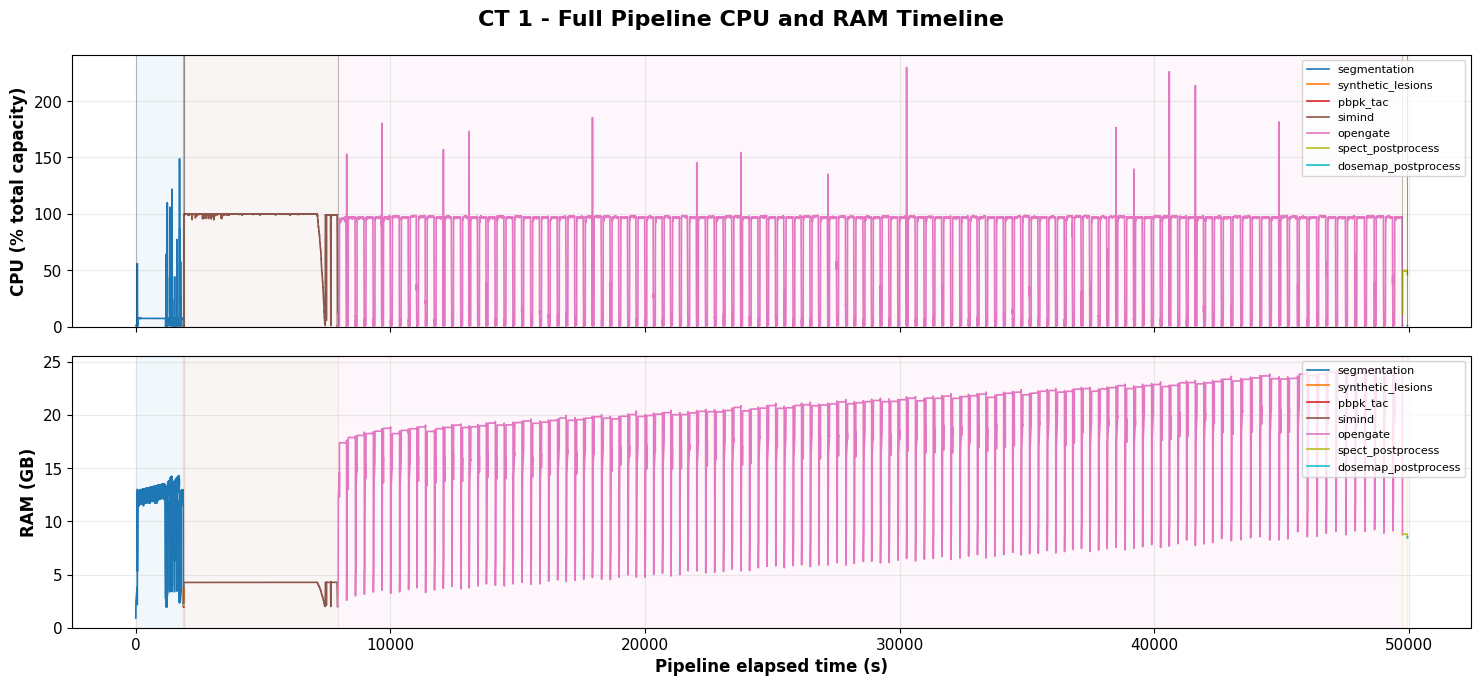


CT 1 - Full profile timeline table
  stage                    start_s     end_s  elapsed_s samples  mean_CPU%  max_CPU%  mean_RAM_GB  peak_RAM_GB
  segmentation                 0.0    1874.4     1874.4    1829        7.4     148.8        11.52        14.28
  synthetic_lesions         1874.4    1881.0        6.6       7        0.9       0.9         2.64         3.74
  pbpk_tac                  1881.0    1883.5        2.4       3        0.9       0.9         1.96         1.96
  simind                    1883.5    7928.7     6045.3    5099       96.7     100.1         4.19         4.27
  opengate                  7928.7   49740.7    41812.0   40629       75.8     229.9        19.98        24.38
  spect_postprocess        49740.7   49932.6      191.9     187       49.3      49.6         8.79         8.79
  dosemap_postprocess      49932.6   49934.0        1.5       2        0.9       0.9         8.50         8.54


In [57]:
for i, prof in profiles.items():
    stages = prof.get('stages', [])
    cpu_count = prof.get('logical_cpu_count', 1)
    if not stages:
        continue

    colors = plt.get_cmap(plot_spec('profile', 'cmap', 'tab10'))(np.linspace(0, 1, len(stages)))
    fig, (ax_cpu, ax_ram) = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
    fig.suptitle(f'CT {i+1} - Full Pipeline CPU and RAM Timeline')

    offset = 0.0
    timeline_rows = []
    for s, col in zip(stages, colors):
        elapsed = float(s.get('elapsed_s', 0.0))
        t = np.asarray(s.get('sample_times_s', []), dtype=float) + offset
        cpu = np.asarray(s.get('cpu_pct_samples', []), dtype=float) / cpu_count
        ram = np.asarray(s.get('ram_mb_samples', []), dtype=float) / 1024.0
        name = s.get('name', 'unknown')
        if t.size:
            ax_cpu.plot(t, cpu, lw=1.2, color=col, label=name)
            ax_ram.plot(t, ram, lw=1.2, color=col, label=name)
        timeline_rows.append({
            'stage': name,
            'start_s': float(offset),
            'end_s': float(offset + elapsed),
            'elapsed_s': elapsed,
            'samples': int(np.sum(np.isfinite(cpu))),
            'mean_cpu_pct': float(np.nanmean(cpu)) if cpu.size else np.nan,
            'max_cpu_pct': float(np.nanmax(cpu)) if cpu.size else np.nan,
            'mean_ram_gb': float(np.nanmean(ram)) if ram.size else np.nan,
            'peak_ram_gb': float(np.nanmax(ram)) if ram.size else np.nan,
        })
        ax_cpu.axvspan(offset, offset + elapsed, color=col, alpha=0.06)
        ax_ram.axvspan(offset, offset + elapsed, color=col, alpha=0.06)
        ax_cpu.axvline(offset, color='k', lw=0.5, alpha=0.3)
        offset += elapsed
    ax_cpu.axvline(offset, color='k', lw=0.5, alpha=0.3)

    ax_cpu.set_ylabel('CPU (% total capacity)')
    ax_ram.set_ylabel('RAM (GB)')
    ax_ram.set_xlabel('Pipeline elapsed time (s)')
    for ax in (ax_cpu, ax_ram):
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, loc='upper right')
        ax.set_ylim(bottom=0)
    finish_plot(fig, f'ct_{i+1}_profile_full_timeline')

    print(f"\nCT {i+1} - Full profile timeline table")
    print(f"  {'stage':22s} {'start_s':>9s} {'end_s':>9s} {'elapsed_s':>10s} {'samples':>7s} "
          f"{'mean_CPU%':>10s} {'max_CPU%':>9s} {'mean_RAM_GB':>12s} {'peak_RAM_GB':>12s}")
    for row in timeline_rows:
        print(f"  {row['stage']:22s} {row['start_s']:9.1f} {row['end_s']:9.1f} {row['elapsed_s']:10.1f} {row['samples']:7d} "
              f"{fmt_num(row['mean_cpu_pct'], width=10, precision=1)} {fmt_num(row['max_cpu_pct'], width=9, precision=1)} "
              f"{fmt_num(row['mean_ram_gb'], width=12, precision=2)} {fmt_num(row['peak_ram_gb'], width=12, precision=2)}")


### 12b - Cross-Patient Stage CPU/RAM Comparison

Expected output: one normalized-time mean +/- std CPU/RAM plot per stage, filtered by `PROFILE_PHASE` if set. Individual patient traces are shown faintly and the across-patient mean/std band is emphasized.


In [58]:
def ordered_stage_names(names):
    order = {name: idx for idx, name in enumerate(STAGE_ORDER)}
    return sorted(names, key=lambda n: (order.get(n, 10**6), n))


def profile_stage_by_name(prof, stage_name):
    matches = [s for s in prof.get('stages', []) if s.get('name') == stage_name]
    return matches[0] if matches else None


def normalized_stage_series(stage, cpu_count, metric, grid):
    elapsed = float(stage.get('elapsed_s', 0.0))
    t = np.asarray(stage.get('sample_times_s', []), dtype=float)
    if metric == 'cpu':
        y = np.asarray(stage.get('cpu_pct_samples', []), dtype=float) / max(float(cpu_count), 1.0)
    elif metric == 'ram':
        y = np.asarray(stage.get('ram_mb_samples', []), dtype=float) / 1024.0
    else:
        raise ValueError(metric)

    mask = np.isfinite(t) & np.isfinite(y)
    t, y = t[mask], y[mask]
    if y.size == 0:
        return np.full_like(grid, np.nan, dtype=float)
    if t.size == 0 or elapsed <= 0:
        return np.full_like(grid, float(np.nanmean(y)), dtype=float)

    rel = np.clip(t / elapsed, 0.0, 1.0)
    order = np.argsort(rel)
    rel, y = rel[order], y[order]
    rel_unique, unique_idx = np.unique(rel, return_index=True)
    y_unique = y[unique_idx]
    if rel_unique.size == 1:
        return np.full_like(grid, float(y_unique[0]), dtype=float)
    return np.interp(grid, rel_unique, y_unique, left=y_unique[0], right=y_unique[-1])


if len(profiles) > 1:
    def get_stages(prof, phase_filter):
        stages = prof.get('stages', [])
        return [x for x in stages if phase_filter.lower() in x.get('name', '').lower()] if phase_filter else stages

    all_stage_names = ordered_stage_names({s['name'] for prof in profiles.values() for s in get_stages(prof, PROFILE_PHASE)})
    if not all_stage_names:
        print(f"No stages match PROFILE_PHASE='{PROFILE_PHASE}'")
    else:
        patient_idxs = sorted(profiles.keys())
        grid = np.linspace(0.0, 1.0, 101)
        x_pct = grid * 100.0
        patient_colors = plt.get_cmap(plot_spec('profile', 'cmap', 'tab10'))(np.linspace(0, 1, len(patient_idxs)))

        for stage_name in all_stage_names:
            cpu_rows, ram_rows, included = [], [], []
            fig, (ax_cpu, ax_ram) = plt.subplots(1, 2, figsize=(14, 5.2), sharex=True)
            fig.suptitle(f'Cross-Patient Stage Profile: {stage_name.replace("_", " ")}')

            for idx, col in zip(patient_idxs, patient_colors):
                prof = profiles[idx]
                stage = profile_stage_by_name(prof, stage_name)
                if stage is None:
                    continue
                cpu_count = prof.get('logical_cpu_count', 1)
                cpu_y = normalized_stage_series(stage, cpu_count, 'cpu', grid)
                ram_y = normalized_stage_series(stage, cpu_count, 'ram', grid)
                if np.all(~np.isfinite(cpu_y)) and np.all(~np.isfinite(ram_y)):
                    continue
                cpu_rows.append(cpu_y)
                ram_rows.append(ram_y)
                included.append(idx)
                ax_cpu.plot(x_pct, cpu_y, lw=0.9, color=col, alpha=0.25)
                ax_ram.plot(x_pct, ram_y, lw=0.9, color=col, alpha=0.25)

            if not included:
                plt.close(fig)
                print(f'{stage_name}: no profiling samples available')
                continue

            cpu_mean, cpu_std, _ = nanmean_std_count(np.vstack(cpu_rows), axis=0)
            ram_mean, ram_std, _ = nanmean_std_count(np.vstack(ram_rows), axis=0)

            ax_cpu.plot(x_pct, cpu_mean, lw=2.4, color='steelblue', label='Mean')
            ax_cpu.fill_between(x_pct, cpu_mean - cpu_std, cpu_mean + cpu_std, color='steelblue', alpha=0.18, label='+/- std')
            ax_ram.plot(x_pct, ram_mean, lw=2.4, color='seagreen', label='Mean')
            ax_ram.fill_between(x_pct, ram_mean - ram_std, ram_mean + ram_std, color='seagreen', alpha=0.18, label='+/- std')

            ax_cpu.set_title(f'CPU utilization (n={len(included)})')
            ax_cpu.set_ylabel('CPU (% total capacity)')
            ax_ram.set_title(f'RAM usage (n={len(included)})')
            ax_ram.set_ylabel('RAM (GB)')
            for ax in (ax_cpu, ax_ram):
                ax.set_xlabel('Stage progress (%)')
                ax.grid(True, alpha=0.25)
                ax.set_ylim(bottom=0)
                ax.legend(fontsize=9)
            finish_plot(fig, f'profile_cross_patient_{stage_name}_mean_std')

            print(f"\nCross-patient normalized profile table - {stage_name}")
            print(f"  {'progress_%':>10s} {'cpu_mean%':>10s} {'cpu_std':>10s} {'ram_mean_GB':>12s} {'ram_std':>10s} {'n':>4s}")
            for progress in [0, 25, 50, 75, 100]:
                grid_idx = int(np.argmin(np.abs(x_pct - progress)))
                n_here = int(min(np.sum(np.isfinite(np.vstack(cpu_rows)[:, grid_idx])), np.sum(np.isfinite(np.vstack(ram_rows)[:, grid_idx]))))
                print(f"  {progress:10.0f} {fmt_num(cpu_mean[grid_idx], width=10, precision=1)} "
                      f"{fmt_num(cpu_std[grid_idx], width=10, precision=1)} {fmt_num(ram_mean[grid_idx], width=12, precision=2)} "
                      f"{fmt_num(ram_std[grid_idx], width=10, precision=2)} {n_here:4d}")
else:
    print('Only 1 patient - cross-patient profiling comparison skipped')


Only 1 patient - cross-patient profiling comparison skipped


### 12c - Stage Runtime, CPU, and RAM Summary

Expected output: cross-patient mean +/- std bars for elapsed time, mean CPU capacity, mean RAM, and peak RAM for each pipeline stage, plus printed raw and aggregate tables so the plotted values are easy to reference.


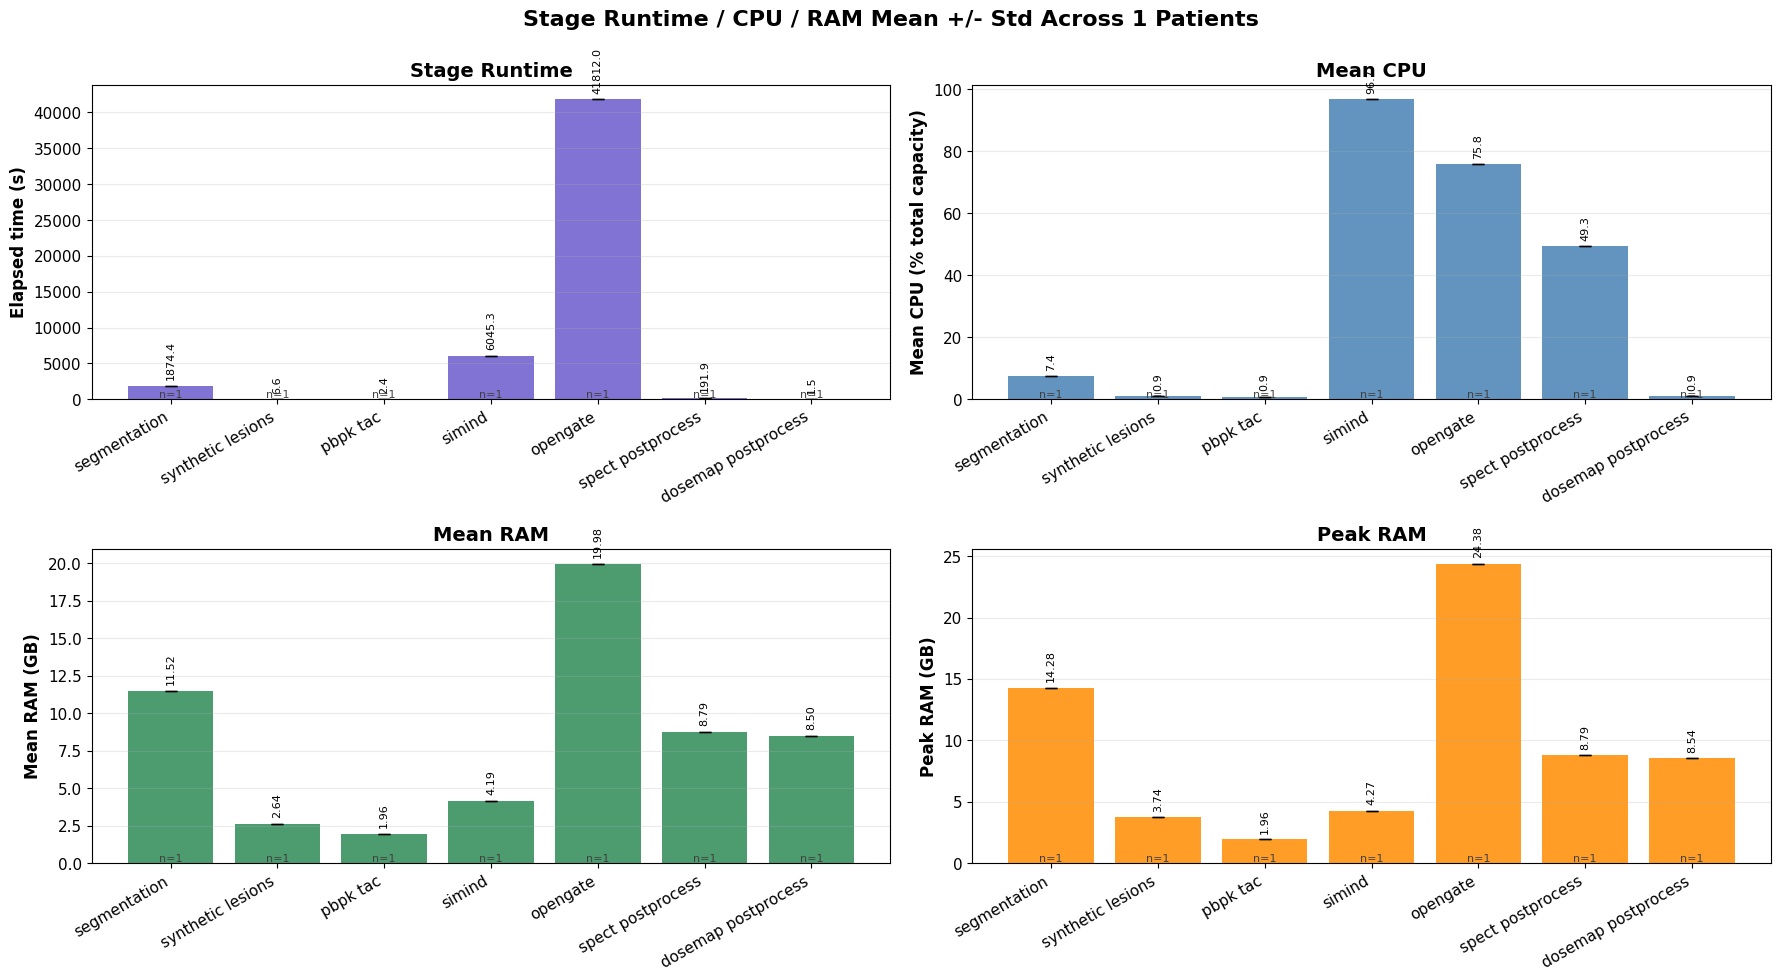


Stage profile raw values by patient
    CT stage                   elapsed_s  mean_CPU%  max_CPU%  mean_RAM_GB  peak_RAM_GB
     1 segmentation               1874.4        7.4     148.8        11.52        14.28
     1 synthetic_lesions             6.6        0.9       0.9         2.64         3.74
     1 pbpk_tac                      2.4        0.9       0.9         1.96         1.96
     1 simind                     6045.3       96.7     100.1         4.19         4.27
     1 opengate                  41812.0       75.8     229.9        19.98        24.38
     1 spect_postprocess           191.9       49.3      49.6         8.79         8.79
     1 dosemap_postprocess           1.5        0.9       0.9         8.50         8.54

Stage profile mean +/- std across patients
  stage                    n            elapsed_s            mean_CPU%          mean_RAM_GB          peak_RAM_GB
  segmentation             1    1874.4+/-0.0            7.4+/-0.0          11.52+/-0.00         14.28+

In [59]:
if profile_summary_store:
    all_names = ordered_stage_names({row['name'] for rows in profile_summary_store.values() for row in rows})
    patient_idxs = sorted(profile_summary_store.keys())
    x = np.arange(len(all_names))

    metric_defs = [
        ('elapsed_s', 'Elapsed time (s)', 'Stage Runtime'),
        ('mean_cpu_capacity_pct', 'Mean CPU (% total capacity)', 'Mean CPU'),
        ('mean_ram_gb', 'Mean RAM (GB)', 'Mean RAM'),
        ('peak_ram_gb', 'Peak RAM (GB)', 'Peak RAM'),
    ]

    def add_value_labels(ax, xs, vals, *, precision=1, rotation=90):
        vals = np.asarray(vals, dtype=float)
        finite_vals = vals[np.isfinite(vals)]
        if finite_vals.size == 0:
            return
        y_max = float(np.nanmax(finite_vals))
        y_pad = 0.02 * y_max if y_max > 0 else 0.1
        for xi, yi in zip(xs, vals):
            if not np.isfinite(yi):
                continue
            ax.text(
                xi,
                yi + y_pad,
                f'{yi:.{precision}f}',
                ha='center',
                va='bottom',
                fontsize=8,
                rotation=rotation,
            )

    profile_stage_mean_std = {metric: {'mean': [], 'std': [], 'n': []} for metric, _, _ in metric_defs}
    raw_stage_rows = []
    for stage_name in all_names:
        rows_for_stage = []
        for patient_idx in patient_idxs:
            lookup = {row['name']: row for row in profile_summary_store[patient_idx]}
            if stage_name in lookup:
                row = dict(lookup[stage_name])
                row['patient_idx'] = patient_idx
                rows_for_stage.append(row)
                raw_stage_rows.append(row)
        for metric, _, _ in metric_defs:
            vals = np.asarray([row.get(metric, np.nan) for row in rows_for_stage], dtype=float)
            mean, std, count = nanmean_std_count(vals[:, None], axis=0)
            profile_stage_mean_std[metric]['mean'].append(mean[0])
            profile_stage_mean_std[metric]['std'].append(std[0])
            profile_stage_mean_std[metric]['n'].append(int(count[0]))

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    fig.suptitle(f'Stage Runtime / CPU / RAM Mean +/- Std Across {len(patient_idxs)} Patients')
    axes = axes.ravel()
    bar_colors = ['slateblue', 'steelblue', 'seagreen', 'darkorange']

    for ax, (metric, ylabel, title), color in zip(axes, metric_defs, bar_colors):
        means = np.asarray(profile_stage_mean_std[metric]['mean'], dtype=float)
        stds = np.asarray(profile_stage_mean_std[metric]['std'], dtype=float)
        ax.bar(x, means, yerr=stds, capsize=4, color=color, alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels([n.replace('_', ' ') for n in all_names], rotation=30, ha='right')
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(True, axis='y', alpha=0.25)
        add_value_labels(ax, x, means, precision=1 if metric != 'mean_ram_gb' and metric != 'peak_ram_gb' else 2)
        for xi, yi, n in zip(x, means, profile_stage_mean_std[metric]['n']):
            if np.isfinite(yi):
                ax.text(xi, 0, f'n={n}', ha='center', va='bottom', fontsize=8, color='0.25')
    finish_plot(fig, 'profile_stage_runtime_cpu_ram_mean_std')

    print('\nStage profile raw values by patient')
    print(f"  {'CT':>4s} {'stage':22s} {'elapsed_s':>10s} {'mean_CPU%':>10s} {'max_CPU%':>9s} {'mean_RAM_GB':>12s} {'peak_RAM_GB':>12s}")
    for patient_idx in patient_idxs:
        lookup = {row['name']: row for row in profile_summary_store[patient_idx]}
        for stage_name in all_names:
            if stage_name not in lookup:
                continue
            row = lookup[stage_name]
            print(f"  {patient_idx+1:4d} {stage_name:22s} {row['elapsed_s']:10.1f} "
                  f"{fmt_num(row['mean_cpu_capacity_pct'], width=10, precision=1)} "
                  f"{fmt_num(row['max_cpu_capacity_pct'], width=9, precision=1)} "
                  f"{fmt_num(row['mean_ram_gb'], width=12, precision=2)} "
                  f"{fmt_num(row['peak_ram_gb'], width=12, precision=2)}")

    print('\nStage profile mean +/- std across patients')
    print(f"  {'stage':22s} {'n':>3s} {'elapsed_s':>20s} {'mean_CPU%':>20s} {'mean_RAM_GB':>20s} {'peak_RAM_GB':>20s}")
    for idx, stage_name in enumerate(all_names):
        n_here = max(profile_stage_mean_std[m]['n'][idx] for m, _, _ in metric_defs)
        elapsed = profile_stage_mean_std['elapsed_s']
        cpu = profile_stage_mean_std['mean_cpu_capacity_pct']
        mean_ram = profile_stage_mean_std['mean_ram_gb']
        peak_ram = profile_stage_mean_std['peak_ram_gb']
        print(f"  {stage_name:22s} {n_here:3d} "
              f"{elapsed['mean'][idx]:9.1f}+/-{elapsed['std'][idx]:<8.1f} "
              f"{cpu['mean'][idx]:9.1f}+/-{cpu['std'][idx]:<8.1f} "
              f"{mean_ram['mean'][idx]:9.2f}+/-{mean_ram['std'][idx]:<8.2f} "
              f"{peak_ram['mean'][idx]:9.2f}+/-{peak_ram['std'][idx]:<8.2f}")
else:
    print('No profiling summaries available')


### 12d - Resolution Scaling: Time, CPU, and RAM

Expected output: SIMIND and OpenGATE runtime and peak RAM versus simulation-grid spacing, plus runtime and peak-RAM reduction versus CT1. The x-axis uses cube-equivalent voxel edge, `(dx * dy * dz) ** (1/3)` in mm, so anisotropic CT1 spacing is represented by a single volume-equivalent value. CPU is printed as a diagnostic but not plotted as a “reduction,” because lower CPU utilization can mean worse parallel utilization rather than better performance.


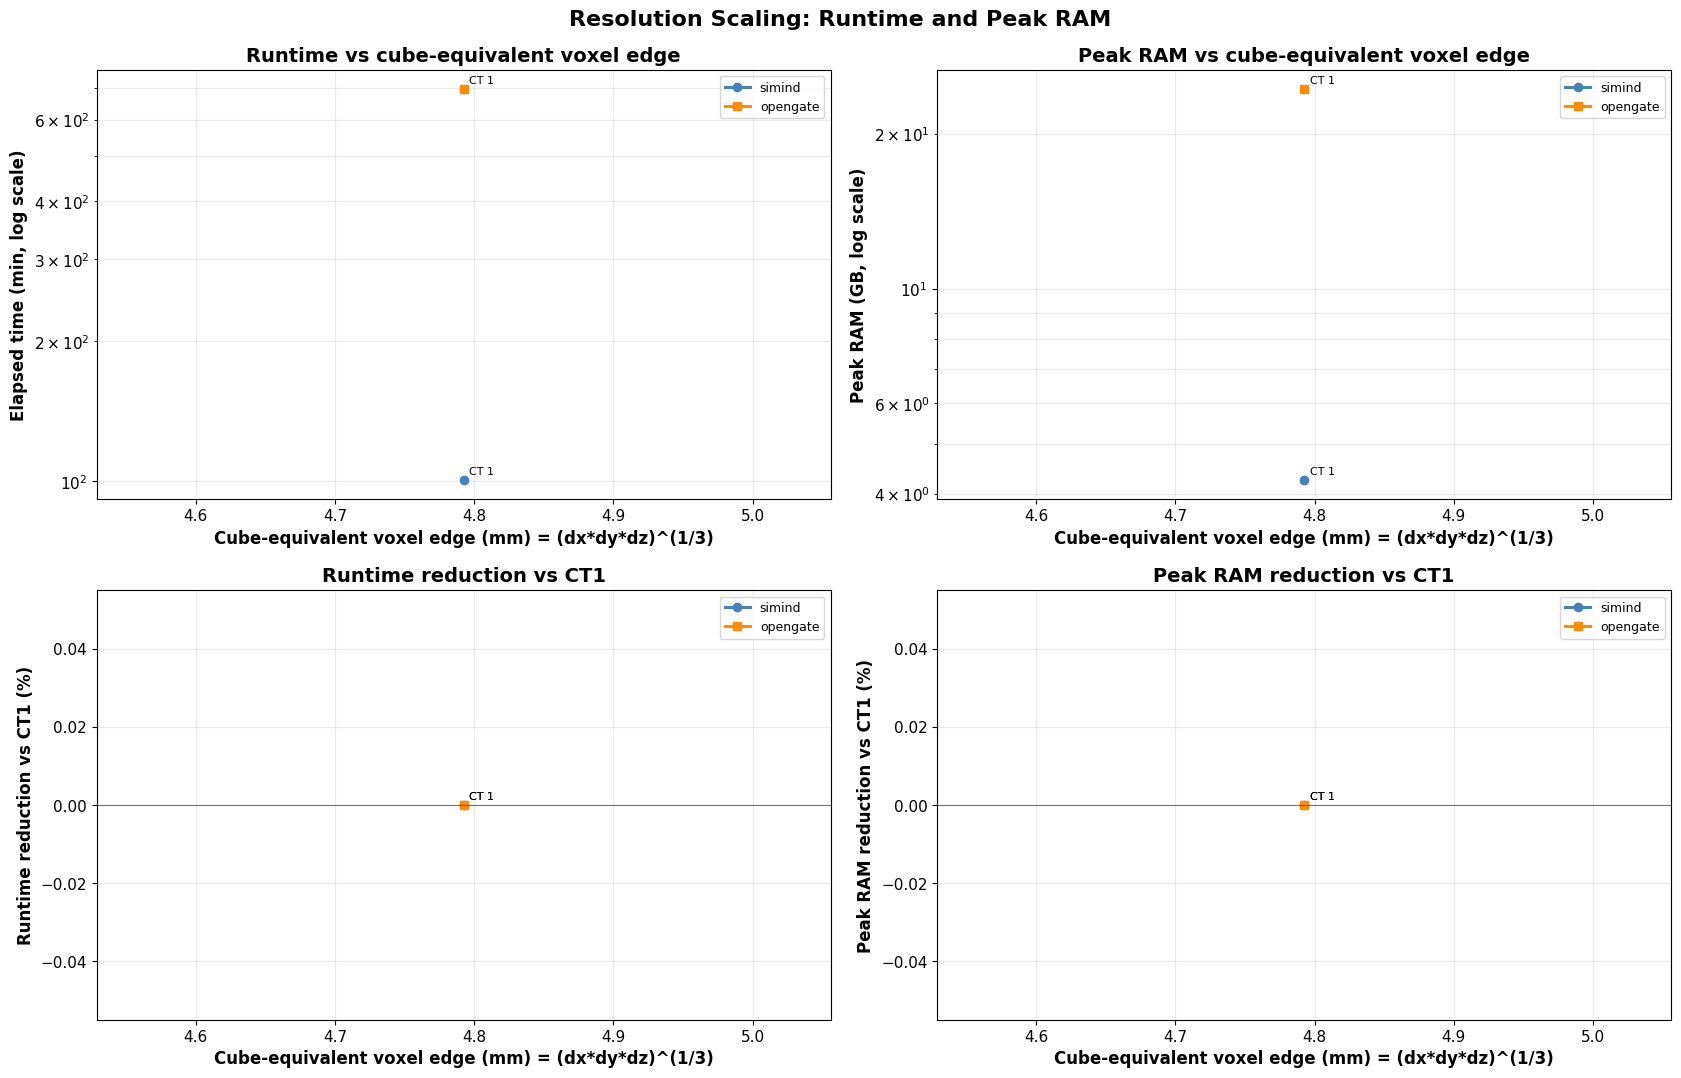


Resolution scaling raw metrics
  spacing_xyz_mm is actual x/y/z voxel spacing in mm.
  cube_edge_mm = (dx*dy*dz)^(1/3), the edge of a cube with the same voxel volume.
  *_pct_CT1 columns are percentages: current value / CT1 value * 100.
  *_reduction_pct columns are percentages: (1 - current value / CT1 value) * 100.
  CPU columns are diagnostic utilization, not a reduction target; lower CPU is not automatically better.
    CT stage              spacing_xyz_mm cube_edge_mm   grid_M    roi_M  elapsed_min  time_pct_CT1  time_reduction%  peak_RAM_GB  RAM_pct_CT1  RAM_reduction%  mean_CPU%  peak_CPU%
  CT 1 opengate       4.79 x 4.79 x 4.79         4.79     5.90     0.49       696.87         100.0              0.0        24.38        100.0             0.0       75.8      229.9
  CT 1 simind         4.79 x 4.79 x 4.79         4.79     0.48     0.48       100.75         100.0              0.0         4.27        100.0             0.0       96.7      100.1

Resolution scaling by patient tota

In [60]:
resolution_scaling_rows = []


def load_stage_metadata(folder, stage_name):
    path = os.path.join(folder, 'pipeline_metadata', f'{stage_name}.json')
    return load_json(path) if os.path.exists(path) else {}


def finite_array(values):
    arr = np.asarray(values, dtype=float)
    return arr[np.isfinite(arr)]


def geom_mean(values):
    arr = finite_array(values)
    arr = arr[arr > 0]
    if arr.size == 0:
        return np.nan
    return float(np.prod(arr) ** (1.0 / arr.size))


def fmt_spacing(values):
    arr = finite_array(values)
    if arr.size == 0:
        return 'n/a'
    return ' x '.join(f'{v:.2f}' for v in arr)


def cube_equivalent_edge_mm(spacing_xyz_mm):
    # Edge length of a cube with the same voxel volume as the possibly anisotropic voxel.
    return geom_mean(spacing_xyz_mm)


def pct_of_baseline(value, baseline):
    return value / baseline * 100.0 if np.isfinite(value) and np.isfinite(baseline) and baseline > 0 else np.nan


def pct_reduction_from_baseline(value, baseline):
    pct_value = pct_of_baseline(value, baseline)
    return 100.0 - pct_value if np.isfinite(pct_value) else np.nan


def grid_voxels_from_size(size_values):
    vals = [int(v) for v in (size_values or []) if int(v) > 0]
    return int(np.prod(vals)) if vals else np.nan


def stage_metric_row(patient_idx, stage_name):
    lookup = {row['name']: row for row in profile_summary_store.get(patient_idx, [])}
    return lookup.get(stage_name, {})


def simind_resolution_info(patient_idx, folder):
    meta = simind_meta_store.get(patient_idx) or load_stage_metadata(folder, 'simind_simulation_stage')
    # SIMIND metadata stores spacing in z,y,x order; display/plot using x,y,z order.
    spacing_zyx_mm = np.asarray(meta.get('arr_px_spacing_cm', []), dtype=float) * 10.0
    spacing_xyz_mm = spacing_zyx_mm[::-1] if finite_array(spacing_zyx_mm).size == 3 else spacing_zyx_mm
    shape = meta.get('arr_shape_new', [])
    grid_voxels = meta.get('total_num_voxels') or grid_voxels_from_size(shape)
    return {
        'spacing_mm': spacing_xyz_mm,
        'spacing_text': fmt_spacing(spacing_xyz_mm),
        'cube_edge_mm': cube_equivalent_edge_mm(spacing_xyz_mm),
        'voxel_volume_mm3': float(np.prod(spacing_xyz_mm)) if finite_array(spacing_xyz_mm).size == 3 else np.nan,
        'grid_voxels': float(grid_voxels) if np.isfinite(grid_voxels) else np.nan,
        'roi_voxels': float(grid_voxels) if np.isfinite(grid_voxels) else np.nan,
    }


def opengate_resolution_info(folder):
    meta = load_stage_metadata(folder, 'opengate_simulation_stage')
    grid = meta.get('dose_output_grid', {})
    spacing_mm = np.asarray(grid.get('spacing_xyz_mm') or meta.get('downsampling', {}).get('xyz_spacing_mm') or [], dtype=float)
    size_xyz = grid.get('size_xyz', [])
    grid_voxels = grid_voxels_from_size(size_xyz)
    roi_counts = meta.get('roi_voxel_counts', {}) or {}
    roi_voxels = float(np.sum([v for v in roi_counts.values() if isinstance(v, (int, float))])) if roi_counts else np.nan
    return {
        'spacing_mm': spacing_mm,
        'spacing_text': fmt_spacing(spacing_mm),
        'cube_edge_mm': cube_equivalent_edge_mm(spacing_mm),
        'voxel_volume_mm3': float(np.prod(spacing_mm)) if finite_array(spacing_mm).size == 3 else np.nan,
        'grid_voxels': float(grid_voxels) if np.isfinite(grid_voxels) else np.nan,
        'roi_voxels': roi_voxels,
    }


for patient_idx, folder in enumerate(OUT_FOLDERS):
    if patient_idx not in profile_summary_store:
        continue
    for stage_name, info in [
        ('simind', simind_resolution_info(patient_idx, folder)),
        ('opengate', opengate_resolution_info(folder)),
    ]:
        metrics = stage_metric_row(patient_idx, stage_name)
        if not metrics:
            continue
        resolution_scaling_rows.append({
            'patient_idx': patient_idx,
            'ct_label': f'CT {patient_idx + 1}',
            'stage': stage_name,
            **info,
            'elapsed_s': float(metrics.get('elapsed_s', np.nan)),
            'elapsed_min': float(metrics.get('elapsed_s', np.nan)) / 60.0,
            'mean_cpu_pct': float(metrics.get('mean_cpu_capacity_pct', np.nan)),
            'peak_cpu_pct': float(metrics.get('max_cpu_capacity_pct', np.nan)),
            'mean_ram_gb': float(metrics.get('mean_ram_gb', np.nan)),
            'peak_ram_gb': float(metrics.get('peak_ram_gb', np.nan)),
        })

if not resolution_scaling_rows:
    print('No SIMIND/OpenGATE profiling + resolution metadata available')
else:
    stages_to_plot = [s for s in ['simind', 'opengate'] if any(r['stage'] == s for r in resolution_scaling_rows)]
    colors = {'simind': 'steelblue', 'opengate': 'darkorange'}
    markers = {'simind': 'o', 'opengate': 's'}

    for stage_name in stages_to_plot:
        rows = sorted([r for r in resolution_scaling_rows if r['stage'] == stage_name], key=lambda r: r['patient_idx'])
        base_time = rows[0].get('elapsed_s', np.nan) if rows else np.nan
        base_ram = rows[0].get('peak_ram_gb', np.nan) if rows else np.nan
        for row in rows:
            row['time_pct_of_ct1'] = pct_of_baseline(row['elapsed_s'], base_time)
            row['time_reduction_pct'] = pct_reduction_from_baseline(row['elapsed_s'], base_time)
            row['ram_pct_of_ct1'] = pct_of_baseline(row['peak_ram_gb'], base_ram)
            row['ram_reduction_pct'] = pct_reduction_from_baseline(row['peak_ram_gb'], base_ram)

    fig, axes = plt.subplots(2, 2, figsize=(17, 11))
    fig.suptitle('Resolution Scaling: Runtime and Peak RAM')
    ax_time, ax_ram, ax_time_red, ax_ram_red = axes.ravel()

    for stage_name in stages_to_plot:
        rows = sorted([r for r in resolution_scaling_rows if r['stage'] == stage_name], key=lambda r: r['cube_edge_mm'])
        x = np.asarray([r['cube_edge_mm'] for r in rows], dtype=float)
        labels = [r['ct_label'] for r in rows]
        elapsed_min = np.asarray([r['elapsed_min'] for r in rows], dtype=float)
        peak_ram = np.asarray([r['peak_ram_gb'] for r in rows], dtype=float)
        time_reduction = np.asarray([r.get('time_reduction_pct', np.nan) for r in rows], dtype=float)
        ram_reduction = np.asarray([r.get('ram_reduction_pct', np.nan) for r in rows], dtype=float)

        ax_time.plot(x, elapsed_min, marker=markers[stage_name], lw=2.2, color=colors[stage_name], label=stage_name)
        ax_ram.plot(x, peak_ram, marker=markers[stage_name], lw=2.2, color=colors[stage_name], label=stage_name)
        ax_time_red.plot(x, time_reduction, marker=markers[stage_name], lw=2.2, color=colors[stage_name], label=stage_name)
        ax_ram_red.plot(x, ram_reduction, marker=markers[stage_name], lw=2.2, color=colors[stage_name], label=stage_name)

        for ax, yy_values in [
            (ax_time, elapsed_min),
            (ax_ram, peak_ram),
            (ax_time_red, time_reduction),
            (ax_ram_red, ram_reduction),
        ]:
            for xx, yy, lab in zip(x, yy_values, labels):
                if np.isfinite(xx) and np.isfinite(yy):
                    ax.annotate(lab, (xx, yy), textcoords='offset points', xytext=(4, 4), fontsize=8)

    ax_time.set_yscale('log')
    ax_ram.set_yscale('log')
    ax_time.set_ylabel('Elapsed time (min, log scale)')
    ax_ram.set_ylabel('Peak RAM (GB, log scale)')
    ax_time_red.set_ylabel('Runtime reduction vs CT1 (%)')
    ax_ram_red.set_ylabel('Peak RAM reduction vs CT1 (%)')
    ax_time.set_title('Runtime vs cube-equivalent voxel edge')
    ax_ram.set_title('Peak RAM vs cube-equivalent voxel edge')
    ax_time_red.set_title('Runtime reduction vs CT1')
    ax_ram_red.set_title('Peak RAM reduction vs CT1')
    ax_time_red.axhline(0.0, color='0.25', lw=0.8, alpha=0.7)
    ax_ram_red.axhline(0.0, color='0.25', lw=0.8, alpha=0.7)
    for ax in axes.ravel():
        ax.set_xlabel('Cube-equivalent voxel edge (mm) = (dx*dy*dz)^(1/3)')
        ax.grid(True, alpha=0.25, which='both')
        ax.legend(fontsize=9)
    finish_plot(fig, 'profile_resolution_scaling_runtime_peak_ram_reduction')

    print('\nResolution scaling raw metrics')
    print('  spacing_xyz_mm is actual x/y/z voxel spacing in mm.')
    print('  cube_edge_mm = (dx*dy*dz)^(1/3), the edge of a cube with the same voxel volume.')
    print('  *_pct_CT1 columns are percentages: current value / CT1 value * 100.')
    print('  *_reduction_pct columns are percentages: (1 - current value / CT1 value) * 100.')
    print('  CPU columns are diagnostic utilization, not a reduction target; lower CPU is not automatically better.')
    print(f"  {'CT':>4s} {'stage':10s} {'spacing_xyz_mm':>22s} {'cube_edge_mm':>12s} {'grid_M':>8s} {'roi_M':>8s} "
          f"{'elapsed_min':>12s} {'time_pct_CT1':>13s} {'time_reduction%':>16s} {'peak_RAM_GB':>12s} {'RAM_pct_CT1':>12s} {'RAM_reduction%':>15s} {'mean_CPU%':>10s} {'peak_CPU%':>10s}")
    for row in sorted(resolution_scaling_rows, key=lambda r: (r['patient_idx'], r['stage'])):
        print(f"  {row['ct_label']:>4s} {row['stage']:10s} {row['spacing_text']:>22s} "
              f"{fmt_num(row['cube_edge_mm'], width=12, precision=2)} "
              f"{fmt_num(row['grid_voxels'] / 1e6, width=8, precision=2)} "
              f"{fmt_num(row['roi_voxels'] / 1e6, width=8, precision=2)} "
              f"{fmt_num(row['elapsed_min'], width=12, precision=2)} "
              f"{fmt_num(row.get('time_pct_of_ct1', np.nan), width=13, precision=1)} "
              f"{fmt_num(row.get('time_reduction_pct', np.nan), width=16, precision=1)} "
              f"{fmt_num(row['peak_ram_gb'], width=12, precision=2)} "
              f"{fmt_num(row.get('ram_pct_of_ct1', np.nan), width=12, precision=1)} "
              f"{fmt_num(row.get('ram_reduction_pct', np.nan), width=15, precision=1)} "
              f"{fmt_num(row.get('mean_cpu_pct', np.nan), width=10, precision=1)} "
              f"{fmt_num(row.get('peak_cpu_pct', np.nan), width=10, precision=1)}")

    print('\nResolution scaling by patient totals')
    print(f"  {'CT':>4s} {'sim_cube_mm':>11s} {'og_cube_mm':>10s} {'pipeline_min':>12s} {'pipeline_pct_CT1':>16s} {'pipeline_reduction%':>19s} {'simind_min':>11s} {'opengate_min':>12s}")
    patient_total_base = profiles[min(profiles)].get('pipeline_total_elapsed_s', np.nan) if profiles else np.nan
    for patient_idx in sorted(profiles):
        sim_rows = [r for r in resolution_scaling_rows if r['patient_idx'] == patient_idx and r['stage'] == 'simind']
        og_rows = [r for r in resolution_scaling_rows if r['patient_idx'] == patient_idx and r['stage'] == 'opengate']
        sim_row = sim_rows[0] if sim_rows else {}
        og_row = og_rows[0] if og_rows else {}
        total_s = float(profiles[patient_idx].get('pipeline_total_elapsed_s', np.nan))
        pipe_pct_ct1 = pct_of_baseline(total_s, patient_total_base)
        pipe_reduction_pct = pct_reduction_from_baseline(total_s, patient_total_base)
        print(f"  CT {patient_idx+1:<1d} {fmt_num(sim_row.get('cube_edge_mm', np.nan), width=11, precision=2)} "
              f"{fmt_num(og_row.get('cube_edge_mm', np.nan), width=10, precision=2)} "
              f"{fmt_num(total_s / 60.0, width=12, precision=2)} "
              f"{fmt_num(pipe_pct_ct1, width=16, precision=1)} "
              f"{fmt_num(pipe_reduction_pct, width=19, precision=1)} "
              f"{fmt_num(sim_row.get('elapsed_min', np.nan), width=11, precision=2)} "
              f"{fmt_num(og_row.get('elapsed_min', np.nan), width=12, precision=2)}")
